In [1]:
# ============================================================
# PHASE 2 — SUPERVISED ML
# STEP 1: LOAD PHASE 1 DATASET
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# Project path
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML"
)

DATA_FILE = (
    PROJECT_ROOT /
    "data/ml_ready/phase1_event_level_ml_dataset.csv"
)

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

df = pd.read_csv(DATA_FILE)

print("========== PHASE 2 DATASET ==========")

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nDate range:")

print(
    df["start_time"].min(),
    "→",
    df["start_time"].max()
)

print("\nShape:")

print(df.shape)

print("\nColumns:")

print(df.columns.tolist())

print("\nFirst 5 rows:")

display(df.head())

========== PHASE 2 DATASET ==========
Rows: 439251
Columns: 26

Date range:
2025-01-01 03:50:00 → 2025-03-19 21:30:00

Shape:
(439251, 26)

Columns:
['acq_date', 'lat_cell', 'lon_cell', 'event_number', 'start_time', 'end_time', 'observation_count', 'latitude', 'longitude', 'mean_frp', 'peak_frp', 'total_frp', 'mean_brightness', 'persistent', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'historical_daily_activity', 'previously_detected', 'event_date', 'has_historical_context', 'event_id', 'anomaly_prediction', 'anomaly_score', 'is_anomaly', 'anomaly_method']

First 5 rows:


,acq_date,lat_cell,lon_cell,event_number,start_time,end_time,observation_count,latitude,longitude,mean_frp,...,local_frp_deviation,historical_daily_activity,previously_detected,event_date,has_historical_context,event_id,anomaly_prediction,anomaly_score,is_anomaly,anomaly_method
0,2025-01-01,2989,9403,1,2025-01-01 03:50:00,2025-01-01 03:50:00,1,26.9361,94.0335,6.5,...,0.0,0.0,0.0,2025-01-01,1,0,1,0.093408,False,Isolation Forest prototype
1,2025-01-01,2810,9160,1,2025-01-01 03:51:00,2025-01-01 03:51:00,1,25.3231,91.6008,8.0,...,0.0,0.0,0.0,2025-01-01,1,1,1,0.106868,False,Isolation Forest prototype
2,2025-01-01,2811,9159,1,2025-01-01 03:51:00,2025-01-01 03:51:00,1,25.3249,91.5900,11.3,...,0.0,0.0,0.0,2025-01-01,1,2,1,0.096588,False,Isolation Forest prototype
3,2025-01-01,2916,9281,1,2025-01-01 03:51:00,2025-01-01 03:51:00,1,26.2760,92.8154,11.6,...,0.0,0.0,0.0,2025-01-01,1,3,1,0.005439,False,Isolation Forest prototype
4,2025-01-01,2970,9276,1,2025-01-01 03:51:00,2025-01-01 03:51:00,1,26.7587,92.7613,5.3,...,0.0,0.0,0.0,2025-01-01,1,4,1,0.108285,False,Isolation Forest prototype


In [2]:
# ============================================================
# FEATURE INVENTORY
# ============================================================

print("========== FEATURE INVENTORY ==========")

for i, col in enumerate(df.columns):
    print(f"{i:02d}  {col}")

========== FEATURE INVENTORY ==========
00  acq_date
01  lat_cell
02  lon_cell
03  event_number
04  start_time
05  end_time
06  observation_count
07  latitude
08  longitude
09  mean_frp
10  peak_frp
11  total_frp
12  mean_brightness
13  persistent
14  historical_detection_count
15  historical_mean_frp
16  local_frp_deviation
17  historical_daily_activity
18  previously_detected
19  event_date
20  has_historical_context
21  event_id
22  anomaly_prediction
23  anomaly_score
24  is_anomaly
25  anomaly_method


In [3]:
# ============================================================
# DATA TYPES
# ============================================================

print(df.dtypes)

acq_date                          str
lat_cell                        int64
lon_cell                        int64
event_number                    int64
start_time                        str
end_time                          str
observation_count               int64
latitude                      float64
longitude                     float64
mean_frp                      float64
peak_frp                      float64
total_frp                     float64
mean_brightness               float64
persistent                       bool
historical_detection_count    float64
historical_mean_frp           float64
local_frp_deviation           float64
historical_daily_activity     float64
previously_detected           float64
event_date                        str
has_historical_context          int64
event_id                        int64
anomaly_prediction              int64
anomaly_score                 float64
is_anomaly                       bool
anomaly_method                    str
dtype: objec

In [4]:
# ============================================================
# SEARCH FOR POSSIBLE LABEL / GROUND-TRUTH COLUMNS
# ============================================================

keywords = [
    "label",
    "class",
    "source",
    "ground",
    "truth",
    "industrial",
    "agriculture",
    "forest",
    "waste"
]

possible = [
    col for col in df.columns
    if any(
        key in col.lower()
        for key in keywords
    )
]

print("Possible label-related columns:")

print(possible)

Possible label-related columns:
[]


Check the dataset output

In [5]:
# ============================================================
# STEP 4 — CHECK LABEL AVAILABILITY
# ============================================================

print("========== LABEL AVAILABILITY CHECK ==========")

# Check unique values for possible label-related columns
for col in possible:
    print(f"\n--- {col} ---")
    print("Data type:", df[col].dtype)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(15))

========== LABEL AVAILABILITY CHECK ==========


In [6]:
# ============================================================
# STEP 5 — CHECK IMPORTANT CONTEXT FEATURES
# ============================================================

important_cols = [
    "observation_count",
    "duration_minutes",
    "mean_frp",
    "peak_frp",
    "total_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "historical_daily_activity",
    "previously_detected",
    "has_historical_context",
    "anomaly_score",
    "is_anomaly"
]

available_cols = [c for c in important_cols if c in df.columns]

print("========== IMPORTANT FEATURES ==========")
display(df[available_cols].describe().T)

========== IMPORTANT FEATURES ==========


,count,mean,std,min,25%,50%,75%,max
observation_count,439251.0,1.600379,1.281113,1.000000,1.000000,1.000000,2.000000,26.000000
mean_frp,439251.0,6.914934,17.005489,0.000000,2.030000,3.800000,6.653333,2056.400000
peak_frp,439251.0,8.372936,24.993534,0.000000,2.160000,4.000000,7.280000,2056.400000
total_frp,439251.0,13.641015,60.299692,0.000000,2.480000,4.700000,9.730000,4853.380000
historical_detection_count,439251.0,13.006359,62.331592,0.000000,0.000000,0.000000,1.000000,1568.000000
historical_mean_frp,439251.0,1.836145,9.513431,0.000000,0.000000,0.000000,1.062918,855.260000
local_frp_deviation,439251.0,0.828698,11.681289,-852.680000,0.000000,0.000000,0.129264,1210.350000
historical_daily_activity,439251.0,12.539598,61.766310,0.000000,0.000000,0.000000,0.000000,1551.000000
previously_detected,439251.0,0.282390,0.450162,0.000000,0.000000,0.000000,1.000000,1.000000
has_historical_context,439251.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# ============================================================
# STEP 6 — SEARCH FOR ACTUAL SOURCE LABELS
# ============================================================

for col in df.columns:
    unique_count = df[col].nunique()

    if unique_count <= 10:
        print(f"\n{col}")
        print(df[col].value_counts(dropna=False))


event_number
event_number
1    382881
2     48755
3      6144
4      1216
5       236
6        17
7         1
8         1
Name: count, dtype: int64

persistent
persistent
False    305200
True     134051
Name: count, dtype: int64

previously_detected
previously_detected
0.0    315211
1.0    124040
Name: count, dtype: int64

has_historical_context
has_historical_context
1    439251
Name: count, dtype: int64

anomaly_prediction
anomaly_prediction
 1    356761
-1     82490
Name: count, dtype: int64

is_anomaly
is_anomaly
False    356761
True      82490
Name: count, dtype: int64

anomaly_method
anomaly_method
Isolation Forest prototype    439251
Name: count, dtype: int64


Check what contextual columns we actually have

In [8]:
# ============================================================
# STEP 7 — CONTEXT / SOURCE INFORMATION CHECK
# ============================================================

print("========== ALL COLUMNS ==========\n")

for i, col in enumerate(df.columns):
    print(f"{i:02d} : {col}")

========== ALL COLUMNS ==========

00 : acq_date
01 : lat_cell
02 : lon_cell
03 : event_number
04 : start_time
05 : end_time
06 : observation_count
07 : latitude
08 : longitude
09 : mean_frp
10 : peak_frp
11 : total_frp
12 : mean_brightness
13 : persistent
14 : historical_detection_count
15 : historical_mean_frp
16 : local_frp_deviation
17 : historical_daily_activity
18 : previously_detected
19 : event_date
20 : has_historical_context
21 : event_id
22 : anomaly_prediction
23 : anomaly_score
24 : is_anomaly
25 : anomaly_method


In [9]:
# ============================================================
# STEP 8 — CHECK DATA TYPES + MISSING VALUES
# ============================================================

check = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique()
})

display(check)

,dtype,missing,unique
acq_date,str,0,78
lat_cell,int64,0,2883
lon_cell,int64,0,2740
event_number,int64,0,8
start_time,str,0,5776
end_time,str,0,5815
observation_count,int64,0,25
latitude,float64,0,388610
longitude,float64,0,395631
mean_frp,float64,0,28938


In [11]:
# ============================================================
# STEP 9 — CHECK ACTUAL EVENT DATA
# ============================================================

requested_cols = [
    "event_id",
    "latitude",
    "longitude",
    "start_time",
    "observation_count",
    "duration_minutes",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "historical_daily_activity",
    "previously_detected",
    "anomaly_score",
    "is_anomaly"
]

# Keep only columns that actually exist
available_cols = [col for col in requested_cols if col in df.columns]
missing_cols = [col for col in requested_cols if col not in df.columns]

print("========== AVAILABLE COLUMNS ==========")
print(available_cols)

print("\n========== MISSING COLUMNS ==========")
print(missing_cols)

print("\n========== SAMPLE DATA ==========")
display(df[available_cols].head(10))

========== AVAILABLE COLUMNS ==========
['event_id', 'latitude', 'longitude', 'start_time', 'observation_count', 'mean_frp', 'peak_frp', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'historical_daily_activity', 'previously_detected', 'anomaly_score', 'is_anomaly']

========== MISSING COLUMNS ==========
['duration_minutes']

========== SAMPLE DATA ==========


,event_id,latitude,longitude,start_time,observation_count,mean_frp,peak_frp,historical_detection_count,historical_mean_frp,local_frp_deviation,historical_daily_activity,previously_detected,anomaly_score,is_anomaly
0,0,26.9361,94.0335,2025-01-01 03:50:00,1,6.5,6.5,0.0,0.0,0.0,0.0,0.0,0.093408,False
1,1,25.3231,91.6008,2025-01-01 03:51:00,1,8.0,8.0,0.0,0.0,0.0,0.0,0.0,0.106868,False
2,2,25.3249,91.5900,2025-01-01 03:51:00,1,11.3,11.3,0.0,0.0,0.0,0.0,0.0,0.096588,False
3,3,26.2760,92.8154,2025-01-01 03:51:00,1,11.6,11.6,0.0,0.0,0.0,0.0,0.0,0.005439,False
4,4,26.7587,92.7613,2025-01-01 03:51:00,1,5.3,5.3,0.0,0.0,0.0,0.0,0.0,0.108285,False
5,5,20.9661,85.1728,2025-01-01 03:52:00,1,6.8,6.8,0.0,0.0,0.0,0.0,0.0,0.107599,False
6,6,21.0756,85.0339,2025-01-01 03:52:00,1,5.6,5.6,0.0,0.0,0.0,0.0,0.0,0.033789,False
7,7,21.0753,85.0405,2025-01-01 03:52:00,1,9.3,9.3,0.0,0.0,0.0,0.0,0.0,0.105873,False
8,8,22.0373,83.7321,2025-01-01 03:52:00,1,17.1,17.1,0.0,0.0,0.0,0.0,0.0,0.109619,False
9,9,22.3815,87.2787,2025-01-01 03:52:00,1,4.5,4.5,0.0,0.0,0.0,0.0,0.0,0.031703,False


In [12]:
# ============================================================
# STEP 9 — CHECK ACTUAL EVENT DATA
# ============================================================

requested_cols = [
    "event_id",
    "latitude",
    "longitude",
    "start_time",
    "observation_count",
    "duration_minutes",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "historical_daily_activity",
    "previously_detected",
    "anomaly_score",
    "is_anomaly"
]

# Keep only columns that actually exist
available_cols = [col for col in requested_cols if col in df.columns]
missing_cols = [col for col in requested_cols if col not in df.columns]

print("========== AVAILABLE COLUMNS ==========")
print(available_cols)

print("\n========== MISSING COLUMNS ==========")
print(missing_cols)

print("\n========== SAMPLE DATA ==========")
display(df[available_cols].head(10))

========== AVAILABLE COLUMNS ==========
['event_id', 'latitude', 'longitude', 'start_time', 'observation_count', 'mean_frp', 'peak_frp', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'historical_daily_activity', 'previously_detected', 'anomaly_score', 'is_anomaly']

========== MISSING COLUMNS ==========
['duration_minutes']

========== SAMPLE DATA ==========


,event_id,latitude,longitude,start_time,observation_count,mean_frp,peak_frp,historical_detection_count,historical_mean_frp,local_frp_deviation,historical_daily_activity,previously_detected,anomaly_score,is_anomaly
0,0,26.9361,94.0335,2025-01-01 03:50:00,1,6.5,6.5,0.0,0.0,0.0,0.0,0.0,0.093408,False
1,1,25.3231,91.6008,2025-01-01 03:51:00,1,8.0,8.0,0.0,0.0,0.0,0.0,0.0,0.106868,False
2,2,25.3249,91.5900,2025-01-01 03:51:00,1,11.3,11.3,0.0,0.0,0.0,0.0,0.0,0.096588,False
3,3,26.2760,92.8154,2025-01-01 03:51:00,1,11.6,11.6,0.0,0.0,0.0,0.0,0.0,0.005439,False
4,4,26.7587,92.7613,2025-01-01 03:51:00,1,5.3,5.3,0.0,0.0,0.0,0.0,0.0,0.108285,False
5,5,20.9661,85.1728,2025-01-01 03:52:00,1,6.8,6.8,0.0,0.0,0.0,0.0,0.0,0.107599,False
6,6,21.0756,85.0339,2025-01-01 03:52:00,1,5.6,5.6,0.0,0.0,0.0,0.0,0.0,0.033789,False
7,7,21.0753,85.0405,2025-01-01 03:52:00,1,9.3,9.3,0.0,0.0,0.0,0.0,0.0,0.105873,False
8,8,22.0373,83.7321,2025-01-01 03:52:00,1,17.1,17.1,0.0,0.0,0.0,0.0,0.0,0.109619,False
9,9,22.3815,87.2787,2025-01-01 03:52:00,1,4.5,4.5,0.0,0.0,0.0,0.0,0.0,0.031703,False


Prepare ML features

In [13]:
# ============================================================
# STEP 11 — PREPARE ML FEATURES
# ============================================================

feature_cols = [
    "observation_count",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "historical_daily_activity",
    "previously_detected",
    "anomaly_score",
    "is_anomaly"
]

# Keep only features that exist
feature_cols = [col for col in feature_cols if col in df.columns]

print("========== ML FEATURES ==========")
print("Number of features:", len(feature_cols))

for i, col in enumerate(feature_cols):
    print(f"{i+1:02d}. {col}")

X = df[feature_cols].copy()

print("\nX shape:", X.shape)
display(X.head())

========== ML FEATURES ==========
Number of features: 10
01. observation_count
02. mean_frp
03. peak_frp
04. historical_detection_count
05. historical_mean_frp
06. local_frp_deviation
07. historical_daily_activity
08. previously_detected
09. anomaly_score
10. is_anomaly

X shape: (439251, 10)


,observation_count,mean_frp,peak_frp,historical_detection_count,historical_mean_frp,local_frp_deviation,historical_daily_activity,previously_detected,anomaly_score,is_anomaly
0,1,6.5,6.5,0.0,0.0,0.0,0.0,0.0,0.093408,False
1,1,8.0,8.0,0.0,0.0,0.0,0.0,0.0,0.106868,False
2,1,11.3,11.3,0.0,0.0,0.0,0.0,0.0,0.096588,False
3,1,11.6,11.6,0.0,0.0,0.0,0.0,0.0,0.005439,False
4,1,5.3,5.3,0.0,0.0,0.0,0.0,0.0,0.108285,False


##### Check correlations

In [14]:
# ============================================================
# STEP 12 — FEATURE CORRELATION
# ============================================================

corr = X.corr(numeric_only=True)

display(corr.round(2))

,observation_count,mean_frp,peak_frp,historical_detection_count,historical_mean_frp,local_frp_deviation,historical_daily_activity,previously_detected,anomaly_score,is_anomaly
observation_count,1.00,0.12,0.24,0.17,0.07,0.02,0.17,0.10,-0.00,0.00
mean_frp,0.12,1.00,0.90,-0.03,0.10,0.03,-0.03,-0.03,0.01,-0.01
peak_frp,0.24,0.90,1.00,-0.03,0.10,0.03,-0.03,-0.03,0.02,-0.01
historical_detection_count,0.17,-0.03,-0.03,1.00,0.04,0.00,1.00,0.33,-0.02,0.01
historical_mean_frp,0.07,0.10,0.10,0.04,1.00,-0.39,0.03,0.31,-0.00,0.00
local_frp_deviation,0.02,0.03,0.03,0.00,-0.39,1.00,0.00,-0.06,-0.00,-0.00
historical_daily_activity,0.17,-0.03,-0.03,1.00,0.03,0.00,1.00,0.32,-0.02,0.01
previously_detected,0.10,-0.03,-0.03,0.33,0.31,-0.06,0.32,1.00,-0.02,0.01
anomaly_score,-0.00,0.01,0.02,-0.02,-0.00,-0.00,-0.02,-0.02,1.00,-0.80
is_anomaly,0.00,-0.01,-0.01,0.01,0.00,-0.00,0.01,0.01,-0.80,1.00


##### Create clean Phase 2 feature set

In [15]:
# ============================================================
# STEP 14 — CLEAN ML FEATURE SET
# ============================================================

feature_cols = [
    "observation_count",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "previously_detected",
    "anomaly_score"
]

X = df[feature_cols].copy()

print("========== FINAL PHASE 2 FEATURES ==========")
print("Number of features:", len(feature_cols))

for i, col in enumerate(feature_cols):
    print(f"{i+1:02d}. {col}")

print("\nShape:", X.shape)
print("\nMissing values:")
print(X.isna().sum())

display(X.head())

========== FINAL PHASE 2 FEATURES ==========
Number of features: 8
01. observation_count
02. mean_frp
03. peak_frp
04. historical_detection_count
05. historical_mean_frp
06. local_frp_deviation
07. previously_detected
08. anomaly_score

Shape: (439251, 8)

Missing values:
observation_count             0
mean_frp                      0
peak_frp                      0
historical_detection_count    0
historical_mean_frp           0
local_frp_deviation           0
previously_detected           0
anomaly_score                 0
dtype: int64


,observation_count,mean_frp,peak_frp,historical_detection_count,historical_mean_frp,local_frp_deviation,previously_detected,anomaly_score
0,1,6.5,6.5,0.0,0.0,0.0,0.0,0.093408
1,1,8.0,8.0,0.0,0.0,0.0,0.0,0.106868
2,1,11.3,11.3,0.0,0.0,0.0,0.0,0.096588
3,1,11.6,11.6,0.0,0.0,0.0,0.0,0.005439
4,1,5.3,5.3,0.0,0.0,0.0,0.0,0.108285


#### Create a baseline feature set without Isolation Forest

In [16]:
# ============================================================
# STEP 15 — BASELINE VS ANOMALY-AWARE FEATURES
# ============================================================

baseline_features = [
    "observation_count",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "previously_detected"
]

anomaly_aware_features = baseline_features + [
    "anomaly_score"
]

print("Baseline features:")
print(baseline_features)

print("\nAnomaly-aware features:")
print(anomaly_aware_features)

Baseline features:
['observation_count', 'mean_frp', 'peak_frp', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'previously_detected']

Anomaly-aware features:
['observation_count', 'mean_frp', 'peak_frp', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'previously_detected', 'anomaly_score']


In [18]:
## check available project data 

# ============================================================
# STEP 16 — CHECK AVAILABLE EXTERNAL DATA
# ============================================================

from pathlib import Path

DATA_ROOT = PROJECT_ROOT / "data"

print("========== PROJECT DATA ==========")

for path in sorted(DATA_ROOT.rglob("*")):
    if path.is_file():
        print(path.relative_to(PROJECT_ROOT))

========== PROJECT DATA ==========
data\events\thermal_events_prototype.csv
data\features\firms_context_features_prototype.csv
data\features\firms_context_features_time_aware.csv
data\features\thermal_features_prototype.csv
data\ml_ready\phase1_event_level_ml_dataset.csv
data\ml_ready\thermal_context_ml_ready_event_level.csv
data\ml_ready\thermal_context_ml_ready_prototype.csv
data\ml_ready\thermal_context_ml_ready_prototype_v2.csv
data\phase1_fire_data\calculate_ndvi.py
data\phase1_fire_data\extract_bands.py
data\phase1_fire_data\find_matching_hotspots.py
data\phase1_fire_data\FIRMS_T44RMN_Hotspots.csv
data\phase1_fire_data\NDVI_T44RMN.tif
data\phase1_fire_data\Phase_1_India_Hotspots_Combined.csv
data\phase1_fire_data\requirements.txt
data\phase1_fire_data\S2B_MSIL2A_20251226T052139_N0511_R062_T44RMP_20251226T073740.SAFE\S2B_MSIL2A_20251226T052139_N0511_R062_T44RMP_20251226T073740.SAFE\INSPIRE.xml
data\phase1_fire_data\S2B_MSIL2A_20251226T052139_N0511_R062_T44RMP_20251226T073740.SAFE\

In [20]:
# Check Sentinel/OSM/land-cover specifically

# ============================================================
# STEP 17 — SEARCH FOR GROUND-TRUTH SOURCES
# ============================================================

keywords = [
    "osm",
    "worldcover",
    "landcover",
    "industrial",
    "industry",
    "sentinel",
    "forest",
    "agriculture",
    "waste",
    "landfill"
]

matches = []

for path in DATA_ROOT.rglob("*"):
    if path.is_file():
        name = path.name.lower()

        if any(k in name for k in keywords):
            matches.append(path.relative_to(PROJECT_ROOT))

print("========== POSSIBLE GROUND-TRUTH DATA ==========")

if matches:
    for path in matches:
        print(path)
else:
    print("No matching external ground-truth files found.")

========== POSSIBLE GROUND-TRUTH DATA ==========
No matching external ground-truth files found.


In [22]:
#Inspect the GeoPackage
# ============================================================
# STEP 18 — INSPECT GEOPACKAGE
# ============================================================

import geopandas as gpd
import fiona

GPKG = (
    PROJECT_ROOT /
    "data/raw_data/western-zone-260923-free.gpkg" /
    "western-zone.gpkg"
)

print("GeoPackage:")
print(GPKG)

print("\n========== AVAILABLE LAYERS ==========")

layers = fiona.listlayers(GPKG)

for i, layer in enumerate(layers):
    print(f"{i:02d} : {layer}")

print("\nTotal layers:", len(layers))

GeoPackage:
C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\raw_data\western-zone-260923-free.gpkg\western-zone.gpkg

========== AVAILABLE LAYERS ==========
00 : gis_osm_places_free
01 : gis_osm_transport_free
02 : gis_osm_traffic_free
03 : gis_osm_pois_free
04 : gis_osm_pofw_free
05 : gis_osm_natural_free
06 : gis_osm_railways_free
07 : gis_osm_roads_free
08 : gis_osm_waterways_free
09 : gis_osm_water_a_free
10 : gis_osm_places_a_free
11 : gis_osm_landuse_a_free
12 : gis_osm_pois_a_free
13 : gis_osm_buildings_a_free
14 : gis_osm_transport_a_free
15 : gis_osm_pofw_a_free
16 : gis_osm_traffic_a_free
17 : gis_osm_natural_a_free
18 : gis_osm_protected_areas_a_free
19 : gis_osm_adminareas_a_free

Total layers: 20


In [23]:
# Inspect the POI layer first

# ============================================================
# STEP 21 — INSPECT OSM POIs
# ============================================================

poi_layer = "gis_osm_pois_free"

pois = gpd.read_file(
    GPKG,
    layer=poi_layer
)

print("========== OSM POI DATA ==========")
print("Shape:", pois.shape)
print("CRS:", pois.crs)

print("\nColumns:")
print(pois.columns.tolist())

print("\nSample:")
display(pois.head())

========== OSM POI DATA ==========
Shape: (92396, 5)
CRS: GEOGCS["WGS 84 (CRS84)",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Longitude",EAST],AXIS["Latitude",NORTH],AUTHORITY["OGC","CRS84"]]

Columns:
['osm_id', 'code', 'fclass', 'name', 'geometry']

Sample:


,osm_id,code,fclass,name,geometry
0,30610013,2404,guesthouse,,POINT (74.00471 19.53883)
1,198742827,2742,viewpoint,Panjim city view point,POINT (73.82868 15.49009)
2,245653876,2301,restaurant,Copper Chimney,POINT (72.83257 18.92757)
3,245654643,2401,hotel,Imperial Palace,POINT (72.83472 18.94475)
4,245654709,2401,hotel,Sharada,POINT (72.82741 18.9462)


In [25]:
# Search specifically for source-related POIs
# ============================================================
# STEP 23 — SEARCH SOURCE-RELATED POIs
# ============================================================

search_terms = [
    "industrial",
    "factory",
    "manufacturing",
    "plant",
    "warehouse",
    "landfill",
    "waste",
    "recycling",
    "power",
    "fuel",
    "mine",
    "quarry"
]

text_cols = pois.select_dtypes(include="object").columns

mask = False

for col in text_cols:
    col_mask = pois[col].fillna("").str.lower().apply(
        lambda x: any(term in x for term in search_terms)
    )
    mask = mask | col_mask

source_pois = pois[mask].copy()

print("Potential source-related POIs:", len(source_pois))

display(source_pois.head(20))

C:\Users\DIPANSHU SHUKLA\AppData\Local\Temp\ipykernel_15576\428722643.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = pois.select_dtypes(include="object").columns


Potential source-related POIs: 551


,osm_id,code,fclass,name,geometry
184,457068089,2110,hospital,Jasmine Hospital And Wow Clinic,POINT (72.99982 19.14867)
397,668511950,2084,college,IDC - Industrial Design Center,POINT (72.91718 19.13338)
787,1236574875,2566,bicycle_rental,Fuel,POINT (73.04508 19.24292)
1071,1545193888,2906,waste_basket,,POINT (69.79381 23.23426)
1074,1545193971,2906,waste_basket,,POINT (69.79913 23.23451)
1468,1800033826,2301,restaurant,Great Kebab Factory,POINT (73.93787 18.55323)
1532,1841515318,2906,waste_basket,,POINT (73.85576 18.47263)
2924,2626150355,2301,restaurant,Jasmine,POINT (74.01909 15.01238)
3662,2660025351,2401,hotel,Plantain Leaf,POINT (73.76169 15.54525)
4043,2837524768,2121,dentist,Dr. Dixit's Dental Speciality Clinic and Impla...,POINT (73.91804 18.56555)


#### Count useful OSM classes

In [26]:
# ============================================================
# STEP 24 — SOURCE-RELATED OSM CLASS COUNTS
# ============================================================

source_classes = [
    "industrial",
    "factory",
    "manufacturing",
    "plant",
    "waste",
    "landfill",
    "recycling",
    "wastewater_plant",
    "power",
    "fuel",
    "mine",
    "quarry"
]

poi_class_counts = (
    pois["fclass"]
    .fillna("")
    .str.lower()
    .value_counts()
)

for cls in source_classes:
    print(f"{cls:20s} : {poi_class_counts.get(cls, 0)}")

industrial           : 0
factory              : 0
manufacturing        : 0
plant                : 0
waste                : 0
landfill             : 0
recycling            : 17
wastewater_plant     : 5
power                : 0
fuel                 : 0
mine                 : 0
quarry               : 0


#### inspect land-use

In [27]:
# ============================================================
# STEP 25 — INSPECT OSM LAND USE
# ============================================================

landuse = gpd.read_file(
    GPKG,
    layer="gis_osm_landuse_a_free"
)

print("Shape:", landuse.shape)
print("CRS:", landuse.crs)

print("\nColumns:")
print(landuse.columns.tolist())

print("\nLand-use classes:")
print(landuse["fclass"].value_counts().head(50))

Shape: (112886, 5)
CRS: GEOGCS["WGS 84 (CRS84)",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Longitude",EAST],AXIS["Latitude",NORTH],AUTHORITY["OGC","CRS84"]]

Columns:
['osm_id', 'code', 'fclass', 'name', 'geometry']

Land-use classes:
fclass
residential          65237
farmland             11061
forest                9728
industrial            6323
park                  4305
commercial            3139
scrub                 2786
grass                 2301
meadow                1549
quarry                1431
farmyard              1410
recreation_ground     1116
orchard               1100
retail                 513
military               276
landfill               234
cemetery               219
heath                   98
vineyard                57
allotments               3
Name: count, dtype: int64


#### Inspect natural areas

In [28]:
# ============================================================
# STEP 26 — INSPECT OSM NATURAL AREAS
# ============================================================

natural = gpd.read_file(
    GPKG,
    layer="gis_osm_natural_a_free"
)

print("Shape:", natural.shape)
print("CRS:", natural.crs)

print("\nColumns:")
print(natural.columns.tolist())

print("\nNatural classes:")
print(natural["fclass"].value_counts().head(50))

Shape: (344, 5)
CRS: GEOGCS["WGS 84 (CRS84)",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Longitude",EAST],AXIS["Latitude",NORTH],AUTHORITY["OGC","CRS84"]]

Columns:
['osm_id', 'code', 'fclass', 'name', 'geometry']

Natural classes:
fclass
beach            306
cliff             27
spring             7
peak               2
cave_entrance      2
Name: count, dtype: int64


#### Check the geographic coverage

In [29]:
# ============================================================
# STEP 27 — CHECK OSM LAND-USE COVERAGE
# ============================================================

print("========== LAND-USE COVERAGE ==========")

print("Longitude range:")
print(landuse.total_bounds[0], "→", landuse.total_bounds[2])

print("\nLatitude range:")
print(landuse.total_bounds[1], "→", landuse.total_bounds[3])

print("\nFIRMS coverage:")

print("Longitude:")
print(df["longitude"].min(), "→", df["longitude"].max())

print("\nLatitude:")
print(df["latitude"].min(), "→", df["latitude"].max())

========== LAND-USE COVERAGE ==========
Longitude range:
68.234475 → 81.3709634

Latitude range:
14.8828707 → 28.0495655

FIRMS coverage:
Longitude:
68.5089 → 96.98654

Latitude:
8.07834 → 34.49413


In [30]:
#Count source evidence
# ============================================================
# STEP 28 — SOURCE EVIDENCE COUNTS
# ============================================================

source_fclasses = [
    "industrial",
    "farmland",
    "forest",
    "landfill",
    "quarry",
    "farmyard",
    "orchard"
]

source_landuse = landuse[
    landuse["fclass"].isin(source_fclasses)
].copy()

print("========== SOURCE LAND-USE FEATURES ==========")

print(
    source_landuse["fclass"]
    .value_counts()
)

print("\nTotal source-related polygons:", len(source_landuse))

========== SOURCE LAND-USE FEATURES ==========
fclass
farmland      11061
forest         9728
industrial     6323
quarry         1431
farmyard       1410
orchard        1100
landfill        234
Name: count, dtype: int64

Total source-related polygons: 31287


In [31]:
# ============================================================
# STEP 29 — TEST SPATIAL MATCHING
# ============================================================

from shapely.geometry import Point

sample = df.sample(
    n=min(5000, len(df)),
    random_state=42
).copy()

events_gdf = gpd.GeoDataFrame(
    sample,
    geometry=gpd.points_from_xy(
        sample["longitude"],
        sample["latitude"]
    ),
    crs="EPSG:4326"
)

# Keep only useful land-use classes
source_landuse = source_landuse.to_crs(events_gdf.crs)

matched = gpd.sjoin(
    events_gdf,
    source_landuse[["fclass", "geometry"]],
    how="left",
    predicate="within"
)

print("========== SPATIAL MATCH TEST ==========")

print("Sample events:", len(events_gdf))
print("Matched rows:", len(matched))

print("\nSource evidence:")
print(
    matched["fclass"]
    .value_counts(dropna=False)
)

========== SPATIAL MATCH TEST ==========
Sample events: 5000
Matched rows: 5001

Source evidence:
fclass
NaN           4663
forest         275
industrial      49
farmland        10
quarry           3
orchard          1
Name: count, dtype: int64


In [33]:
## Create source candidates

# ============================================================
# STEP 30 — CREATE HIGH-CONFIDENCE SOURCE CANDIDATES
# ============================================================

matched = matched.copy()

# Map OSM evidence to our project classes
source_map = {
    "industrial": "Industrial",
    "farmland": "Agriculture_Biomass",
    "farmyard": "Agriculture_Biomass",
    "orchard": "Agriculture_Biomass",
    "forest": "Forest_Natural",
    "landfill": "Waste_Other",
    "quarry": "Waste_Other"
}

matched["source_candidate"] = matched["fclass"].map(source_map)

print("========== SOURCE CANDIDATES ==========")

print(
    matched["source_candidate"]
    .value_counts(dropna=False)
)

========== SOURCE CANDIDATES ==========
source_candidate
NaN                    4663
Forest_Natural          275
Industrial               49
Agriculture_Biomass      11
Waste_Other               3
Name: count, dtype: int64


##### Inspect the actual candidate events

In [34]:
# ============================================================
# STEP 31 — INSPECT SOURCE CANDIDATES
# ============================================================

candidate_events = matched[
    matched["source_candidate"].notna()
].copy()

print("Candidate events:", len(candidate_events))

display(
    candidate_events[
        [
            "event_id",
            "latitude",
            "longitude",
            "start_time",
            "mean_frp",
            "peak_frp",
            "historical_detection_count",
            "anomaly_score",
            "fclass",
            "source_candidate"
        ]
    ].head(30)
)

Candidate events: 338


,event_id,latitude,longitude,start_time,mean_frp,peak_frp,historical_detection_count,anomaly_score,fclass,source_candidate
184534,184534,18.469400,73.622500,2025-02-23 04:36:00,15.700000,15.70,0.0,-0.030496,forest,Forest_Natural
358429,358429,21.459990,79.660300,2025-03-13 20:53:00,3.530000,3.53,3.0,-0.043893,forest,Forest_Natural
200005,200005,20.504550,75.548000,2025-02-25 08:26:00,4.620000,4.62,0.0,0.099773,forest,Forest_Natural
207339,207339,17.758975,73.447660,2025-02-26 21:02:00,1.095000,1.29,0.0,0.121762,forest,Forest_Natural
377188,377188,19.716732,80.045585,2025-03-15 07:46:00,10.176667,17.47,0.0,0.106570,forest,Forest_Natural
389437,389437,19.662544,78.876226,2025-03-16 07:29:00,8.802000,19.15,0.0,0.018068,forest,Forest_Natural
354459,354459,19.009900,80.067500,2025-03-13 09:32:00,74.700000,74.70,9.0,-0.015790,forest,Forest_Natural
377300,377300,19.967920,78.736525,2025-03-15 07:46:00,5.845000,6.14,0.0,0.049229,forest,Forest_Natural
350623,350623,21.705670,76.864090,2025-03-13 07:33:00,3.620000,3.62,0.0,0.112582,forest,Forest_Natural
199857,199857,19.158980,80.054535,2025-02-25 08:24:00,7.965000,8.46,2.0,0.119730,forest,Forest_Natural


In [35]:
# ============================================================
# STEP 32 — CHECK CONFLICTING SOURCE EVIDENCE
# ============================================================

conflicts = (
    matched[
        matched["source_candidate"].notna()
    ]
    .groupby("event_id")["source_candidate"]
    .nunique()
)

conflicting_events = conflicts[conflicts > 1]

print("Events with multiple source candidates:",
      len(conflicting_events))

if len(conflicting_events) > 0:
    print("\nExamples:")
    display(
        matched[
            matched["event_id"].isin(conflicting_events.index)
        ][
            [
                "event_id",
                "fclass",
                "source_candidate"
            ]
        ].head(30)
    )

Events with multiple source candidates: 0


##### Save the candidate-label dataset

In [36]:
# ============================================================
# STEP 33 — SAVE HIGH-CONFIDENCE LABEL CANDIDATES
# ============================================================

label_cols = [
    "event_id",
    "latitude",
    "longitude",
    "start_time",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "anomaly_score",
    "fclass",
    "source_candidate"
]

label_candidates = matched[
    matched["source_candidate"].notna()
][label_cols].copy()

LABEL_FILE = (
    PROJECT_ROOT /
    "data/ml_ready/source_label_candidates_sample.csv"
)

label_candidates.to_csv(
    LABEL_FILE,
    index=False
)

print("========== LABEL CANDIDATES SAVED ==========")
print("Rows:", len(label_candidates))
print("File:", LABEL_FILE)

print("\nClass distribution:")
print(label_candidates["source_candidate"].value_counts())

========== LABEL CANDIDATES SAVED ==========
Rows: 338
File: C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\ml_ready\source_label_candidates_sample.csv

Class distribution:
source_candidate
Forest_Natural         275
Industrial              49
Agriculture_Biomass     11
Waste_Other              3
Name: count, dtype: int64


### training table

In [37]:
# ============================================================
# STEP 34 — BUILD LABELED ML DATASET
# ============================================================

ml_features = [
    "event_id",
    "observation_count",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "previously_detected",
    "anomaly_score"
]

labeled_events = df[
    ml_features
].merge(
    label_candidates[
        ["event_id", "source_candidate"]
    ],
    on="event_id",
    how="inner"
)

print("========== LABELED ML DATASET ==========")

print("Rows:", len(labeled_events))
print("Columns:", len(labeled_events.columns))

print("\nClass distribution:")
print(
    labeled_events["source_candidate"]
    .value_counts()
)

display(labeled_events.head())

========== LABELED ML DATASET ==========
Rows: 338
Columns: 10

Class distribution:
source_candidate
Forest_Natural         275
Industrial              49
Agriculture_Biomass     11
Waste_Other              3
Name: count, dtype: int64


,event_id,observation_count,mean_frp,peak_frp,historical_detection_count,historical_mean_frp,local_frp_deviation,previously_detected,anomaly_score,source_candidate
0,2475,1,0.410000,0.41,0.0,0.000000,0.000000,0.0,0.028071,Forest_Natural
1,5297,1,0.880000,0.88,0.0,0.000000,0.000000,0.0,0.008152,Industrial
2,7714,1,5.660000,5.66,0.0,0.000000,0.000000,0.0,0.026615,Agriculture_Biomass
3,9017,1,1.430000,1.43,0.0,0.000000,1.310000,0.0,0.103039,Industrial
4,12339,3,0.963333,1.12,7.0,1.134286,-0.444286,1.0,-0.037075,Industrial


In [38]:
# ============================================================
# STEP 35 — CHECK LABEL BALANCE
# ============================================================

class_counts = (
    labeled_events["source_candidate"]
    .value_counts()
)

print("========== LABEL BALANCE ==========")
print(class_counts)

print("\nMinimum class count:",
      class_counts.min())

print("\nClass percentages:")
print(
    (class_counts / len(labeled_events) * 100)
    .round(2)
)

========== LABEL BALANCE ==========
source_candidate
Forest_Natural         275
Industrial              49
Agriculture_Biomass     11
Waste_Other              3
Name: count, dtype: int64

Minimum class count: 3

Class percentages:
source_candidate
Forest_Natural         81.36
Industrial             14.50
Agriculture_Biomass     3.25
Waste_Other             0.89
Name: count, dtype: float64


In [39]:
# ============================================================
# STEP 36 — PREPARE FULL FIRMS EVENTS FOR SPATIAL MATCHING
# ============================================================

events_gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(
        df["longitude"],
        df["latitude"]
    ),
    crs="EPSG:4326"
)

print("Full events:", len(events_gdf))
print("CRS:", events_gdf.crs)

Full events: 439251
CRS: EPSG:4326


In [40]:
# ============================================================
# STEP 37 — PREPARE SOURCE POLYGONS
# ============================================================

source_fclasses = [
    "industrial",
    "farmland",
    "forest",
    "landfill",
    "quarry",
    "farmyard",
    "orchard"
]

source_landuse = landuse[
    landuse["fclass"].isin(source_fclasses)
][
    ["osm_id", "fclass", "name", "geometry"]
].copy()

source_landuse = source_landuse[
    source_landuse.geometry.notna()
]

print("Source polygons:", len(source_landuse))

print(
    source_landuse["fclass"]
    .value_counts()
)

Source polygons: 31287
fclass
farmland      11061
forest         9728
industrial     6323
quarry         1431
farmyard       1410
orchard        1100
landfill        234
Name: count, dtype: int64


In [41]:
# ============================================================
# STEP 38 — MATCH ALL FIRMS EVENTS TO OSM LAND USE
# ============================================================

print("Starting spatial join...")

full_matched = gpd.sjoin(
    events_gdf,
    source_landuse,
    how="left",
    predicate="within"
)

print("========== FULL SPATIAL MATCH ==========")
print("Input events:", len(events_gdf))
print("Joined rows:", len(full_matched))

print("\nOSM evidence:")
print(
    full_matched["fclass"]
    .value_counts(dropna=False)
)

Starting spatial join...


C:\Users\DIPANSHU SHUKLA\AppData\Local\Temp\ipykernel_15576\941543168.py:7: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: OGC:CRS84

  full_matched = gpd.sjoin(


========== FULL SPATIAL MATCH ==========
Input events: 439251
Joined rows: 439452

OSM evidence:
fclass
NaN           410461
forest         24350
industrial      3808
farmland         436
quarry           354
landfill          30
orchard           12
farmyard           1
Name: count, dtype: int64


In [42]:
## convert OSM evidence to source candidate
# ============================================================
# STEP 39 — CREATE FULL SOURCE CANDIDATES
# ============================================================

source_map = {
    "industrial": "Industrial",
    "farmland": "Agriculture_Biomass",
    "farmyard": "Agriculture_Biomass",
    "orchard": "Agriculture_Biomass",
    "forest": "Forest_Natural",
    "landfill": "Waste_Other",
    "quarry": "Waste_Other"
}

full_matched["source_candidate"] = (
    full_matched["fclass"].map(source_map)
)

print("========== FULL CANDIDATE COUNTS ==========")

print(
    full_matched["source_candidate"]
    .value_counts(dropna=False)
)

========== FULL CANDIDATE COUNTS ==========
source_candidate
NaN                    410461
Forest_Natural          24350
Industrial               3808
Agriculture_Biomass       449
Waste_Other               384
Name: count, dtype: int64


In [43]:
## Fix CRS and rebuild the spatial match

# ============================================================
# STEP 40 — FIX CRS AND REBUILD SPATIAL MATCH
# ============================================================

# Make both layers explicitly EPSG:4326
events_gdf = events_gdf.to_crs("EPSG:4326")
source_landuse = source_landuse.to_crs("EPSG:4326")

print("Event CRS:", events_gdf.crs)
print("OSM CRS:", source_landuse.crs)

# Spatial join again
full_matched = gpd.sjoin(
    events_gdf,
    source_landuse,
    how="left",
    predicate="within"
)

print("\n========== SPATIAL MATCH AFTER CRS FIX ==========")
print("Input events:", len(events_gdf))
print("Joined rows:", len(full_matched))
print("Extra joined rows:", len(full_matched) - len(events_gdf))

Event CRS: EPSG:4326
OSM CRS: EPSG:4326

========== SPATIAL MATCH AFTER CRS FIX ==========
Input events: 439251
Joined rows: 439452
Extra joined rows: 201


Find overlapping/conflicting events

In [44]:
# ============================================================
# STEP 41 — CHECK MULTIPLE OSM MATCHES
# ============================================================

match_counts = (
    full_matched
    .groupby("event_id")
    .size()
)

multiple_matches = match_counts[match_counts > 1]

print("========== MULTIPLE MATCH CHECK ==========")
print("Events with multiple matches:", len(multiple_matches))
print("Total extra matches:", multiple_matches.sum() - len(multiple_matches))

print("\nDistribution of number of matches:")
print(match_counts.value_counts().sort_index())

========== MULTIPLE MATCH CHECK ==========
Events with multiple matches: 201
Total extra matches: 201

Distribution of number of matches:
1    439050
2       201
Name: count, dtype: int64


In [45]:
# ============================================================
# STEP 42 — CHECK SOURCE CONFLICTS
# ============================================================

source_map = {
    "industrial": "Industrial",
    "farmland": "Agriculture_Biomass",
    "farmyard": "Agriculture_Biomass",
    "orchard": "Agriculture_Biomass",
    "forest": "Forest_Natural",
    "landfill": "Waste_Other",
    "quarry": "Waste_Other"
}

full_matched["source_candidate"] = (
    full_matched["fclass"].map(source_map)
)

source_conflicts = (
    full_matched
    .dropna(subset=["source_candidate"])
    .groupby("event_id")["source_candidate"]
    .nunique()
)

conflicting_events = source_conflicts[source_conflicts > 1]

print("========== SOURCE CONFLICT CHECK ==========")
print("Events with conflicting source classes:",
      len(conflicting_events))

========== SOURCE CONFLICT CHECK ==========
Events with conflicting source classes: 67


In [46]:
# ============================================================
# STEP 43 — CREATE CLEAN SOURCE LABELS
# ============================================================

# Keep only events that have a source candidate
labeled_spatial = full_matched[
    full_matched["source_candidate"].notna()
].copy()

# One source class per event
clean_labels = (
    labeled_spatial
    .groupby("event_id", as_index=False)
    .agg(
        source_candidate=("source_candidate", "first"),
        osm_fclass=("fclass", "first"),
        osm_name=("name", "first")
    )
)

print("========== CLEAN SOURCE LABELS ==========")
print("Labeled events:", len(clean_labels))

print("\nClass distribution:")
print(clean_labels["source_candidate"].value_counts())

print("\nClass percentages:")
print(
    (clean_labels["source_candidate"].value_counts(normalize=True) * 100)
    .round(2)
)

========== CLEAN SOURCE LABELS ==========
Labeled events: 28790

Class distribution:
source_candidate
Forest_Natural         24213
Industrial              3758
Agriculture_Biomass      442
Waste_Other              377
Name: count, dtype: int64

Class percentages:
source_candidate
Forest_Natural         84.10
Industrial             13.05
Agriculture_Biomass     1.54
Waste_Other             1.31
Name: proportion, dtype: float64


### Merge labels with ML features

In [47]:
# ============================================================
# STEP 44 — BUILD SUPERVISED ML DATASET
# ============================================================

ml_features = [
    "event_id",
    "observation_count",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "previously_detected",
    "anomaly_score"
]

supervised_df = (
    df[ml_features]
    .merge(
        clean_labels[
            ["event_id", "source_candidate"]
        ],
        on="event_id",
        how="inner"
    )
)

print("========== SUPERVISED DATASET ==========")
print("Rows:", len(supervised_df))
print("Columns:", len(supervised_df.columns))

print("\nClass distribution:")
print(
    supervised_df["source_candidate"]
    .value_counts()
)

display(supervised_df.head())

========== SUPERVISED DATASET ==========
Rows: 28790
Columns: 10

Class distribution:
source_candidate
Forest_Natural         24213
Industrial              3758
Agriculture_Biomass      442
Waste_Other              377
Name: count, dtype: int64


,event_id,observation_count,mean_frp,peak_frp,historical_detection_count,historical_mean_frp,local_frp_deviation,previously_detected,anomaly_score,source_candidate
0,125,2,2.755,2.87,0.0,0.0,0.0,0.0,0.109738,Waste_Other
1,625,2,4.600,6.05,0.0,0.0,0.0,0.0,0.098081,Forest_Natural
2,649,2,4.645,5.91,0.0,0.0,0.0,0.0,0.113094,Forest_Natural
3,655,2,3.675,4.37,0.0,0.0,0.0,0.0,0.103028,Forest_Natural
4,676,2,7.060,10.59,0.0,0.0,0.0,0.0,0.046487,Forest_Natural


Save the candidate-label dataset

In [48]:
# ============================================================
# STEP 45 — SAVE SUPERVISED DATASET
# ============================================================

SUPERVISED_FILE = (
    PROJECT_ROOT /
    "data/ml_ready/supervised_source_candidates.csv"
)

supervised_df.to_csv(
    SUPERVISED_FILE,
    index=False
)

print("Saved:")
print(SUPERVISED_FILE)

Saved:
C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\ml_ready\supervised_source_candidates.csv


##### Create spatial groups

In [50]:
# ============================================================
# STEP 46 — ADD LOCATION + CREATE SPATIAL GROUPS
# ============================================================

# Add latitude and longitude from the original event dataframe
location_cols = (
    df[
        ["event_id", "latitude", "longitude"]
    ]
    .drop_duplicates("event_id")
)

supervised_df = supervised_df.merge(
    location_cols,
    on="event_id",
    how="left"
)

print("Latitude missing:",
      supervised_df["latitude"].isna().sum())

print("Longitude missing:",
      supervised_df["longitude"].isna().sum())

# Approximate ~10 km spatial grid
GRID_SIZE = 0.1

supervised_df["spatial_group"] = (
    np.floor(
        supervised_df["latitude"] / GRID_SIZE
    ).astype(int).astype(str)
    + "_"
    + np.floor(
        supervised_df["longitude"] / GRID_SIZE
    ).astype(int).astype(str)
)

print("\n========== SPATIAL GROUPS ==========")
print(
    "Unique spatial groups:",
    supervised_df["spatial_group"].nunique()
)

display(
    supervised_df[
        [
            "event_id",
            "latitude",
            "longitude",
            "spatial_group"
        ]
    ].head()
)

Latitude missing: 0
Longitude missing: 0

========== SPATIAL GROUPS ==========
Unique spatial groups: 1411


,event_id,latitude,longitude,spatial_group
0,125,21.247075,79.224800,212_792
1,625,17.629770,73.503170,176_735
2,649,18.240195,73.312495,182_733
3,655,18.338290,73.255730,183_732
4,676,18.802835,73.756665,188_737


In [51]:
# ============================================================
# STEP 47 — CHECK SPATIAL GROUP CLASS MIX
# ============================================================

group_class_counts = (
    supervised_df
    .groupby("spatial_group")["source_candidate"]
    .nunique()
)

mixed_groups = group_class_counts[
    group_class_counts > 1
]

print("========== SPATIAL GROUP CHECK ==========")
print("Total spatial groups:", len(group_class_counts))
print("Mixed-class groups:", len(mixed_groups))

========== SPATIAL GROUP CHECK ==========
Total spatial groups: 1411
Mixed-class groups: 134


feature and target

In [52]:
# ============================================================
# STEP 48 — PREPARE FEATURES AND TARGET
# ============================================================

feature_cols = [
    "observation_count",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "previously_detected",
    "anomaly_score"
]

X = supervised_df[feature_cols].copy()

y = supervised_df["source_candidate"].copy()

groups = supervised_df["spatial_group"].copy()

print("========== ML INPUT ==========")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Groups:", groups.nunique())

print("\nFeatures:")
print(feature_cols)

print("\nTarget classes:")
print(y.value_counts())

========== ML INPUT ==========
X shape: (28790, 8)
y shape: (28790,)
Groups: 1411

Features:
['observation_count', 'mean_frp', 'peak_frp', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'previously_detected', 'anomaly_score']

Target classes:
source_candidate
Forest_Natural         24213
Industrial              3758
Agriculture_Biomass      442
Waste_Other              377
Name: count, dtype: int64


### Spatial train/validation/test split

In [53]:
# ============================================================
# STEP 49 — SPATIAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

# ------------------------------------------------------------
# 1. First split: 70% train, 30% temporary
# ------------------------------------------------------------

gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    gss1.split(
        X,
        y,
        groups=groups
    )
)

# ------------------------------------------------------------
# 2. Second split:
#    Temporary 30% → 15% validation + 15% test
# ------------------------------------------------------------

X_temp = X.iloc[temp_idx]
y_temp = y.iloc[temp_idx]
groups_temp = groups.iloc[temp_idx]

gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_relative_idx, test_relative_idx = next(
    gss2.split(
        X_temp,
        y_temp,
        groups=groups_temp
    )
)

# Convert relative indices back to original indices
val_idx = temp_idx[val_relative_idx]
test_idx = temp_idx[test_relative_idx]

# ------------------------------------------------------------
# 3. Create final datasets
# ------------------------------------------------------------

X_train = X.iloc[train_idx].copy()
X_val = X.iloc[val_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_val = y.iloc[val_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_val = groups.iloc[val_idx]
groups_test = groups.iloc[test_idx]

print("========== SPATIAL SPLIT ==========")

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("\nPercentages:")
print("Train:", round(len(X_train) / len(X) * 100, 2), "%")
print("Validation:", round(len(X_val) / len(X) * 100, 2), "%")
print("Test:", round(len(X_test) / len(X) * 100, 2), "%")

========== SPATIAL SPLIT ==========
Train: 20340
Validation: 4073
Test: 4377

Percentages:
Train: 70.65 %
Validation: 14.15 %
Test: 15.2 %


In [54]:
# ============================================================
# STEP 50 — CHECK CLASS DISTRIBUTION AFTER SPATIAL SPLIT
# ============================================================

print("========== TRAIN ==========")
print(y_train.value_counts())
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

print("\n========== VALIDATION ==========")
print(y_val.value_counts())
print(
    (y_val.value_counts(normalize=True) * 100).round(2)
)

print("\n========== TEST ==========")
print(y_test.value_counts())
print(
    (y_test.value_counts(normalize=True) * 100).round(2)
)

========== TRAIN ==========
source_candidate
Forest_Natural         16459
Industrial              3242
Agriculture_Biomass      354
Waste_Other              285
Name: count, dtype: int64
source_candidate
Forest_Natural         80.92
Industrial             15.94
Agriculture_Biomass     1.74
Waste_Other             1.40
Name: proportion, dtype: float64

========== VALIDATION ==========
source_candidate
Forest_Natural         3821
Industrial              203
Agriculture_Biomass      29
Waste_Other              20
Name: count, dtype: int64
source_candidate
Forest_Natural         93.81
Industrial              4.98
Agriculture_Biomass     0.71
Waste_Other             0.49
Name: proportion, dtype: float64

========== TEST ==========
source_candidate
Forest_Natural         3933
Industrial              313
Waste_Other              72
Agriculture_Biomass      59
Name: count, dtype: int64
source_candidate
Forest_Natural         89.86
Industrial              7.15
Waste_Other             1.64
Agric

In [55]:
# ============================================================
# STEP 51 — VERIFY NO SPATIAL GROUP LEAKAGE
# ============================================================

train_groups = set(groups_train)
val_groups = set(groups_val)
test_groups = set(groups_test)

print("========== LEAKAGE CHECK ==========")

print(
    "Train ∩ Validation:",
    len(train_groups & val_groups)
)

print(
    "Train ∩ Test:",
    len(train_groups & test_groups)
)

print(
    "Validation ∩ Test:",
    len(val_groups & test_groups)
)

========== LEAKAGE CHECK ==========
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [59]:
# ============================================================
# STEP 52 — CHECK LIGHTGBM
# ============================================================

try:
    import lightgbm as lgb
    print("LightGBM version:", lgb.__version__)
except ImportError:
    print("LightGBM is not installed.")

LightGBM version: 4.7.0


In [60]:
# ============================================================
# STEP 53 — CLASS WEIGHTS
# ============================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, weights)
)

print("========== CLASS WEIGHTS ==========")

for cls, weight in class_weights.items():
    print(f"{cls}: {weight:.3f}")

========== CLASS WEIGHTS ==========
Agriculture_Biomass: 14.364
Forest_Natural: 0.309
Industrial: 1.568
Waste_Other: 17.842


In [61]:
# ============================================================
# STEP 54 — LIGHTGBM BASELINE
# ============================================================

from lightgbm import LGBMClassifier

baseline_model = LGBMClassifier(
    objective="multiclass",
    num_class=4,

    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    n_jobs=-1,

    class_weight=class_weights
)

baseline_model.fit(
    X_train,
    y_train,

    eval_set=[
        (X_val, y_val)
    ],

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=30,
            verbose=True
        )
    ]
)

print("========== MODEL TRAINED ==========")
print(
    "Best iteration:",
    baseline_model.best_iteration_
)

c:\Users\DIPANSHU SHUKLA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001003 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1548
[LightGBM] [Info] Number of data points in the train set: 20340, number of used features: 8
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's multi_logloss: 0.48418
========== MODEL TRAINED ==========
Best iteration: 300


In [62]:
# ============================================================
# STEP 55 — BASELINE EVALUATION
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score
)

y_pred = baseline_model.predict(X_test)

print("========== BALANCED ACCURACY ==========")
print(
    balanced_accuracy_score(
        y_test,
        y_pred
    )
)

print("\n========== MACRO F1 ==========")
print(
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4,
        zero_division=0
    )
)

print("\n========== CONFUSION MATRIX ==========")

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=classes
)

print(
    pd.DataFrame(
        cm,
        index=classes,
        columns=classes
    )
)

========== BALANCED ACCURACY ==========
0.4143435210382286

========== MACRO F1 ==========
0.4068942637251879

========== CLASSIFICATION REPORT ==========
                     precision    recall  f1-score   support

Agriculture_Biomass     0.0153    0.1356    0.0274        59
     Forest_Natural     0.9543    0.8495    0.8988      3933
         Industrial     0.6186    0.5751    0.5960       313
        Waste_Other     0.1148    0.0972    0.1053        72

           accuracy                         0.8079      4377
          macro avg     0.4257    0.4143    0.4069      4377
       weighted avg     0.9038    0.8079    0.8524      4377


========== CONFUSION MATRIX ==========
                     Agriculture_Biomass  Forest_Natural  Industrial  \
Agriculture_Biomass                    8              49           2   
Forest_Natural                       500            3341          59   
Industrial                            12             100         180   
Waste_Other               

In [63]:
# ============================================================
# STEP 56 — MODEL WITHOUT ANOMALY SCORE
# ============================================================

baseline_feature_cols = [
    "observation_count",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "previously_detected"
]

X_base = supervised_df[baseline_feature_cols].copy()

X_train_base = X_base.iloc[train_idx]
X_val_base = X_base.iloc[val_idx]
X_test_base = X_base.iloc[test_idx]

print("Baseline features:", baseline_feature_cols)
print("Train:", X_train_base.shape)
print("Validation:", X_val_base.shape)
print("Test:", X_test_base.shape)

Baseline features: ['observation_count', 'mean_frp', 'peak_frp', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'previously_detected']
Train: (20340, 7)
Validation: (4073, 7)
Test: (4377, 7)


In [64]:
# ============================================================
# STEP 57 — TRAIN WITHOUT ANOMALY SCORE
# ============================================================

baseline_no_anomaly = LGBMClassifier(
    objective="multiclass",
    num_class=4,

    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    n_jobs=-1,

    class_weight=class_weights
)

baseline_no_anomaly.fit(
    X_train_base,
    y_train,

    eval_set=[
        (X_val_base, y_val)
    ],

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=30,
            verbose=True
        )
    ]
)

print(
    "Best iteration:",
    baseline_no_anomaly.best_iteration_
)

c:\Users\DIPANSHU SHUKLA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002327 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1293
[LightGBM] [Info] Number of data points in the train set: 20340, number of used features: 7
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's multi_logloss: 0.606812
Best iteration: 300


In [65]:
# ============================================================
# STEP 58 — EVALUATE WITHOUT ANOMALY SCORE
# ============================================================

y_pred_base = baseline_no_anomaly.predict(
    X_test_base
)

base_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_base
)

base_macro_f1 = f1_score(
    y_test,
    y_pred_base,
    average="macro"
)

print("========== NO-ANOMALY MODEL ==========")

print(
    "Balanced Accuracy:",
    round(base_balanced_accuracy, 4)
)

print(
    "Macro F1:",
    round(base_macro_f1, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_base,
        digits=4,
        zero_division=0
    )
)

========== NO-ANOMALY MODEL ==========
Balanced Accuracy: 0.4384
Macro F1: 0.3973

Classification Report:
                     precision    recall  f1-score   support

Agriculture_Biomass     0.0180    0.2881    0.0339        59
     Forest_Natural     0.9548    0.7366    0.8316      3933
         Industrial     0.6567    0.5623    0.6059       313
        Waste_Other     0.0909    0.1667    0.1176        72

           accuracy                         0.7087      4377
          macro avg     0.4301    0.4384    0.3973      4377
       weighted avg     0.9067    0.7087    0.7930      4377



In [67]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


### Train the XGboost

In [68]:
# ============================================================
# STEP 60 — XGBOOST BASELINE
# ============================================================

from xgboost import XGBClassifier

# Encode classes for XGBoost
class_names = sorted(y_train.unique())

label_to_int = {
    label: i
    for i, label in enumerate(class_names)
}

int_to_label = {
    i: label
    for label, i in label_to_int.items()
}

y_train_xgb = y_train.map(label_to_int)
y_val_xgb = y_val.map(label_to_int)
y_test_xgb = y_test.map(label_to_int)

# Calculate sample weights from training classes
sample_weights = y_train.map(
    class_weights
).values

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=4,

    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,

    subsample=0.8,
    colsample_bytree=0.8,

    eval_metric="mlogloss",

    random_state=42,
    n_jobs=-1,

    tree_method="hist"
)

xgb_model.fit(
    X_train_base,
    y_train_xgb,

    sample_weight=sample_weights,

    eval_set=[
        (X_val_base, y_val_xgb)
    ],

    verbose=False
)

print("========== XGBOOST TRAINED ==========")
print("Trees:", xgb_model.n_estimators)

========== XGBOOST TRAINED ==========
Trees: 300


In [69]:
# ============================================================
# STEP 61 — XGBOOST EVALUATION
# ============================================================

y_pred_xgb_int = xgb_model.predict(X_test_base)

y_pred_xgb = pd.Series(
    y_pred_xgb_int
).map(int_to_label).values

xgb_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_macro_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average="macro"
)

print("========== XGBOOST RESULTS ==========")

print(
    "Balanced Accuracy:",
    round(xgb_balanced_accuracy, 4)
)

print(
    "Macro F1:",
    round(xgb_macro_f1, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        digits=4,
        zero_division=0
    )
)

========== XGBOOST RESULTS ==========
Balanced Accuracy: 0.4273
Macro F1: 0.3831

Classification Report:
                     precision    recall  f1-score   support

Agriculture_Biomass     0.0166    0.3220    0.0316        59
     Forest_Natural     0.9564    0.6913    0.8025      3933
         Industrial     0.6320    0.5431    0.5842       313
        Waste_Other     0.0909    0.1528    0.1140        72

           accuracy                         0.6669      4377
          macro avg     0.4240    0.4273    0.3831      4377
       weighted avg     0.9063    0.6669    0.7652      4377



In [70]:
# ============================================================
# STEP 62 — FEATURE DISTRIBUTION BY SOURCE
# ============================================================

analysis_features = [
    "observation_count",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "previously_detected",
    "anomaly_score"
]

feature_summary = (
    supervised_df
    .groupby("source_candidate")[analysis_features]
    .agg(["mean", "median", "std"])
    .round(3)
)

display(feature_summary)

observation_count               mean_frp                \
                                 mean median    std     mean median    std   
source_candidate                                                             
Agriculture_Biomass             1.238    1.0  0.583    5.421  4.275  4.617   
Forest_Natural                  1.715    1.0  1.355    4.995  3.520  6.206   
Industrial                      1.788    1.0  1.344    3.184  1.752  5.144   
Waste_Other                     1.920    1.0  1.354    2.121  1.410  2.190   

                    peak_frp               historical_detection_count  ...  \
                        mean median    std                       mean  ...   
source_candidate                                                       ...   
Agriculture_Biomass    5.726  4.325  5.009                      0.186  ...   
Forest_Natural         5.696  3.770  7.692                      0.954  ...   
Industrial             3.767  1.905  6.152                     95.394  ...   
Waste_Other            2.418  1.540  2.495                     50.072  ...   

                    historical_mean_frp local_frp_deviation                \
                                    std                mean median    std   
source_candidate                                                            
Agriculture_Biomass               2.165               0.774    0.0  3.014   
Forest_Natural                    3.400               0.884    0.0  4.959   
Industrial                        2.898               0.366    0.0  3.672   
Waste_Other                       1.363               0.293    0.0  1.955   

                    previously_detected               anomaly_score         \
                                   mean median    std          mean median   
source_candidate                                                             
Agriculture_Biomass               0.088    0.0  0.284         0.047  0.064   
Forest_Natural                    0.263    0.0  0.440         0.053  0.070   
Industrial                        0.875    1.0  0.331         0.056  0.073   
Waste_Other                       0.798    1.0  0.402         0.051  0.065   

                            
                       std  
source_candidate            
Agriculture_Biomass  0.073  
Forest_Natural       0.074  
Industrial           0.066  
Waste_Other          0.069  

[4 rows x 24 columns]

In [71]:
# ============================================================
# STEP 63 — MEDIAN FEATURE VALUES BY SOURCE
# ============================================================

median_features = (
    supervised_df
    .groupby("source_candidate")[analysis_features]
    .median()
    .round(3)
)

display(median_features)

,observation_count,mean_frp,peak_frp,historical_detection_count,historical_mean_frp,local_frp_deviation,previously_detected,anomaly_score
source_candidate,,,,,,,,
Agriculture_Biomass,1.0,4.275,4.325,0.0,0.000,0.0,0.0,0.064
Forest_Natural,1.0,3.520,3.770,0.0,0.000,0.0,0.0,0.070
Industrial,1.0,1.752,1.905,33.0,1.494,0.0,1.0,0.073
Waste_Other,1.0,1.410,1.540,23.0,1.210,0.0,1.0,0.065


In [72]:
# ============================================================
# STEP 64 — CHECK AVAILABLE FEATURES
# ============================================================

print("Available supervised columns:")
print(supervised_df.columns.tolist())

Available supervised columns:
['event_id', 'observation_count', 'mean_frp', 'peak_frp', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'previously_detected', 'anomaly_score', 'source_candidate', 'latitude', 'longitude', 'spatial_group']


In [73]:
# ============================================================
# STEP 65 — FEATURE ENGINEERING V2
# ============================================================

fe_df = supervised_df.copy()

# ------------------------------------------------------------
# 1. FRP peak-to-mean ratio
# ------------------------------------------------------------

fe_df["frp_peak_ratio"] = (
    fe_df["peak_frp"] /
    fe_df["mean_frp"].replace(0, np.nan)
).fillna(0)

# ------------------------------------------------------------
# 2. FRP difference
# ------------------------------------------------------------

fe_df["frp_range"] = (
    fe_df["peak_frp"] -
    fe_df["mean_frp"]
)

# ------------------------------------------------------------
# 3. Log-transformed FRP
# Helps with highly skewed FRP values
# ------------------------------------------------------------

fe_df["log_mean_frp"] = np.log1p(
    fe_df["mean_frp"].clip(lower=0)
)

fe_df["log_peak_frp"] = np.log1p(
    fe_df["peak_frp"].clip(lower=0)
)

# ------------------------------------------------------------
# 4. Historical persistence indicator
# ------------------------------------------------------------

fe_df["has_history"] = (
    fe_df["historical_detection_count"] > 0
).astype(int)

# ------------------------------------------------------------
# 5. Historical detection intensity
# ------------------------------------------------------------

fe_df["log_historical_detections"] = np.log1p(
    fe_df["historical_detection_count"].clip(lower=0)
)

# ------------------------------------------------------------
# 6. Historical/current FRP relationship
# ------------------------------------------------------------

fe_df["frp_vs_historical"] = (
    fe_df["mean_frp"] /
    fe_df["historical_mean_frp"].replace(0, np.nan)
).replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

# ------------------------------------------------------------
# 7. Local deviation magnitude
# ------------------------------------------------------------

fe_df["abs_local_frp_deviation"] = (
    fe_df["local_frp_deviation"].abs()
)

print("========== FEATURE ENGINEERING V2 ==========")

new_features = [
    "frp_peak_ratio",
    "frp_range",
    "log_mean_frp",
    "log_peak_frp",
    "has_history",
    "log_historical_detections",
    "frp_vs_historical",
    "abs_local_frp_deviation"
]

print("New features:")
print(new_features)

print("\nTotal columns:", len(fe_df.columns))

display(
    fe_df[
        new_features + ["source_candidate"]
    ].head()
)

========== FEATURE ENGINEERING V2 ==========
New features:
['frp_peak_ratio', 'frp_range', 'log_mean_frp', 'log_peak_frp', 'has_history', 'log_historical_detections', 'frp_vs_historical', 'abs_local_frp_deviation']

Total columns: 21


,frp_peak_ratio,frp_range,log_mean_frp,log_peak_frp,has_history,log_historical_detections,frp_vs_historical,abs_local_frp_deviation,source_candidate
0,1.041742,0.115,1.323088,1.353255,0,0.0,0.0,0.0,Waste_Other
1,1.315217,1.450,1.722767,1.953028,0,0.0,0.0,0.0,Forest_Natural
2,1.272336,1.265,1.730770,1.932970,0,0.0,0.0,0.0,Forest_Natural
3,1.189116,0.695,1.542229,1.680828,0,0.0,0.0,0.0,Forest_Natural
4,1.500000,3.530,2.086914,2.450143,0,0.0,0.0,0.0,Forest_Natural


In [74]:
# ============================================================
# STEP 66 — V2 FEATURE STATISTICS
# ============================================================

v2_summary = (
    fe_df
    .groupby("source_candidate")[new_features]
    .median()
    .round(3)
)

display(v2_summary)

,frp_peak_ratio,frp_range,log_mean_frp,log_peak_frp,has_history,log_historical_detections,frp_vs_historical,abs_local_frp_deviation
source_candidate,,,,,,,,
Agriculture_Biomass,1.0,0.0,1.663,1.672,0.0,0.000,0.000,0.000
Forest_Natural,1.0,0.0,1.509,1.562,0.0,0.000,0.000,0.000
Industrial,1.0,0.0,1.013,1.066,1.0,3.526,0.928,0.458
Waste_Other,1.0,0.0,0.880,0.932,1.0,3.178,0.935,0.336


In [75]:
# ============================================================
# STEP 67 — CREATE V2 FEATURE MATRIX
# ============================================================

v2_features = [
    "observation_count",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "previously_detected",
    "anomaly_score",

    # New V2 features
    "frp_peak_ratio",
    "frp_range",
    "log_mean_frp",
    "log_peak_frp",
    "has_history",
    "log_historical_detections",
    "frp_vs_historical",
    "abs_local_frp_deviation"
]

X_v2 = fe_df[v2_features].copy()

# Same rows and same indices as the original supervised dataset
X_train_v2 = X_v2.iloc[train_idx]
X_val_v2 = X_v2.iloc[val_idx]
X_test_v2 = X_v2.iloc[test_idx]

print("========== V2 FEATURE MATRIX ==========")
print("Features:", len(v2_features))
print("Train:", X_train_v2.shape)
print("Validation:", X_val_v2.shape)
print("Test:", X_test_v2.shape)

print("\nMissing values:")
print(X_v2.isna().sum().sum())

========== V2 FEATURE MATRIX ==========
Features: 16
Train: (20340, 16)
Validation: (4073, 16)
Test: (4377, 16)

Missing values:
0


### Train LightGBM with V2 features

In [77]:
# ============================================================
# STEP 68 — LIGHTGBM V2
# ============================================================

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Class weights from existing training data
# ------------------------------------------------------------

class_weights_v2 = (
    y_train.value_counts(normalize=False).max()
    / y_train.value_counts()
)

sample_weights_v2 = y_train.map(class_weights_v2)

print("Class weights:")
print(class_weights_v2)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

lgbm_v2 = LGBMClassifier(
    objective="multiclass",
    num_class=4,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

lgbm_v2.fit(
    X_train_v2,
    y_train,
    sample_weight=sample_weights_v2,
    eval_set=[(X_val_v2, y_val)],
    eval_metric="multi_logloss"
)

# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

y_pred_v2 = lgbm_v2.predict(X_test_v2)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

ba_v2 = balanced_accuracy_score(y_test, y_pred_v2)
macro_f1_v2 = f1_score(
    y_test,
    y_pred_v2,
    average="macro"
)

print("\n========== LIGHTGBM V2 RESULTS ==========")
print("Balanced Accuracy:", round(ba_v2, 4))
print("Macro F1:", round(macro_f1_v2, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_v2,
        digits=4
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_v2))

Class weights:
source_candidate
Forest_Natural          1.000000
Industrial              5.076804
Agriculture_Biomass    46.494350
Waste_Other            57.750877
Name: count, dtype: float64


c:\Users\DIPANSHU SHUKLA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



========== LIGHTGBM V2 RESULTS ==========
Balanced Accuracy: 0.4038
Macro F1: 0.4066

Classification Report:
                     precision    recall  f1-score   support

Agriculture_Biomass     0.0106    0.0847    0.0188        59
     Forest_Natural     0.9536    0.8624    0.9057      3933
         Industrial     0.6444    0.5847    0.6131       313
        Waste_Other     0.0952    0.0833    0.0889        72

           accuracy                         0.8193      4377
          macro avg     0.4259    0.4038    0.4066      4377
       weighted avg     0.9047    0.8193    0.8594      4377


Confusion Matrix:
[[   5   51    2    1]
 [ 454 3392   47   40]
 [  11  103  183   16]
 [   3   11   52    6]]


### Build OSM Context Features

In [78]:
# ============================================================
# STEP 69.1 — LOAD EVENTS + OSM LAND-USE
# ============================================================

import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

# Supervised events
events = supervised_df.copy()

# OSM GeoPackage
GPKG = (
    PROJECT_ROOT
    / "data"
    / "raw_data"
    / "western-zone-260923-free.gpkg"
    / "western-zone.gpkg"
)

LANDUSE_LAYER = "gis_osm_landuse_a_free"

landuse = gpd.read_file(
    GPKG,
    layer=LANDUSE_LAYER
)

print("Events:", events.shape)
print("OSM land-use:", landuse.shape)

print("\nOSM classes:")
print(
    landuse["fclass"]
    .value_counts()
    .head(20)
)

Events: (28790, 13)
OSM land-use: (112886, 5)

OSM classes:
fclass
residential          65237
farmland             11061
forest                9728
industrial            6323
park                  4305
commercial            3139
scrub                 2786
grass                 2301
meadow                1549
quarry                1431
farmyard              1410
recreation_ground     1116
orchard               1100
retail                 513
military               276
landfill               234
cemetery               219
heath                   98
vineyard                57
allotments               3
Name: count, dtype: int64


In [79]:
# ============================================================
# STEP 69.2 — SELECT RELEVANT LAND-USE CLASSES
# ============================================================

relevant_classes = [
    "industrial",
    "forest",
    "farmland",
    "farmyard",
    "orchard",
    "quarry",
    "landfill"
]

landuse_context = landuse[
    landuse["fclass"].isin(relevant_classes)
].copy()

print("Relevant OSM polygons:", len(landuse_context))

print("\nClass counts:")
print(
    landuse_context["fclass"]
    .value_counts()
)

Relevant OSM polygons: 31287

Class counts:
fclass
farmland      11061
forest         9728
industrial     6323
quarry         1431
farmyard       1410
orchard        1100
landfill        234
Name: count, dtype: int64


In [80]:

# ============================================================
# STEP 69.3 — PROJECT TO METRIC CRS
# ============================================================

events_gdf = gpd.GeoDataFrame(
    events.copy(),
    geometry=gpd.points_from_xy(
        events["longitude"],
        events["latitude"]
    ),
    crs="EPSG:4326"
)

landuse_context = landuse_context.to_crs(
    "EPSG:32644"
)

events_gdf = events_gdf.to_crs(
    "EPSG:32644"
)

print("Events CRS:", events_gdf.crs)
print("OSM CRS:", landuse_context.crs)

Events CRS: EPSG:32644
OSM CRS: EPSG:32644


In [81]:
# ============================================================
# STEP 69.4 — SEPARATE OSM SOURCE LAYERS
# ============================================================

osm_layers = {}

for cls in relevant_classes:
    layer = landuse_context[
        landuse_context["fclass"] == cls
    ].copy()

    osm_layers[cls] = layer

    print(
        f"{cls:12s}: {len(layer):6d} polygons"
    )

industrial  :   6323 polygons
forest      :   9728 polygons
farmland    :  11061 polygons
farmyard    :   1410 polygons
orchard     :   1100 polygons
quarry      :   1431 polygons
landfill    :    234 polygons


In [82]:
# ============================================================
# STEP 69.5 — NEAREST DISTANCE TO EACH LAND-USE CLASS
# ============================================================

def nearest_distance(events_gdf, source_gdf):
    """
    Distance from each event point to the nearest
    polygon in source_gdf.
    """

    if len(source_gdf) == 0:
        return np.full(len(events_gdf), np.nan)

    result = gpd.sjoin_nearest(
        events_gdf[["event_id", "geometry"]],
        source_gdf[["geometry"]],
        how="left",
        distance_col="distance_m"
    )

    # One event can occasionally have multiple equally-near
    # polygons. Keep the minimum distance.
    distances = (
        result
        .groupby("event_id")["distance_m"]
        .min()
    )

    return (
        events_gdf["event_id"]
        .map(distances)
        .to_numpy()
    )

In [83]:
# ============================================================
# STEP 69.6 — CALCULATE OSM DISTANCE FEATURES
# ============================================================

for cls in relevant_classes:

    print(f"Processing: {cls}")

    distance = nearest_distance(
        events_gdf,
        osm_layers[cls]
    )

    feature_name = f"distance_to_{cls}_m"

    events[feature_name] = distance

    print(
        f"  median distance: "
        f"{np.nanmedian(distance):.2f} m"
    )

Processing: industrial
  median distance: 20906.18 m
Processing: forest
  median distance: 0.00 m
Processing: farmland
  median distance: 14656.02 m
Processing: farmyard
  median distance: 99500.02 m
Processing: orchard
  median distance: 50469.20 m
Processing: quarry
  median distance: 29707.12 m
Processing: landfill
  median distance: 83400.66 m


In [84]:
# ============================================================
# STEP 69.7 — PROXIMITY FEATURES
# ============================================================

distance_classes = [
    "industrial",
    "forest",
    "farmland",
    "farmyard",
    "orchard",
    "quarry",
    "landfill"
]

thresholds = [
    500,
    1000,
    5000,
    10000
]

for cls in distance_classes:

    distance_col = f"distance_to_{cls}_m"

    for threshold in thresholds:

        feature_name = (
            f"near_{cls}_{threshold}m"
        )

        events[feature_name] = (
            events[distance_col]
            <= threshold
        ).astype(int)

In [85]:
# ============================================================
# STEP 69.8 — INSPECT OSM FEATURES
# ============================================================

osm_feature_cols = [
    c for c in events.columns
    if c.startswith("distance_to_")
    or c.startswith("near_")
]

print("Number of OSM features:", len(osm_feature_cols))

display(
    events[
        ["source_candidate"] + osm_feature_cols
    ]
    .groupby("source_candidate")
    .median()
    .round(2)
)

Number of OSM features: 35


,distance_to_industrial_m,distance_to_forest_m,distance_to_farmland_m,distance_to_farmyard_m,distance_to_orchard_m,distance_to_quarry_m,distance_to_landfill_m,near_industrial_500m,near_industrial_1000m,near_industrial_5000m,...,near_orchard_5000m,near_orchard_10000m,near_quarry_500m,near_quarry_1000m,near_quarry_5000m,near_quarry_10000m,near_landfill_500m,near_landfill_1000m,near_landfill_5000m,near_landfill_10000m
source_candidate,,,,,,,,,,,,,,,,,,,,,
Agriculture_Biomass,6777.89,2610.90,0.00,27866.05,17912.02,10821.99,42227.93,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Forest_Natural,28490.44,0.00,16492.44,119787.44,56345.05,34235.86,93775.97,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Industrial,0.00,6961.42,9008.02,53955.25,23056.85,7864.93,36022.52,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Waste_Other,1816.96,4354.37,3311.54,7626.34,17146.42,0.00,4244.89,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0


In [86]:
print("\nMissing values:")
print(
    events[osm_feature_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)


Missing values:
distance_to_industrial_m    0
distance_to_forest_m        0
distance_to_farmland_m      0
distance_to_farmyard_m      0
distance_to_orchard_m       0
distance_to_quarry_m        0
distance_to_landfill_m      0
near_industrial_500m        0
near_industrial_1000m       0
near_industrial_5000m       0
near_industrial_10000m      0
near_forest_500m            0
near_forest_1000m           0
near_forest_5000m           0
near_forest_10000m          0
near_farmland_500m          0
near_farmland_1000m         0
near_farmland_5000m         0
near_farmland_10000m        0
near_farmyard_500m          0
near_farmyard_1000m         0
near_farmyard_5000m         0
near_farmyard_10000m        0
near_orchard_500m           0
near_orchard_1000m          0
near_orchard_5000m          0
near_orchard_10000m         0
near_quarry_500m            0
near_quarry_1000m           0
near_quarry_5000m           0
near_quarry_10000m          0
near_landfill_500m          0
near_landfill_1000m    

In [87]:
display(
    events[
        ["source_candidate"] + osm_feature_cols
    ]
    .groupby("source_candidate")
    .median()
    .round(2)
)

,distance_to_industrial_m,distance_to_forest_m,distance_to_farmland_m,distance_to_farmyard_m,distance_to_orchard_m,distance_to_quarry_m,distance_to_landfill_m,near_industrial_500m,near_industrial_1000m,near_industrial_5000m,...,near_orchard_5000m,near_orchard_10000m,near_quarry_500m,near_quarry_1000m,near_quarry_5000m,near_quarry_10000m,near_landfill_500m,near_landfill_1000m,near_landfill_5000m,near_landfill_10000m
source_candidate,,,,,,,,,,,,,,,,,,,,,
Agriculture_Biomass,6777.89,2610.90,0.00,27866.05,17912.02,10821.99,42227.93,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Forest_Natural,28490.44,0.00,16492.44,119787.44,56345.05,34235.86,93775.97,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Industrial,0.00,6961.42,9008.02,53955.25,23056.85,7864.93,36022.52,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Waste_Other,1816.96,4354.37,3311.54,7626.34,17146.42,0.00,4244.89,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0


### Create combine dataset

In [88]:
# ============================================================
# STEP 70.1 — COMBINE V2 + OSM FEATURES
# ============================================================

# V2 features
v2_features = [
    "observation_count",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "previously_detected",
    "anomaly_score",
    "frp_peak_ratio",
    "frp_range",
    "log_mean_frp",
    "log_peak_frp",
    "has_history",
    "log_historical_detections",
    "frp_vs_historical",
    "abs_local_frp_deviation"
]

# OSM features
osm_feature_cols = [
    c for c in events.columns
    if c.startswith("distance_to_")
    or c.startswith("near_")
]

combined_features = v2_features + osm_feature_cols

print("V2 features:", len(v2_features))
print("OSM features:", len(osm_feature_cols))
print("Total features:", len(combined_features))


V2 features: 16
OSM features: 35
Total features: 51


In [90]:
# ============================================================
# STEP 70.1 — MERGE V2 FEATURES INTO OSM EVENTS
# ============================================================

# V2 engineered features
v2_new_features = [
    "frp_peak_ratio",
    "frp_range",
    "log_mean_frp",
    "log_peak_frp",
    "has_history",
    "log_historical_detections",
    "frp_vs_historical",
    "abs_local_frp_deviation"
]

# Keep event_id + V2 features
v2_feature_df = fe_df[
    ["event_id"] + v2_new_features
].copy()

# Remove these columns first if they somehow already exist
events = events.drop(
    columns=[
        c for c in v2_new_features
        if c in events.columns
    ],
    errors="ignore"
)

# Merge V2 features into OSM dataframe
events = events.merge(
    v2_feature_df,
    on="event_id",
    how="left",
    validate="one_to_one"
)

print("Events shape:", events.shape)

print("\nV2 feature missing values:")
print(
    events[v2_new_features]
    .isna()
    .sum()
)

print("\nV2 features successfully added.")

Events shape: (28790, 56)

V2 feature missing values:
frp_peak_ratio               0
frp_range                    0
log_mean_frp                 0
log_peak_frp                 0
has_history                  0
log_historical_detections    0
frp_vs_historical            0
abs_local_frp_deviation      0
dtype: int64

V2 features successfully added.


In [91]:
# ============================================================
# STEP 70.2 — BUILD COMBINED FEATURE MATRIX
# ============================================================

v2_features = [
    "observation_count",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "previously_detected",
    "anomaly_score",
    "frp_peak_ratio",
    "frp_range",
    "log_mean_frp",
    "log_peak_frp",
    "has_history",
    "log_historical_detections",
    "frp_vs_historical",
    "abs_local_frp_deviation"
]

osm_feature_cols = [
    c for c in events.columns
    if c.startswith("distance_to_")
    or c.startswith("near_")
]

combined_features = v2_features + osm_feature_cols

print("V2 features:", len(v2_features))
print("OSM features:", len(osm_feature_cols))
print("Total features:", len(combined_features))

# Build matrix
X_combined = events[combined_features].copy()

print("\nX shape:", X_combined.shape)
print("Missing values:", X_combined.isna().sum().sum())

V2 features: 16
OSM features: 35
Total features: 51

X shape: (28790, 51)
Missing values: 0


In [92]:
# ============================================================
# STEP 70.3 — HANDLE OSM MISSING VALUES
# ============================================================

distance_cols = [
    c for c in combined_features
    if c.startswith("distance_to_")
]

proximity_cols = [
    c for c in combined_features
    if c.startswith("near_")
]

# No OSM polygon found → large distance
for col in distance_cols:
    X_combined[col] = X_combined[col].fillna(100000)

# No nearby polygon → 0
for col in proximity_cols:
    X_combined[col] = X_combined[col].fillna(0)

print("Final missing values:")
print(X_combined.isna().sum().sum())

Final missing values:
0


In [93]:
# ============================================================
# STEP 70.4 — SPATIAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X_train_combined = X_combined.iloc[train_idx].copy()
X_val_combined   = X_combined.iloc[val_idx].copy()
X_test_combined  = X_combined.iloc[test_idx].copy()

print("========== COMBINED DATA ==========")
print("Train:", X_train_combined.shape)
print("Validation:", X_val_combined.shape)
print("Test:", X_test_combined.shape)

print("\nMissing values:")
print("Train:", X_train_combined.isna().sum().sum())
print("Validation:", X_val_combined.isna().sum().sum())
print("Test:", X_test_combined.isna().sum().sum())

========== COMBINED DATA ==========
Train: (20340, 51)
Validation: (4073, 51)
Test: (4377, 51)

Missing values:
Train: 0
Validation: 0
Test: 0


### Train LightGBM

In [95]:
# ============================================================
# FIX — REMOVE TARGET COLUMN FROM FEATURES
# ============================================================

# Never use the target as an ML feature
combined_features = [
    c for c in combined_features
    if c != "source_candidate"
]

print("Total ML features:", len(combined_features))

# Build clean feature matrix
X_combined = events[combined_features].copy()

print("X shape:", X_combined.shape)

# Check data types
print("\nNon-numeric columns:")

non_numeric = X_combined.select_dtypes(
    exclude=["number", "bool"]
).columns.tolist()

print(non_numeric)

# Check missing values
print("\nMissing values:", X_combined.isna().sum().sum())

Total ML features: 51
X shape: (28790, 51)

Non-numeric columns:
[]

Missing values: 0


In [96]:
# ============================================================
# STEP 70.3 — REBUILD TRAIN / VALIDATION / TEST
# ============================================================

X_train_combined = X_combined.iloc[train_idx].copy()
X_val_combined   = X_combined.iloc[val_idx].copy()
X_test_combined  = X_combined.iloc[test_idx].copy()

print("Train:", X_train_combined.shape)
print("Validation:", X_val_combined.shape)
print("Test:", X_test_combined.shape)

Train: (20340, 51)
Validation: (4073, 51)
Test: (4377, 51)


In [97]:
# ============================================================
# STEP 70.5 — VERIFY TARGET IS NOT IN X
# ============================================================

print("source_candidate in X:",
      "source_candidate" in X_combined.columns)

print("Number of features:",
      X_combined.shape[1])

print("\nFirst 20 features:")
print(X_combined.columns[:20].tolist())

print("\nTarget:")
print(y_train.name)

source_candidate in X: False
Number of features: 51

First 20 features:
['observation_count', 'mean_frp', 'peak_frp', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'previously_detected', 'anomaly_score', 'frp_peak_ratio', 'frp_range', 'log_mean_frp', 'log_peak_frp', 'has_history', 'log_historical_detections', 'frp_vs_historical', 'abs_local_frp_deviation', 'distance_to_industrial_m', 'distance_to_forest_m', 'distance_to_farmland_m', 'distance_to_farmyard_m']

Target:
source_candidate


In [99]:
# ============================================================
# STEP 70.5 — CLEAN REBUILD OF ML MATRICES
# ============================================================

# ------------------------------------------------------------
# 1. Build feature list directly from X_combined
# ------------------------------------------------------------

X_clean = X_combined.copy()

# Absolutely remove target if present
X_clean = X_clean.drop(
    columns=["source_candidate"],
    errors="ignore"
)

# ------------------------------------------------------------
# 2. Keep only numeric columns
# ------------------------------------------------------------

X_clean = X_clean.select_dtypes(
    include=["number", "bool"]
).copy()

print("========== CLEAN FEATURE MATRIX ==========")
print("Shape:", X_clean.shape)

print("\nTarget present:",
      "source_candidate" in X_clean.columns)

print("\nNon-numeric columns:")
print(
    X_clean.select_dtypes(
        exclude=["number", "bool"]
    ).columns.tolist()
)

print("\nMissing values:",
      X_clean.isna().sum().sum())

# ------------------------------------------------------------
# 3. Rebuild train / validation / test
# ------------------------------------------------------------

X_train_clean = X_clean.iloc[train_idx].copy()
X_val_clean   = X_clean.iloc[val_idx].copy()
X_test_clean  = X_clean.iloc[test_idx].copy()

print("\n========== SPLITS ==========")
print("Train:", X_train_clean.shape)
print("Validation:", X_val_clean.shape)
print("Test:", X_test_clean.shape)

# ------------------------------------------------------------
# 4. FINAL SAFETY CHECK
# ------------------------------------------------------------

assert "source_candidate" not in X_train_clean.columns
assert "source_candidate" not in X_val_clean.columns
assert "source_candidate" not in X_test_clean.columns

assert X_train_clean.select_dtypes(
    exclude=["number", "bool"]
).shape[1] == 0

assert X_val_clean.select_dtypes(
    exclude=["number", "bool"]
).shape[1] == 0

assert X_test_clean.select_dtypes(
    exclude=["number", "bool"]
).shape[1] == 0

print("\n✅ ALL CHECKS PASSED")

========== CLEAN FEATURE MATRIX ==========
Shape: (28790, 51)

Target present: False

Non-numeric columns:
[]

Missing values: 0

========== SPLITS ==========
Train: (20340, 51)
Validation: (4073, 51)
Test: (4377, 51)

✅ ALL CHECKS PASSED


In [102]:
# ============================================================
# FINAL FIX — BUILD X DIRECTLY AND INSPECT EXACT COLUMNS
# ============================================================

# Start from events
model_df = events.copy()

# ------------------------------------------------------------
# Define ONLY the features we actually want
# ------------------------------------------------------------

thermal_features = [
    "observation_count",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "previously_detected",
    "anomaly_score",
    "frp_peak_ratio",
    "frp_range",
    "log_mean_frp",
    "log_peak_frp",
    "has_history",
    "log_historical_detections",
    "frp_vs_historical",
    "abs_local_frp_deviation"
]

osm_features = [
    c for c in model_df.columns
    if c.startswith("distance_to_")
    or c.startswith("near_")
]

# Combine
final_features = thermal_features + osm_features

# Remove duplicates just in case
final_features = list(dict.fromkeys(final_features))

# ------------------------------------------------------------
# SAFETY: NEVER allow target into features
# ------------------------------------------------------------

final_features = [
    c for c in final_features
    if c != "source_candidate"
]

# Check that every requested feature exists
missing_features = [
    c for c in final_features
    if c not in model_df.columns
]

print("Missing requested features:", missing_features)

# ------------------------------------------------------------
# Build X
# ------------------------------------------------------------

X_final = model_df[final_features].copy()

# Convert every feature to numeric
for col in X_final.columns:
    X_final[col] = pd.to_numeric(
        X_final[col],
        errors="coerce"
    )

# Replace invalid values
X_final = X_final.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill missing values
X_final = X_final.fillna(0)

# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("\n========== FINAL MODEL MATRIX ==========")
print("Shape:", X_final.shape)

print("\nTarget in X:",
      "source_candidate" in X_final.columns)

print("\nNon-numeric columns:")
print(
    X_final.select_dtypes(
        exclude=["number", "bool"]
    ).columns.tolist()
)

print("\nMissing values:",
      X_final.isna().sum().sum())

print("\nFirst 10 columns:")
print(X_final.columns[:10].tolist())

print("\nLast 10 columns:")
print(X_final.columns[-10:].tolist())

# ------------------------------------------------------------
# Split
# ------------------------------------------------------------

X_train_final = X_final.iloc[train_idx].copy()
X_val_final   = X_final.iloc[val_idx].copy()
X_test_final  = X_final.iloc[test_idx].copy()

# ------------------------------------------------------------
# HARD ASSERTIONS
# ------------------------------------------------------------

assert "source_candidate" not in X_train_final.columns
assert "source_candidate" not in X_val_final.columns
assert "source_candidate" not in X_test_final.columns

assert X_train_final.select_dtypes(
    exclude=["number", "bool"]
).shape[1] == 0

assert X_val_final.select_dtypes(
    exclude=["number", "bool"]
).shape[1] == 0

assert X_test_final.select_dtypes(
    exclude=["number", "bool"]
).shape[1] == 0

print("\n✅ FINAL FEATURE MATRIX IS CLEAN")
print("Train:", X_train_final.shape)
print("Validation:", X_val_final.shape)
print("Test:", X_test_final.shape)

Missing requested features: []

========== FINAL MODEL MATRIX ==========
Shape: (28790, 51)

Target in X: False

Non-numeric columns:
[]

Missing values: 0

First 10 columns:
['observation_count', 'mean_frp', 'peak_frp', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'previously_detected', 'anomaly_score', 'frp_peak_ratio', 'frp_range']

Last 10 columns:
['near_orchard_5000m', 'near_orchard_10000m', 'near_quarry_500m', 'near_quarry_1000m', 'near_quarry_5000m', 'near_quarry_10000m', 'near_landfill_500m', 'near_landfill_1000m', 'near_landfill_5000m', 'near_landfill_10000m']

✅ FINAL FEATURE MATRIX IS CLEAN
Train: (20340, 51)
Validation: (4073, 51)
Test: (4377, 51)


In [103]:
print("LightGBM input columns:")
print(X_train_final.columns.tolist())

print("\nDtypes:")
print(X_train_final.dtypes)

LightGBM input columns:
['observation_count', 'mean_frp', 'peak_frp', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'previously_detected', 'anomaly_score', 'frp_peak_ratio', 'frp_range', 'log_mean_frp', 'log_peak_frp', 'has_history', 'log_historical_detections', 'frp_vs_historical', 'abs_local_frp_deviation', 'distance_to_industrial_m', 'distance_to_forest_m', 'distance_to_farmland_m', 'distance_to_farmyard_m', 'distance_to_orchard_m', 'distance_to_quarry_m', 'distance_to_landfill_m', 'near_industrial_500m', 'near_industrial_1000m', 'near_industrial_5000m', 'near_industrial_10000m', 'near_forest_500m', 'near_forest_1000m', 'near_forest_5000m', 'near_forest_10000m', 'near_farmland_500m', 'near_farmland_1000m', 'near_farmland_5000m', 'near_farmland_10000m', 'near_farmyard_500m', 'near_farmyard_1000m', 'near_farmyard_5000m', 'near_farmyard_10000m', 'near_orchard_500m', 'near_orchard_1000m', 'near_orchard_5000m', 'near_orchard_10000m', 'near_quarry_500m', 'nea

In [105]:
# ============================================================
# STEP 71 — LIGHTGBM USING NUMPY ARRAYS
# ============================================================

import numpy as np
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Convert FEATURES to NumPy
# ------------------------------------------------------------

X_train_np = X_train_final.to_numpy(dtype=np.float32)
X_val_np   = X_val_final.to_numpy(dtype=np.float32)
X_test_np  = X_test_final.to_numpy(dtype=np.float32)

# ------------------------------------------------------------
# 2. Convert TARGET to NumPy
# ------------------------------------------------------------

y_train_np = np.asarray(y_train)
y_val_np   = np.asarray(y_val)
y_test_np  = np.asarray(y_test)

# ------------------------------------------------------------
# 3. Check shapes
# ------------------------------------------------------------

print("========== NUMPY DATA ==========")
print("X train:", X_train_np.shape)
print("X val:", X_val_np.shape)
print("X test:", X_test_np.shape)

print("y train:", y_train_np.shape)
print("y val:", y_val_np.shape)
print("y test:", y_test_np.shape)

print("\nX dtype:", X_train_np.dtype)
print("y dtype:", y_train_np.dtype)

# ------------------------------------------------------------
# 4. Class weights
# ------------------------------------------------------------

unique_classes, class_counts = np.unique(
    y_train_np,
    return_counts=True
)

class_weight_dict = {
    cls: class_counts.max() / count
    for cls, count in zip(
        unique_classes,
        class_counts
    )
}

sample_weights_np = np.array([
    class_weight_dict[y]
    for y in y_train_np
])

print("\nClass weights:")
print(class_weight_dict)

# ------------------------------------------------------------
# 5. LightGBM
# ------------------------------------------------------------

lgbm_numpy = LGBMClassifier(
    objective="multiclass",
    num_class=4,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# ------------------------------------------------------------
# 6. TRAIN
# ------------------------------------------------------------

lgbm_numpy.fit(
    X_train_np,
    y_train_np,
    sample_weight=sample_weights_np,
    eval_set=[
        (X_val_np, y_val_np)
    ],
    eval_metric="multi_logloss"
)

# ------------------------------------------------------------
# 7. PREDICT
# ------------------------------------------------------------

y_pred_numpy = lgbm_numpy.predict(
    X_test_np
)

# ------------------------------------------------------------
# 8. RESULTS
# ------------------------------------------------------------

balanced_acc = balanced_accuracy_score(
    y_test_np,
    y_pred_numpy
)

macro_f1 = f1_score(
    y_test_np,
    y_pred_numpy,
    average="macro"
)

print("\n========================================")
print("OSM + THERMAL LIGHTGBM RESULTS")
print("========================================")

print(
    "Balanced Accuracy:",
    round(balanced_acc, 4)
)

print(
    "Macro F1:",
    round(macro_f1, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_np,
        y_pred_numpy,
        digits=4
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test_np,
        y_pred_numpy
    )
)

========== NUMPY DATA ==========
X train: (20340, 51)
X val: (4073, 51)
X test: (4377, 51)
y train: (20340,)
y val: (4073,)
y test: (4377,)

X dtype: float32
y dtype: object

Class weights:
{'Agriculture_Biomass': np.float64(46.494350282485875), 'Forest_Natural': np.float64(1.0), 'Industrial': np.float64(5.076804441702652), 'Waste_Other': np.float64(57.75087719298246)}


c:\Users\DIPANSHU SHUKLA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



OSM + THERMAL LIGHTGBM RESULTS
Balanced Accuracy: 0.9999
Macro F1: 0.9982

Classification Report:
                     precision    recall  f1-score   support

Agriculture_Biomass     1.0000    1.0000    1.0000        59
     Forest_Natural     1.0000    0.9997    0.9999      3933
         Industrial     1.0000    1.0000    1.0000       313
        Waste_Other     0.9863    1.0000    0.9931        72

           accuracy                         0.9998      4377
          macro avg     0.9966    0.9999    0.9982      4377
       weighted avg     0.9998    0.9998    0.9998      4377


Confusion Matrix:
[[  59    0    0    0]
 [   0 3932    0    1]
 [   0    0  313    0]
 [   0    0    0   72]]


In [107]:
# ============================================================
# STEP 72 — ENCODE TARGET LABELS FOR LIGHTGBM
# ============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from lightgbm import LGBMClassifier
import numpy as np

# ------------------------------------------------------------
# 1. Encode target
# ------------------------------------------------------------

label_encoder = LabelEncoder()

y_all_encoded = label_encoder.fit_transform(
    model_df["source_candidate"]
)

print("Class mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "=", cls)

# ------------------------------------------------------------
# 2. Use the SAME spatial split
# ------------------------------------------------------------

y_train_enc = y_all_encoded[train_idx]
y_val_enc   = y_all_encoded[val_idx]
y_test_enc  = y_all_encoded[test_idx]

print("\nShapes:")
print("y_train:", y_train_enc.shape)
print("y_val:", y_val_enc.shape)
print("y_test:", y_test_enc.shape)

# ------------------------------------------------------------
# 3. Class weights
# ------------------------------------------------------------

classes, counts = np.unique(
    y_train_enc,
    return_counts=True
)

class_weights_enc = {
    cls: counts.max() / count
    for cls, count in zip(classes, counts)
}

sample_weights_osm = np.array([
    class_weights_enc[y]
    for y in y_train_enc
])

print("\nEncoded class weights:")
print(class_weights_enc)

# ------------------------------------------------------------
# 4. OSM-only features
# ------------------------------------------------------------

osm_only_features = [
    c for c in model_df.columns
    if c.startswith("distance_to_")
    or c.startswith("near_")
]

print("\nOSM features:", len(osm_only_features))

# ------------------------------------------------------------
# 5. Build numeric OSM matrix
# ------------------------------------------------------------

X_osm = model_df[osm_only_features].copy()

X_osm = (
    X_osm
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

X_osm_train = X_osm.iloc[train_idx].to_numpy(
    dtype=np.float32
)

X_osm_val = X_osm.iloc[val_idx].to_numpy(
    dtype=np.float32
)

X_osm_test = X_osm.iloc[test_idx].to_numpy(
    dtype=np.float32
)

# ------------------------------------------------------------
# 6. Train OSM-only model
# ------------------------------------------------------------

osm_model = LGBMClassifier(
    objective="multiclass",
    num_class=4,
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

osm_model.fit(
    X_osm_train,
    y_train_enc,
    sample_weight=sample_weights_osm,
    eval_X=X_osm_val,
    eval_y=y_val_enc,
    eval_metric="multi_logloss"
)

# ------------------------------------------------------------
# 7. Predict
# ------------------------------------------------------------

osm_pred = osm_model.predict(
    X_osm_test
)

# ------------------------------------------------------------
# 8. Results
# ------------------------------------------------------------

balanced_acc_osm = balanced_accuracy_score(
    y_test_enc,
    osm_pred
)

macro_f1_osm = f1_score(
    y_test_enc,
    osm_pred,
    average="macro"
)

print("\n========================================")
print("OSM-ONLY LEAKAGE CHECK")
print("========================================")

print(
    "Balanced Accuracy:",
    round(balanced_acc_osm, 4)
)

print(
    "Macro F1:",
    round(macro_f1_osm, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_enc,
        osm_pred,
        target_names=label_encoder.classes_,
        digits=4
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test_enc,
        osm_pred
    )
)

Class mapping:
0 = Agriculture_Biomass
1 = Forest_Natural
2 = Industrial
3 = Waste_Other

Shapes:
y_train: (20340,)
y_val: (4073,)
y_test: (4377,)

Encoded class weights:
{np.int64(0): np.float64(46.494350282485875), np.int64(1): np.float64(1.0), np.int64(2): np.float64(5.076804441702652), np.int64(3): np.float64(57.75087719298246)}

OSM features: 35

OSM-ONLY LEAKAGE CHECK
Balanced Accuracy: 0.9999
Macro F1: 0.9961

Classification Report:
                     precision    recall  f1-score   support

Agriculture_Biomass     0.9833    1.0000    0.9916        59
     Forest_Natural     1.0000    0.9995    0.9997      3933
         Industrial     1.0000    1.0000    1.0000       313
        Waste_Other     0.9863    1.0000    0.9931        72

           accuracy                         0.9995      4377
          macro avg     0.9924    0.9999    0.9961      4377
       weighted avg     0.9996    0.9995    0.9995      4377


Confusion Matrix:
[[  59    0    0    0]
 [   1 3931    0    1]


In [109]:
# ============================================================
# STEP 73 — CREATE VERIFICATION DATASET
# ============================================================

import pandas as pd
from pathlib import Path

# Select useful event information
verification_df = model_df[
    [
        "event_id",
        "latitude",
        "longitude",
        "observation_count",
        "mean_frp",
        "peak_frp",
        "historical_detection_count",
        "historical_mean_frp",
        "local_frp_deviation",
        "previously_detected",
        "anomaly_score",
        "source_candidate"
    ]
].copy()

# Add independent verification columns
verification_df["verified_label"] = ""
verification_df["verification_confidence"] = ""
verification_df["firms_evidence"] = ""
verification_df["sentinel_evidence"] = ""
verification_df["osm_evidence"] = ""
verification_df["historical_evidence"] = ""
verification_df["verification_notes"] = ""
verification_df["verification_status"] = "Pending"

# Create folder
output_dir = Path("data/verification")
output_dir.mkdir(parents=True, exist_ok=True)

# Save
verification_file = (
    output_dir / "independent_verification_dataset.csv"
)

verification_df.to_csv(
    verification_file,
    index=False
)

print("========================================")
print("VERIFICATION DATASET CREATED")
print("========================================")

print("Rows:", len(verification_df))
print("Columns:", len(verification_df.columns))
print("Saved:", verification_file)

VERIFICATION DATASET CREATED
Rows: 28790
Columns: 20
Saved: data\verification\independent_verification_dataset.csv


In [113]:
# ============================================================
# STEP 74 — ROBUST STRATIFIED VERIFICATION SAMPLE
# ============================================================

import pandas as pd

# Check source column first
print("verification_df columns:")
print(verification_df.columns.tolist())

# ------------------------------------------------------------
# Select 100 events from each candidate class
# ------------------------------------------------------------

samples = []

for label in [
    "Agriculture_Biomass",
    "Forest_Natural",
    "Industrial",
    "Waste_Other"
]:
    
    class_df = verification_df[
        verification_df["source_candidate"].astype(str) == label
    ].copy()
    
    n = min(100, len(class_df))
    
    sample = class_df.sample(
        n=n,
        random_state=42
    )
    
    samples.append(sample)

# ------------------------------------------------------------
# Combine samples
# ------------------------------------------------------------

verification_sample = pd.concat(
    samples,
    ignore_index=True
)

# ------------------------------------------------------------
# Check result
# ------------------------------------------------------------

print("\n========================================")
print("VERIFICATION SAMPLE")
print("========================================")

print(
    verification_sample["source_candidate"]
    .value_counts()
)

print(
    "\nTotal samples:",
    len(verification_sample)
)

print(
    "\nColumns:",
    verification_sample.columns.tolist()
)

verification_df columns:
['event_id', 'latitude', 'longitude', 'observation_count', 'mean_frp', 'peak_frp', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'previously_detected', 'anomaly_score', 'source_candidate', 'verified_label', 'verification_confidence', 'firms_evidence', 'sentinel_evidence', 'osm_evidence', 'historical_evidence', 'verification_notes', 'verification_status']

VERIFICATION SAMPLE
source_candidate
Agriculture_Biomass    100
Forest_Natural         100
Industrial             100
Waste_Other            100
Name: count, dtype: int64

Total samples: 400

Columns: ['event_id', 'latitude', 'longitude', 'observation_count', 'mean_frp', 'peak_frp', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'previously_detected', 'anomaly_score', 'source_candidate', 'verified_label', 'verification_confidence', 'firms_evidence', 'sentinel_evidence', 'osm_evidence', 'historical_evidence', 'verification_notes', 'verification_status']

In [114]:
# ============================================================
# SAVE VERIFICATION SAMPLE
# ============================================================

verification_sample.to_csv(
    "data/verification/verification_sample_400.csv",
    index=False
)

print(
    "Saved successfully:"
)

print(
    "data/verification/verification_sample_400.csv"
)

Saved successfully:
data/verification/verification_sample_400.csv


In [115]:
print("model_df shape:", model_df.shape)
print("model_df columns:")
print(model_df.columns.tolist())

model_df shape: (28790, 56)
model_df columns:
['event_id', 'observation_count', 'mean_frp', 'peak_frp', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'previously_detected', 'anomaly_score', 'source_candidate', 'latitude', 'longitude', 'spatial_group', 'distance_to_industrial_m', 'distance_to_forest_m', 'distance_to_farmland_m', 'distance_to_farmyard_m', 'distance_to_orchard_m', 'distance_to_quarry_m', 'distance_to_landfill_m', 'near_industrial_500m', 'near_industrial_1000m', 'near_industrial_5000m', 'near_industrial_10000m', 'near_forest_500m', 'near_forest_1000m', 'near_forest_5000m', 'near_forest_10000m', 'near_farmland_500m', 'near_farmland_1000m', 'near_farmland_5000m', 'near_farmland_10000m', 'near_farmyard_500m', 'near_farmyard_1000m', 'near_farmyard_5000m', 'near_farmyard_10000m', 'near_orchard_500m', 'near_orchard_1000m', 'near_orchard_5000m', 'near_orchard_10000m', 'near_quarry_500m', 'near_quarry_1000m', 'near_quarry_5000m', 'near_quarry_10000m',

In [116]:
# ============================================================
# STEP 74 — REBUILD VERIFICATION DATASET + SAMPLE
# ============================================================

import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1. Create verification dataframe directly from model_df
# ------------------------------------------------------------

verification_columns = [
    "event_id",
    "latitude",
    "longitude",
    "observation_count",
    "mean_frp",
    "peak_frp",
    "historical_detection_count",
    "historical_mean_frp",
    "local_frp_deviation",
    "previously_detected",
    "anomaly_score",
    "source_candidate"
]

verification_df = model_df[
    verification_columns
].copy()

# ------------------------------------------------------------
# 2. Add independent verification fields
# ------------------------------------------------------------

verification_df["verified_label"] = ""
verification_df["verification_confidence"] = ""
verification_df["firms_evidence"] = ""
verification_df["sentinel_evidence"] = ""
verification_df["osm_evidence"] = ""
verification_df["historical_evidence"] = ""
verification_df["verification_notes"] = ""
verification_df["verification_status"] = "Pending"

# ------------------------------------------------------------
# 3. Stratified sample
# ------------------------------------------------------------

samples = []

labels = [
    "Agriculture_Biomass",
    "Forest_Natural",
    "Industrial",
    "Waste_Other"
]

for label in labels:

    class_df = verification_df[
        verification_df["source_candidate"] == label
    ].copy()

    n = min(100, len(class_df))

    sample = class_df.sample(
        n=n,
        random_state=42
    )

    samples.append(sample)

verification_sample = pd.concat(
    samples,
    ignore_index=True
)

# ------------------------------------------------------------
# 4. Shuffle final sample
# ------------------------------------------------------------

verification_sample = verification_sample.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

output_dir = Path("data/verification")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

verification_file = (
    output_dir /
    "verification_sample_400.csv"
)

verification_sample.to_csv(
    verification_file,
    index=False
)

# ------------------------------------------------------------
# 6. Results
# ------------------------------------------------------------

print("========================================")
print("VERIFICATION SAMPLE CREATED")
print("========================================")

print(
    verification_sample[
        "source_candidate"
    ].value_counts()
)

print(
    "\nTotal samples:",
    len(verification_sample)
)

print(
    "\nSaved:",
    verification_file
)

VERIFICATION SAMPLE CREATED
source_candidate
Industrial             100
Agriculture_Biomass    100
Waste_Other            100
Forest_Natural         100
Name: count, dtype: int64

Total samples: 400

Saved: data\verification\verification_sample_400.csv


In [117]:
# ============================================================
# STEP 75 — INSPECT VERIFICATION SAMPLE
# ============================================================

print(
    verification_sample[
        [
            "event_id",
            "latitude",
            "longitude",
            "mean_frp",
            "peak_frp",
            "historical_detection_count",
            "source_candidate",
            "verified_label",
            "verification_confidence"
        ]
    ].head(20).to_string(index=False)
)

 event_id  latitude  longitude  mean_frp  peak_frp  historical_detection_count    source_candidate verified_label verification_confidence
   165596 19.820210  75.233570    7.1200      7.12                         0.0          Industrial                                       
    84111 18.681300  73.032000    7.5000      7.50                       114.0          Industrial                                       
   220659 15.553710  73.787320   10.6400     10.64                         0.0 Agriculture_Biomass                                       
   174997 21.107230  72.643750    5.3200      5.32                       592.0          Industrial                                       
    21193 21.282000  73.195600    2.1700      2.17                         0.0 Agriculture_Biomass                                       
   150833 18.175730  74.214500    2.9000      2.90                         0.0 Agriculture_Biomass                                       
    87651 19.101398  73.051802    

In [118]:
# ============================================================
# STEP 76 — PREPARE SATELLITE VERIFICATION TARGETS
# ============================================================

satellite_targets = verification_sample[
    [
        "event_id",
        "latitude",
        "longitude",
        "mean_frp",
        "peak_frp",
        "observation_count",
        "historical_detection_count",
        "historical_mean_frp",
        "local_frp_deviation",
        "source_candidate"
    ]
].copy()

# Add fields that we will fill during verification
satellite_targets["verified_label"] = ""
satellite_targets["verification_confidence"] = ""
satellite_targets["verification_source"] = ""
satellite_targets["verification_notes"] = ""

# Create folder
output_dir = Path("data/verification")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Save
satellite_file = (
    output_dir /
    "sentinel_verification_targets.csv"
)

satellite_targets.to_csv(
    satellite_file,
    index=False
)

print("========================================")
print("SATELLITE VERIFICATION TARGETS")
print("========================================")

print("Total events:", len(satellite_targets))

print("\nCandidate distribution:")
print(
    satellite_targets[
        "source_candidate"
    ].value_counts()
)

print("\nSaved:")
print(satellite_file)

SATELLITE VERIFICATION TARGETS
Total events: 400

Candidate distribution:
source_candidate
Industrial             100
Agriculture_Biomass    100
Waste_Other            100
Forest_Natural         100
Name: count, dtype: int64

Saved:
data\verification\sentinel_verification_targets.csv


In [119]:
# ============================================================
# STEP 77 — GEOGRAPHIC DISTRIBUTION
# ============================================================

print("Latitude range:")
print(
    satellite_targets["latitude"].min(),
    "to",
    satellite_targets["latitude"].max()
)

print("\nLongitude range:")
print(
    satellite_targets["longitude"].min(),
    "to",
    satellite_targets["longitude"].max()
)

print("\nFirst 20 verification targets:")

print(
    satellite_targets[
        [
            "event_id",
            "latitude",
            "longitude",
            "source_candidate",
            "mean_frp",
            "peak_frp",
            "historical_detection_count"
        ]
    ].head(20).to_string(index=False)
)

Latitude range:
15.22669 to 23.69159

Longitude range:
68.711685 to 81.19295

First 20 verification targets:
 event_id  latitude  longitude    source_candidate  mean_frp  peak_frp  historical_detection_count
   165596 19.820210  75.233570          Industrial    7.1200      7.12                         0.0
    84111 18.681300  73.032000          Industrial    7.5000      7.50                       114.0
   220659 15.553710  73.787320 Agriculture_Biomass   10.6400     10.64                         0.0
   174997 21.107230  72.643750          Industrial    5.3200      5.32                       592.0
    21193 21.282000  73.195600 Agriculture_Biomass    2.1700      2.17                         0.0
   150833 18.175730  74.214500 Agriculture_Biomass    2.9000      2.90                         0.0
    87651 19.101398  73.051802         Waste_Other    1.5500      2.09                       111.0
    58022 21.415990  73.207020 Agriculture_Biomass    3.7600      3.76                         0.0


In [120]:
# ============================================================
# STEP 78A — SENTINEL-2 SEARCH SETUP
# ============================================================

import requests
import pandas as pd
from datetime import timedelta

print("Sentinel-2 search environment ready")

Sentinel-2 search environment ready


In [125]:
# ============================================================
# STEP 78B — LOCATE FIRMS CLEANED FILE
# ============================================================

from pathlib import Path
import pandas as pd

# Search from the current working directory
cwd = Path.cwd()

print("Current working directory:")
print(cwd)

print("\nSearching for firms_cleaned.csv ...")

matches = list(
    cwd.rglob("firms_cleaned.csv")
)

if not matches:
    print("\n File not found from current directory.")
    print("We need to check your project folder.")
else:
    print("\n✅ Found:")
    for i, path in enumerate(matches, 1):
        print(i, ":", path)

Current working directory:
c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\notebooks

Searching for firms_cleaned.csv ...

 File not found from current directory.
We need to check your project folder.


In [127]:
from pathlib import Path
import pandas as pd

# Project root
PROJECT_ROOT = Path.cwd().parent

print("Project root:")
print(PROJECT_ROOT)

# Expected FIRMS file
firms_path = PROJECT_ROOT / "data" / "processed_data" / "firms_cleaned.csv"

print("\nExpected file:")
print(firms_path)

print("\nFile exists:", firms_path.exists())

if firms_path.exists():
    firms_cleaned = pd.read_csv(firms_path)

    print("\n✅ FIRMS file loaded successfully!")
    print("Rows:", len(firms_cleaned))

    print("\nColumns:")
    print(firms_cleaned.columns.tolist())

else:
    print("\n❌ File still not found.")
    print("\nFiles inside data/processed_data:")
    
    folder = PROJECT_ROOT / "data" / "processed_data"
    
    if folder.exists():
        for f in folder.iterdir():
            print(f.name)
    else:
        print("processed_data folder does not exist.")

Project root:
c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML

Expected file:
c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\processed_data\firms_cleaned.csv

File exists: True

✅ FIRMS file loaded successfully!
Rows: 702968

Columns:
['latitude', 'longitude', 'acq_date', 'acq_time', 'satellite', 'brightness', 'confidence', 'frp', 'daynight', 'version', 'detections_same_location_date', 'source_file']


In [128]:
# ============================================================
# STEP 78C — FIND ORIGINAL FIRMS OBSERVATIONS
# ============================================================

event_id = 165596

# Get event information
event_row = events[
    events["event_id"] == event_id
].iloc[0]

lat = float(event_row["latitude"])
lon = float(event_row["longitude"])

print("Event ID :", event_id)
print("Latitude :", lat)
print("Longitude:", lon)
print("Mean FRP :", event_row["mean_frp"])
print("Peak FRP :", event_row["peak_frp"])

# ------------------------------------------------------------
# Find nearby original FIRMS observations
# ------------------------------------------------------------

firms_match = firms_cleaned[
    (firms_cleaned["latitude"].sub(lat).abs() < 0.001) &
    (firms_cleaned["longitude"].sub(lon).abs() < 0.001)
].copy()

print("\nMatching FIRMS observations:", len(firms_match))

# Display relevant information
print(
    firms_match[
        [
            "latitude",
            "longitude",
            "acq_date",
            "acq_time",
            "satellite",
            "brightness",
            "frp",
            "daynight"
        ]
    ].sort_values(
        ["acq_date", "acq_time"]
    ).to_string(index=False)
)

Event ID : 165596
Latitude : 19.82021
Longitude: 75.23357
Mean FRP : 7.12
Peak FRP : 7.12

Matching FIRMS observations: 1
 latitude  longitude   acq_date  acq_time     satellite  brightness  frp daynight
 19.82021   75.23357 2025-02-18       804 NOAA-20 VIIRS      352.94 7.12        D


In [129]:
import requests
from datetime import datetime, timedelta

# ============================================================
# EVENT INFORMATION
# ============================================================

event_id = 165596

lat = 19.82021
lon = 75.23357

event_date = datetime.strptime(
    "2025-02-18",
    "%Y-%m-%d"
)

# Search ±5 days around FIRMS acquisition
start_date = event_date - timedelta(days=5)
end_date = event_date + timedelta(days=5)

print("Event date :", event_date.date())
print("Search from:", start_date.date())
print("Search to  :", end_date.date())

# ============================================================
# SENTINEL-2 STAC SEARCH
# ============================================================

url = "https://stac.dataspace.copernicus.eu/v1/search"

# Small bounding box around event
bbox = [
    lon - 0.05,
    lat - 0.05,
    lon + 0.05,
    lat + 0.05
]

params = {
    "collections": ["sentinel-2-l2a"],
    "bbox": bbox,
    "datetime": (
        start_date.strftime("%Y-%m-%dT00:00:00Z")
        + "/"
        + end_date.strftime("%Y-%m-%dT23:59:59Z")
    ),
    "limit": 20
}

response = requests.post(
    url,
    json=params,
    timeout=60
)

print("\nHTTP status:", response.status_code)

response.raise_for_status()

results = response.json()

print("Number of Sentinel-2 products:", len(results["features"]))

# ============================================================
# DISPLAY RESULTS
# ============================================================

for item in results["features"]:
    props = item["properties"]

    print("\n----------------------------------------")
    print("ID          :", item["id"])
    print("Date        :", props.get("datetime"))
    print("Cloud cover :", props.get("eo:cloud_cover"))

Event date : 2025-02-18
Search from: 2025-02-13
Search to  : 2025-02-23

HTTP status: 200
Number of Sentinel-2 products: 4

----------------------------------------
ID          : S2B_MSIL2A_20250222T052739_N0511_R105_T43QEC_20250222T073727
Date        : 2025-02-22T05:27:39.024Z
Cloud cover : 0.0

----------------------------------------
ID          : S2B_MSIL2A_20250222T052739_N0511_R105_T43QEB_20250222T073727
Date        : 2025-02-22T05:27:39.024Z
Cloud cover : 0.0

----------------------------------------
ID          : S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511
Date        : 2025-02-17T05:29:31.025Z
Cloud cover : 0.0001

----------------------------------------
ID          : S2C_MSIL2A_20250217T052931_N0511_R105_T43QEB_20250217T110511
Date        : 2025-02-17T05:29:31.025Z
Cloud cover : 7.1e-05


In [130]:
import requests

# ============================================================
# SENTINEL-2 PRODUCT
# ============================================================

product_id = (
    "S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511"
)

url = "https://stac.dataspace.copernicus.eu/v1/search"

params = {
    "collections": ["sentinel-2-l2a"],
    "ids": [product_id],
    "limit": 1
}

response = requests.post(
    url,
    json=params,
    timeout=60
)

print("HTTP status:", response.status_code)

response.raise_for_status()

data = response.json()

print("Products found:", len(data["features"]))

item = data["features"][0]

print("\nProduct ID:")
print(item["id"])

print("\nAvailable assets:")
for key in item["assets"]:
    print("-", key)

HTTP status: 200
Products found: 1

Product ID:
S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511

Available assets:
- AOT_10m
- AOT_20m
- AOT_60m
- B01_20m
- B01_60m
- B02_10m
- B02_20m
- B02_60m
- B03_10m
- B03_20m
- B03_60m
- B04_10m
- B04_20m
- B04_60m
- B05_20m
- B05_60m
- B06_20m
- B06_60m
- B07_20m
- B07_60m
- B08_10m
- B09_60m
- B11_20m
- B11_60m
- B12_20m
- B12_60m
- B8A_20m
- B8A_60m
- Product
- SCL_20m
- SCL_60m
- TCI_10m
- TCI_20m
- TCI_60m
- WVP_10m
- WVP_20m
- WVP_60m
- thumbnail
- safe_manifest
- granule_metadata
- inspire_metadata
- product_metadata
- datastrip_metadata


In [132]:
# ============================================================
# STEP 78F — CHECK REQUIRED SENTINEL-2 BANDS
# ============================================================

required_bands = [
    "B02_10m",   # Blue
    "B03_10m",   # Green
    "B04_10m",   # Red
    "B08_10m",   # NIR
    "B11_20m",   # SWIR
    "B12_20m"    # SWIR
]

print("Required Sentinel-2 assets:\n")

for band in required_bands:
    if band in item["assets"]:
        asset = item["assets"][band]

        print(f"✅ {band}")
        print("   Title:", asset.get("title"))
        print("   Type :", asset.get("type"))
        print("   Href :", asset.get("href"))
    else:
        print(f"{band} NOT FOUND")

Required Sentinel-2 assets:

✅ B02_10m
   Title: Blue (band 2) - 10m
   Type : image/jp2
   Href : s3://eodata/Sentinel-2/MSI/L2A/2025/02/17/S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE/GRANULE/L2A_T43QEC_A002363_20250217T054154/IMG_DATA/R10m/T43QEC_20250217T052931_B02_10m.jp2
✅ B03_10m
   Title: Green (band 3) - 10m
   Type : image/jp2
   Href : s3://eodata/Sentinel-2/MSI/L2A/2025/02/17/S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE/GRANULE/L2A_T43QEC_A002363_20250217T054154/IMG_DATA/R10m/T43QEC_20250217T052931_B03_10m.jp2
✅ B04_10m
   Title: Red (band 4) - 10m
   Type : image/jp2
   Href : s3://eodata/Sentinel-2/MSI/L2A/2025/02/17/S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE/GRANULE/L2A_T43QEC_A002363_20250217T054154/IMG_DATA/R10m/T43QEC_20250217T052931_B04_10m.jp2
✅ B08_10m
   Title: NIR 1 (band 8) - 10m
   Type : image/jp2
   Href : s3://eodata/Sentinel-2/MSI/L2A/2025/02/17/S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_202

In [133]:
# ============================================================
# STEP 78G — GET DOWNLOADABLE BAND URLs
# ============================================================

import requests

required_bands = [
    "B02_10m",
    "B03_10m",
    "B04_10m",
    "B08_10m",
    "B11_20m",
    "B12_20m"
]

print("Sentinel-2 band access information:\n")

for band in required_bands:
    asset = item["assets"][band]

    print("=" * 70)
    print(band)
    print("Title:", asset.get("title"))
    print("Href :", asset.get("href"))

Sentinel-2 band access information:

B02_10m
Title: Blue (band 2) - 10m
Href : s3://eodata/Sentinel-2/MSI/L2A/2025/02/17/S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE/GRANULE/L2A_T43QEC_A002363_20250217T054154/IMG_DATA/R10m/T43QEC_20250217T052931_B02_10m.jp2
B03_10m
Title: Green (band 3) - 10m
Href : s3://eodata/Sentinel-2/MSI/L2A/2025/02/17/S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE/GRANULE/L2A_T43QEC_A002363_20250217T054154/IMG_DATA/R10m/T43QEC_20250217T052931_B03_10m.jp2
B04_10m
Title: Red (band 4) - 10m
Href : s3://eodata/Sentinel-2/MSI/L2A/2025/02/17/S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE/GRANULE/L2A_T43QEC_A002363_20250217T054154/IMG_DATA/R10m/T43QEC_20250217T052931_B04_10m.jp2
B08_10m
Title: NIR 1 (band 8) - 10m
Href : s3://eodata/Sentinel-2/MSI/L2A/2025/02/17/S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE/GRANULE/L2A_T43QEC_A002363_20250217T054154/IMG_DATA/R10m/T43QEC_20250217T052931_B08_10

In [134]:
import requests

# ============================================================
# STEP 78G — GET COPERNICUS PRODUCT UUID
# ============================================================

product_name = (
    "S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE"
)

url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"

params = {
    "$filter": f"Name eq '{product_name}'",
    "$select": "Id,Name,S3Path,ContentDate"
}

response = requests.get(
    url,
    params=params,
    timeout=60
)

print("HTTP status:", response.status_code)

response.raise_for_status()

data = response.json()

print("Products found:", len(data["value"]))

if len(data["value"]) == 0:
    print("❌ Product not found")
else:
    product = data["value"][0]

    print("\n✅ Product found")
    print("Name:", product["Name"])
    print("UUID:", product["Id"])
    print("S3Path:", product.get("S3Path"))
    print("ContentDate:", product.get("ContentDate"))

HTTP status: 200
Products found: 1

✅ Product found
Name: S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE
UUID: 0d8ef14b-4eab-424b-8d18-94cc472c4ddd
S3Path: /eodata/Sentinel-2/MSI/L2A/2025/02/17/S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE
ContentDate: {'Start': '2025-02-17T05:29:31.025000Z', 'End': '2025-02-17T05:29:31.025000Z'}


In [139]:
import os

# Check common environment-variable names
possible_names = [
    "COPERNICUS_TOKEN",
    "CDSE_TOKEN",
    "ACCESS_TOKEN"
]

found = False

for name in possible_names:
    value = os.environ.get(name)

    if value:
        print(f"✅ {name} is available")
        print("Token length:", len(value))
        found = True
    else:
        print(f" {name} not found")

if not found:
    print("\nNo Copernicus access token is currently configured.")

 COPERNICUS_TOKEN not found
 CDSE_TOKEN not found
 ACCESS_TOKEN not found

No Copernicus access token is currently configured.


In [141]:
import requests
import getpass

username = input("CDSE username/email: ")
password = getpass.getpass("CDSE password: ")

token_url = (
    "https://identity.dataspace.copernicus.eu/"
    "auth/realms/CDSE/protocol/openid-connect/token"
)

data = {
    "client_id": "cdse-public",
    "grant_type": "password",
    "username": username,
    "password": password
}

response = requests.post(
    token_url,
    data=data,
    timeout=60
)

print("HTTP status:", response.status_code)

if response.status_code == 200:
    token_data = response.json()
    access_token = token_data["access_token"]

    print("✅ Authentication successful")
    print("Token length:", len(access_token))
else:
    print("❌ Authentication failed")
    print(response.text)

HTTP status: 200
✅ Authentication successful
Token length: 2762


In [144]:
import requests

# ============================================================
# STEP 78J — CORRECT COPERNICUS NODES REQUEST
# ============================================================

product_uuid = "0d8ef14b-4eab-424b-8d18-94cc472c4ddd"

url = (
    f"https://download.dataspace.copernicus.eu/"
    f"odata/v1/Products({product_uuid})/Nodes"
)

print("Request URL:")
print(url)

response = requests.get(
    url,
    timeout=60
)

print("\nHTTP status:", response.status_code)

response.raise_for_status()

data = response.json()

nodes = data.get("result", [])

print("Nodes returned:", len(nodes))

print("\nTop-level nodes:")

for node in nodes:
    print(
        "Name:",
        node.get("Name"),
        "| Children:",
        node.get("ChildrenNumber")
    )

Request URL:
https://download.dataspace.copernicus.eu/odata/v1/Products(0d8ef14b-4eab-424b-8d18-94cc472c4ddd)/Nodes

HTTP status: 200
Nodes returned: 1

Top-level nodes:
Name: S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE | Children: 8


In [145]:
# ============================================================
# STEP 78K — OPEN SAFE PRODUCT NODE
# ============================================================

safe_node = nodes[0]

print("SAFE node:")
print(safe_node)

print("\nAvailable keys:")
print(safe_node.keys())

SAFE node:
{'Id': 'S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE', 'Name': 'S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE', 'Nodes': {'uri': 'https://download.dataspace.copernicus.eu/odata/v1/Products(0d8ef14b-4eab-424b-8d18-94cc472c4ddd)/Nodes(S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE)/Nodes'}, 'ContentLength': 0, 'ChildrenNumber': 8}

Available keys:
dict_keys(['Id', 'Name', 'Nodes', 'ContentLength', 'ChildrenNumber'])


In [146]:
import requests

# ============================================================
# STEP 78L — LIST SAFE CHILD NODES
# ============================================================

safe_nodes_url = safe_node["Nodes"]["uri"]

response = requests.get(
    safe_nodes_url,
    timeout=60
)

print("HTTP status:", response.status_code)

response.raise_for_status()

safe_data = response.json()

safe_children = safe_data.get("result", [])

print("Children:", len(safe_children))

print("\nSAFE contents:\n")

for i, node in enumerate(safe_children, 1):
    print(
        i,
        "|",
        node.get("Name"),
        "| Children:",
        node.get("ChildrenNumber")
    )

HTTP status: 200
Children: 8

SAFE contents:

1 | HTML | Children: 6
2 | INSPIRE.xml | Children: 0
3 | MTD_MSIL2A.xml | Children: 0
4 | S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511-ql.jpg | Children: 0
5 | manifest.safe | Children: 0
6 | rep_info | Children: 3
7 | DATASTRIP | Children: 1
8 | GRANULE | Children: 1


In [147]:
# ============================================================
# STEP 78M — OPEN GRANULE
# ============================================================

granule_node = next(
    node for node in safe_children
    if node["Name"] == "GRANULE"
)

print("GRANULE node:")
print(granule_node)

print("\nGRANULE URI:")
print(granule_node["Nodes"]["uri"])

GRANULE node:
{'Id': 'GRANULE', 'Name': 'GRANULE', 'Nodes': {'uri': 'https://download.dataspace.copernicus.eu/odata/v1/Products(0d8ef14b-4eab-424b-8d18-94cc472c4ddd)/Nodes(S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE)/Nodes(GRANULE)/Nodes'}, 'ContentLength': 0, 'ChildrenNumber': 1}

GRANULE URI:
https://download.dataspace.copernicus.eu/odata/v1/Products(0d8ef14b-4eab-424b-8d18-94cc472c4ddd)/Nodes(S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE)/Nodes(GRANULE)/Nodes


In [148]:
# ============================================================
# STEP 78N — LIST GRANULE CONTENTS
# ============================================================

granule_url = granule_node["Nodes"]["uri"]

response = requests.get(
    granule_url,
    timeout=60
)

print("HTTP status:", response.status_code)

response.raise_for_status()

granule_data = response.json()

granule_children = granule_data.get("result", [])

print("Children:", len(granule_children))

print("\nGRANULE contents:\n")

for i, node in enumerate(granule_children, 1):
    print(
        i,
        "|",
        node.get("Name"),
        "| Children:",
        node.get("ChildrenNumber")
    )

HTTP status: 200
Children: 1

GRANULE contents:

1 | L2A_T43QEC_A002363_20250217T054154 | Children: 4


In [149]:
# ============================================================
# STEP 78O — OPEN T43QEC GRANULE
# ============================================================

t43qec_node = granule_children[0]

print("Granule:")
print(t43qec_node["Name"])

print("\nChildren URI:")
print(t43qec_node["Nodes"]["uri"])

Granule:
L2A_T43QEC_A002363_20250217T054154

Children URI:
https://download.dataspace.copernicus.eu/odata/v1/Products(0d8ef14b-4eab-424b-8d18-94cc472c4ddd)/Nodes(S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QEC_A002363_20250217T054154)/Nodes


In [150]:
# ============================================================
# STEP 78P — LIST T43QEC CONTENTS
# ============================================================

t43qec_url = t43qec_node["Nodes"]["uri"]

response = requests.get(
    t43qec_url,
    timeout=60
)

print("HTTP status:", response.status_code)

response.raise_for_status()

t43qec_data = response.json()

t43qec_children = t43qec_data.get("result", [])

print("Children:", len(t43qec_children))

print("\nT43QEC contents:\n")

for i, node in enumerate(t43qec_children, 1):
    print(
        i,
        "|",
        node.get("Name"),
        "| Children:",
        node.get("ChildrenNumber")
    )

HTTP status: 200
Children: 4

T43QEC contents:

1 | AUX_DATA | Children: 2
2 | IMG_DATA | Children: 3
3 | MTD_TL.xml | Children: 0
4 | QI_DATA | Children: 37


In [151]:
# ============================================================
# STEP 78Q — OPEN IMG_DATA
# ============================================================

img_data_node = next(
    node for node in t43qec_children
    if node["Name"] == "IMG_DATA"
)

print("IMG_DATA URI:")
print(img_data_node["Nodes"]["uri"])

IMG_DATA URI:
https://download.dataspace.copernicus.eu/odata/v1/Products(0d8ef14b-4eab-424b-8d18-94cc472c4ddd)/Nodes(S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QEC_A002363_20250217T054154)/Nodes(IMG_DATA)/Nodes


In [152]:
# ============================================================
# STEP 78R — LIST IMAGE DATA FOLDERS
# ============================================================

img_data_url = img_data_node["Nodes"]["uri"]

response = requests.get(
    img_data_url,
    timeout=60
)

print("HTTP status:", response.status_code)

response.raise_for_status()

img_data_response = response.json()

img_children = img_data_response.get("result", [])

print("Children:", len(img_children))

print("\nIMG_DATA contents:\n")

for i, node in enumerate(img_children, 1):
    print(
        i,
        "|",
        node.get("Name"),
        "| Children:",
        node.get("ChildrenNumber")
    )

HTTP status: 200
Children: 3

IMG_DATA contents:

1 | R10m | Children: 7
2 | R20m | Children: 14
3 | R60m | Children: 15


In [153]:
# ============================================================
# STEP 78S — LIST R10m CONTENTS
# ============================================================

r10m_node = next(
    node for node in img_children
    if node["Name"] == "R10m"
)

r10m_url = r10m_node["Nodes"]["uri"]

response = requests.get(
    r10m_url,
    timeout=60
)

print("HTTP status:", response.status_code)

response.raise_for_status()

r10m_data = response.json()
r10m_children = r10m_data.get("result", [])

print("Children:", len(r10m_children))

print("\nR10m contents:\n")

for i, node in enumerate(r10m_children, 1):
    print(
        i,
        "|",
        node.get("Name"),
        "| Children:",
        node.get("ChildrenNumber")
    )

HTTP status: 200
Children: 7

R10m contents:

1 | T43QEC_20250217T052931_WVP_10m.jp2 | Children: 0
2 | T43QEC_20250217T052931_AOT_10m.jp2 | Children: 0
3 | T43QEC_20250217T052931_B02_10m.jp2 | Children: 0
4 | T43QEC_20250217T052931_B03_10m.jp2 | Children: 0
5 | T43QEC_20250217T052931_B04_10m.jp2 | Children: 0
6 | T43QEC_20250217T052931_B08_10m.jp2 | Children: 0
7 | T43QEC_20250217T052931_TCI_10m.jp2 | Children: 0


In [154]:
# ============================================================
# STEP 78T — LIST R20m CONTENTS
# ============================================================

r20m_node = next(
    node for node in img_children
    if node["Name"] == "R20m"
)

r20m_url = r20m_node["Nodes"]["uri"]

response = requests.get(
    r20m_url,
    timeout=60
)

print("HTTP status:", response.status_code)

response.raise_for_status()

r20m_data = response.json()
r20m_children = r20m_data.get("result", [])

print("Children:", len(r20m_children))

print("\nR20m contents:\n")

for i, node in enumerate(r20m_children, 1):
    print(
        i,
        "|",
        node.get("Name"),
        "| Children:",
        node.get("ChildrenNumber")
    )

HTTP status: 200
Children: 14

R20m contents:

1 | T43QEC_20250217T052931_AOT_20m.jp2 | Children: 0
2 | T43QEC_20250217T052931_B07_20m.jp2 | Children: 0
3 | T43QEC_20250217T052931_SCL_20m.jp2 | Children: 0
4 | T43QEC_20250217T052931_B01_20m.jp2 | Children: 0
5 | T43QEC_20250217T052931_B05_20m.jp2 | Children: 0
6 | T43QEC_20250217T052931_B06_20m.jp2 | Children: 0
7 | T43QEC_20250217T052931_B8A_20m.jp2 | Children: 0
8 | T43QEC_20250217T052931_B03_20m.jp2 | Children: 0
9 | T43QEC_20250217T052931_B04_20m.jp2 | Children: 0
10 | T43QEC_20250217T052931_B12_20m.jp2 | Children: 0
11 | T43QEC_20250217T052931_TCI_20m.jp2 | Children: 0
12 | T43QEC_20250217T052931_WVP_20m.jp2 | Children: 0
13 | T43QEC_20250217T052931_B02_20m.jp2 | Children: 0
14 | T43QEC_20250217T052931_B11_20m.jp2 | Children: 0


In [157]:
# ============================================================
# STEP 78U — GET REQUIRED SENTINEL-2 BAND NODES
# ============================================================

required_bands = [
    "B02_10m",
    "B03_10m",
    "B04_10m",
    "B08_10m",
    "B11_20m",
    "B12_20m"
]

band_nodes = {}

# Search R10m
for node in r10m_children:
    name = node.get("Name", "")

    for band in required_bands:
        if f"_{band}.jp2" in name:
            band_nodes[band] = node

# Search R20m
for node in r20m_children:
    name = node.get("Name", "")

    for band in required_bands:
        if f"_{band}.jp2" in name:
            band_nodes[band] = node


print("Required bands found:", len(band_nodes))
print()

for band in required_bands:

    if band in band_nodes:

        node = band_nodes[band]

        print("FOUND:", band)
        print("Name :", node.get("Name"))
        print("ID   :", node.get("Id"))
        print("Keys :", list(node.keys()))
        print()

    else:
        print("NOT FOUND:", band)

Required bands found: 6

FOUND: B02_10m
Name : T43QEC_20250217T052931_B02_10m.jp2
ID   : T43QEC_20250217T052931_B02_10m.jp2
Keys : ['Id', 'Name', 'Nodes', 'ContentLength', 'ChildrenNumber']

FOUND: B03_10m
Name : T43QEC_20250217T052931_B03_10m.jp2
ID   : T43QEC_20250217T052931_B03_10m.jp2
Keys : ['Id', 'Name', 'Nodes', 'ContentLength', 'ChildrenNumber']

FOUND: B04_10m
Name : T43QEC_20250217T052931_B04_10m.jp2
ID   : T43QEC_20250217T052931_B04_10m.jp2
Keys : ['Id', 'Name', 'Nodes', 'ContentLength', 'ChildrenNumber']

FOUND: B08_10m
Name : T43QEC_20250217T052931_B08_10m.jp2
ID   : T43QEC_20250217T052931_B08_10m.jp2
Keys : ['Id', 'Name', 'Nodes', 'ContentLength', 'ChildrenNumber']

FOUND: B11_20m
Name : T43QEC_20250217T052931_B11_20m.jp2
ID   : T43QEC_20250217T052931_B11_20m.jp2
Keys : ['Id', 'Name', 'Nodes', 'ContentLength', 'ChildrenNumber']

FOUND: B12_20m
Name : T43QEC_20250217T052931_B12_20m.jp2
ID   : T43QEC_20250217T052931_B12_20m.jp2
Keys : ['Id', 'Name', 'Nodes', 'ContentLength'

In [158]:
# ============================================================
# STEP 78V — INSPECT B04 NODE
# ============================================================

b04_node = band_nodes["B04_10m"]

print("Name:")
print(b04_node["Name"])

print("\nID:")
print(b04_node["Id"])

print("\nNodes:")
print(b04_node["Nodes"])

print("\nContentLength:")
print(b04_node["ContentLength"])

print("\nChildrenNumber:")
print(b04_node["ChildrenNumber"])

Name:
T43QEC_20250217T052931_B04_10m.jp2

ID:
T43QEC_20250217T052931_B04_10m.jp2

Nodes:
{'uri': 'https://download.dataspace.copernicus.eu/odata/v1/Products(0d8ef14b-4eab-424b-8d18-94cc472c4ddd)/Nodes(S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QEC_A002363_20250217T054154)/Nodes(IMG_DATA)/Nodes(R10m)/Nodes(T43QEC_20250217T052931_B04_10m.jp2)/Nodes'}

ContentLength:
131635082

ChildrenNumber:
0


In [162]:
# ============================================================
# STEP 78X — CORRECT B04 DOWNLOAD ENDPOINT
# ============================================================

import requests

b04_node_url = b04_node["Nodes"]["uri"]

# IMPORTANT:
# The returned URI already ends at the B04 file node.
# Do NOT append /Nodes/$value.
download_url = b04_node_url + "/$value"

print("Download URL:")
print(download_url)

headers = {}

# Use the token already created earlier in this notebook
if "access_token" in globals():
    headers["Authorization"] = f"Bearer {access_token}"
    print("\nAuthorization token: FOUND")
else:
    print("\nAuthorization token: NOT FOUND")

response = requests.get(
    download_url,
    headers=headers,
    stream=True,
    timeout=120
)

print("\nHTTP status:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))
print("Content-Length:", response.headers.get("Content-Length"))

if response.status_code != 200:
    print("\nServer response:")
    print(response.text[:1000])

Download URL:
https://download.dataspace.copernicus.eu/odata/v1/Products(0d8ef14b-4eab-424b-8d18-94cc472c4ddd)/Nodes(S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QEC_A002363_20250217T054154)/Nodes(IMG_DATA)/Nodes(R10m)/Nodes(T43QEC_20250217T052931_B04_10m.jp2)/Nodes/$value

Authorization token: FOUND

HTTP status: 400
Content-Type: application/json; charset=utf-8
Content-Length: 109

Server response:
{"trace-id":"97c6212bd7bfa2fc24541ead0149a8d8","code":"DAT-ZIP-104","message":"Malformed OData request path"}


In [163]:
# ============================================================
# STEP 78Y — INSPECT B04 LEAF NODE
# ============================================================

b04_node_url = b04_node["Nodes"]["uri"]

headers = {}

if "access_token" in globals():
    headers["Authorization"] = f"Bearer {access_token}"

response = requests.get(
    b04_node_url,
    headers=headers,
    timeout=60
)

print("HTTP status:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))

response.raise_for_status()

b04_leaf_data = response.json()

print("\nB04 leaf response:")
print(b04_leaf_data)

HTTP status: 200
Content-Type: application/json

B04 leaf response:
{'result': []}


In [164]:
# ============================================================
# STEP 78Z — DOWNLOAD B04 USING CDSE ODATA
# ============================================================

from pathlib import Path
import requests

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

sentinel_dir = Path("../data/verification/sentinel")
sentinel_dir.mkdir(parents=True, exist_ok=True)

b04_file = sentinel_dir / "T43QEC_B04_10m.jp2"

# ------------------------------------------------------------
# Build catalogue OData URL
# ------------------------------------------------------------

product_id = "0d8ef14b-4eab-424b-8d18-94cc472c4ddd"

product_name = (
    "S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_"
    "20250217T110511.SAFE"
)

granule_name = "L2A_T43QEC_A002363_20250217T054154"

b04_name = "T43QEC_20250217T052931_B04_10m.jp2"

url = (
    f"https://catalogue.dataspace.copernicus.eu/"
    f"odata/v1/Products({product_id})"
    f"/Nodes({product_name})"
    f"/Nodes(GRANULE)"
    f"/Nodes({granule_name})"
    f"/Nodes(IMG_DATA)"
    f"/Nodes(R10m)"
    f"/Nodes({b04_name})"
    f"/$value"
)

print("URL:")
print(url)

# ------------------------------------------------------------
# Authentication
# ------------------------------------------------------------

headers = {
    "Authorization": f"Bearer {access_token}"
}

# ------------------------------------------------------------
# Request and follow CDSE redirect
# ------------------------------------------------------------

response = requests.get(
    url,
    headers=headers,
    allow_redirects=False,
    timeout=120
)

print("\nInitial HTTP status:", response.status_code)

# CDSE may redirect the actual file download
while response.status_code in (301, 302, 303, 307, 308):

    redirect_url = response.headers.get("Location")

    print("Redirecting...")

    response = requests.get(
        redirect_url,
        headers=headers,
        allow_redirects=False,
        stream=True,
        timeout=120
    )

    print("Redirect status:", response.status_code)

print("\nFinal HTTP status:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))

response.raise_for_status()

# ------------------------------------------------------------
# Save file
# ------------------------------------------------------------

total = 0

with open(b04_file, "wb") as f:

    for chunk in response.iter_content(
        chunk_size=1024 * 1024
    ):

        if chunk:

            f.write(chunk)
            total += len(chunk)

            print(
                f"\rDownloaded: {total / (1024**2):.1f} MB",
                end=""
            )

print("\n\nSaved:")
print(b04_file.resolve())

print(
    "File size:",
    round(b04_file.stat().st_size / (1024**2), 2),
    "MB"
)

URL:
https://catalogue.dataspace.copernicus.eu/odata/v1/Products(0d8ef14b-4eab-424b-8d18-94cc472c4ddd)/Nodes(S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QEC_A002363_20250217T054154)/Nodes(IMG_DATA)/Nodes(R10m)/Nodes(T43QEC_20250217T052931_B04_10m.jp2)/$value

Initial HTTP status: 301
Redirecting...
Redirect status: 200

Final HTTP status: 200
Content-Type: application/octet-stream
Downloaded: 125.5 MB

Saved:
C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\verification\sentinel\T43QEC_B04_10m.jp2
File size: 125.54 MB


In [165]:
from pathlib import Path

b04_file = Path("../data/verification/sentinel/T43QEC_B04_10m.jp2")

print("Exists:", b04_file.exists())

if b04_file.exists():
    size_mb = b04_file.stat().st_size / (1024**2)
    print(f"Current size: {size_mb:.2f} MB")
else:
    print("B04 file not found.")

Exists: True
Current size: 125.54 MB


In [166]:
# ============================================================
# STEP 78AB — READ SENTINEL-2 B04 METADATA
# ============================================================

import rasterio

b04_path = "../data/verification/sentinel/T43QEC_B04_10m.jp2"

with rasterio.open(b04_path) as src:

    print("Driver:", src.driver)
    print("Width:", src.width)
    print("Height:", src.height)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Bounds:")
    print(src.bounds)
    print("Transform:")
    print(src.transform)
    print("Dtype:", src.dtypes[0])
    print("NoData:", src.nodata)

Driver: JP2OpenJPEG
Width: 10980
Height: 10980
CRS: EPSG:32643
Resolution: (10.0, 10.0)
Bounds:
BoundingBox(left=499980.0, bottom=2190240.0, right=609780.0, top=2300040.0)
Transform:
| 10.00, 0.00, 499980.00|
| 0.00,-10.00, 2300040.00|
| 0.00, 0.00, 1.00|
Dtype: uint16
NoData: None


In [167]:
# ============================================================
# STEP 78AC — FIND FIRMS COORDINATE PIXEL
# ============================================================

firms_lat = 19.820210
firms_lon = 75.233570

with rasterio.open(b04_path) as src:

    row, col = src.index(
        firms_lon,
        firms_lat
    )

    print("FIRMS coordinate:")
    print("Latitude :", firms_lat)
    print("Longitude:", firms_lon)

    print("\nPixel:")
    print("Row:", row)
    print("Col:", col)

    # Pixel center
    pixel_lon, pixel_lat = src.xy(row, col)

    print("\nPixel center:")
    print("Latitude :", pixel_lat)
    print("Longitude:", pixel_lon)

    print("\nPixel value:")
    value = src.read(1, window=((row, row + 1), (col, col + 1)))

    print(value)

FIRMS coordinate:
Latitude : 19.82021
Longitude: 75.23357

Pixel:
Row: 230002
Col: -49991

Pixel center:
Latitude : 15.0
Longitude: 75.0

Pixel value:
[]


In [168]:
# ============================================================
# STEP 78AD — TRANSFORM FIRMS COORDINATE TO SENTINEL CRS
# ============================================================

from pyproj import Transformer
import rasterio

firms_lat = 19.820210
firms_lon = 75.233570

b04_path = "../data/verification/sentinel/T43QEC_B04_10m.jp2"

with rasterio.open(b04_path) as src:

    print("Sentinel CRS:", src.crs)

    # WGS84 → Sentinel-2 UTM CRS
    transformer = Transformer.from_crs(
        "EPSG:4326",
        src.crs,
        always_xy=True
    )

    easting, northing = transformer.transform(
        firms_lon,
        firms_lat
    )

    print("\nFIRMS coordinate:")
    print("Longitude:", firms_lon)
    print("Latitude :", firms_lat)

    print("\nTransformed UTM:")
    print("Easting :", easting)
    print("Northing:", northing)

    # Check whether point lies inside raster
    inside = (
        src.bounds.left <= easting <= src.bounds.right
        and
        src.bounds.bottom <= northing <= src.bounds.top
    )

    print("\nInside B04 raster:", inside)

    # Find pixel
    row, col = src.index(
        easting,
        northing
    )

    print("\nPixel:")
    print("Row:", row)
    print("Col:", col)

    # Pixel center
    pixel_x, pixel_y = src.xy(row, col)

    print("\nPixel center:")
    print("Easting :", pixel_x)
    print("Northing:", pixel_y)

    # Read pixel
    pixel = src.read(
        1,
        window=((row, row + 1), (col, col + 1))
    )

    print("\nB04 pixel value:")
    print(pixel)

Sentinel CRS: EPSG:32643

FIRMS coordinate:
Longitude: 75.23357
Latitude : 19.82021

Transformed UTM:
Easting : 524460.3153447876
Northing: 2191602.8513370515

Inside B04 raster: True

Pixel:
Row: 10843
Col: 2448

Pixel center:
Easting : 524465.0
Northing: 2191605.0

B04 pixel value:
[[3038]]


In [169]:
# ============================================================
# STEP 78AE — EXTRACT 1 KM × 1 KM B04 WINDOW
# ============================================================

import rasterio
import numpy as np
from rasterio.windows import Window

b04_path = "../data/verification/sentinel/T43QEC_B04_10m.jp2"

firms_lat = 19.820210
firms_lon = 75.233570

with rasterio.open(b04_path) as src:

    # Convert FIRMS coordinate → UTM
    transformer = Transformer.from_crs(
        "EPSG:4326",
        src.crs,
        always_xy=True
    )

    easting, northing = transformer.transform(
        firms_lon,
        firms_lat
    )

    row, col = src.index(
        easting,
        northing
    )

    # 1 km × 1 km
    # 10 m pixels → 100 × 100 pixels
    half_size = 50

    window = Window(
        col - half_size,
        row - half_size,
        100,
        100
    )

    b04_window = src.read(
        1,
        window=window
    )

    print("Window shape:", b04_window.shape)
    print("Min:", b04_window.min())
    print("Max:", b04_window.max())
    print("Mean:", b04_window.mean())
    print("Median:", np.median(b04_window))

    # Save for later use
    np.save(
        "../data/verification/sentinel/event_165596_B04_1km.npy",
        b04_window
    )

    print("\nSaved B04 1-km window.")

Window shape: (100, 100)
Min: 1168
Max: 5480
Mean: 2172.5187
Median: 1926.0

Saved B04 1-km window.


In [171]:
# ============================================================
# STEP 78AG — CORRECT B02 + B03 DOWNLOAD
# ============================================================

from pathlib import Path
import requests

sentinel_dir = Path("../data/verification/sentinel")
sentinel_dir.mkdir(parents=True, exist_ok=True)

product_id = "0d8ef14b-4eab-424b-8d18-94cc472c4ddd"

product_name = (
    "S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_"
    "20250217T110511.SAFE"
)

granule_name = "L2A_T43QEC_A002363_20250217T054154"


def download_band_fixed(band_name, output_name):

    node = band_nodes[band_name]

    # IMPORTANT:
    # We build the catalogue URL ourselves.
    # Do NOT use node["Nodes"]["uri"] here.

    file_name = node["Name"]

    url = (
        f"https://catalogue.dataspace.copernicus.eu/"
        f"odata/v1/Products({product_id})"
        f"/Nodes({product_name})"
        f"/Nodes(GRANULE)"
        f"/Nodes({granule_name})"
        f"/Nodes(IMG_DATA)"
        f"/Nodes(R10m)"
        f"/Nodes({file_name})"
        f"/$value"
    )

    output_file = sentinel_dir / output_name

    print("\n" + "=" * 60)
    print("Band:", band_name)
    print("File:", file_name)
    print(
        "Expected:",
        round(node["ContentLength"] / (1024**2), 2),
        "MB"
    )

    headers = {
        "Authorization": f"Bearer {access_token}"
    }

    session = requests.Session()
    session.headers.update(headers)

    # Initial request
    response = session.get(
        url,
        allow_redirects=False,
        stream=True,
        timeout=120
    )

    print("Initial status:", response.status_code)

    # Follow CDSE redirect
    while response.status_code in (301, 302, 303, 307):

        url = response.headers["Location"]

        response = session.get(
            url,
            allow_redirects=False,
            stream=True,
            timeout=120
        )

        print("Redirect status:", response.status_code)

    print("Final status:", response.status_code)

    response.raise_for_status()

    total = 0

    with open(output_file, "wb") as f:

        for chunk in response.iter_content(
            chunk_size=1024 * 1024
        ):

            if chunk:

                f.write(chunk)
                total += len(chunk)

                print(
                    f"\rDownloaded: {total / (1024**2):.1f} MB",
                    end=""
                )

    print("\nSaved:", output_file)
    print(
        "Actual size:",
        round(output_file.stat().st_size / (1024**2), 2),
        "MB"
    )


# ============================================================
# B02
# ============================================================

download_band_fixed(
    "B02_10m",
    "T43QEC_B02_10m.jp2"
)

# ============================================================
# B03
# ============================================================

download_band_fixed(
    "B03_10m",
    "T43QEC_B03_10m.jp2"
)


Band: B02_10m
File: T43QEC_20250217T052931_B02_10m.jp2
Expected: 115.43 MB
Initial status: 301
Redirect status: 200
Final status: 200
Downloaded: 115.4 MB
Saved: ..\data\verification\sentinel\T43QEC_B02_10m.jp2
Actual size: 115.43 MB

Band: B03_10m
File: T43QEC_20250217T052931_B03_10m.jp2
Expected: 119.47 MB
Initial status: 301
Redirect status: 200
Final status: 200
Downloaded: 119.5 MB
Saved: ..\data\verification\sentinel\T43QEC_B03_10m.jp2
Actual size: 119.47 MB


In [172]:
# ============================================================
# STEP 78AH — EXTRACT RGB WINDOWS
# ============================================================

import rasterio
import numpy as np
from pyproj import Transformer
from rasterio.windows import Window

# ------------------------------------------------------------
# Files
# ------------------------------------------------------------

band_paths = {
    "B02": "../data/verification/sentinel/T43QEC_B02_10m.jp2",
    "B03": "../data/verification/sentinel/T43QEC_B03_10m.jp2",
    "B04": "../data/verification/sentinel/T43QEC_B04_10m.jp2"
}

firms_lat = 19.820210
firms_lon = 75.233570

rgb_windows = {}

# ------------------------------------------------------------
# Read each band
# ------------------------------------------------------------

for band, path in band_paths.items():

    with rasterio.open(path) as src:

        # WGS84 → Sentinel CRS
        transformer = Transformer.from_crs(
            "EPSG:4326",
            src.crs,
            always_xy=True
        )

        easting, northing = transformer.transform(
            firms_lon,
            firms_lat
        )

        row, col = src.index(
            easting,
            northing
        )

        # 1 km × 1 km
        half_size = 50

        window = Window(
            col - half_size,
            row - half_size,
            100,
            100
        )

        data = src.read(
            1,
            window=window
        ).astype(np.float32)

        rgb_windows[band] = data

        print(
            band,
            "| shape:", data.shape,
            "| min:", data.min(),
            "| max:", data.max(),
            "| mean:", round(data.mean(), 2)
        )

print("\nRGB windows extracted successfully.")

B02 | shape: (100, 100) | min: 1005.0 | max: 5040.0 | mean: 1716.16
B03 | shape: (100, 100) | min: 1192.0 | max: 5376.0 | mean: 1952.68
B04 | shape: (100, 100) | min: 1168.0 | max: 5480.0 | mean: 2172.52

RGB windows extracted successfully.


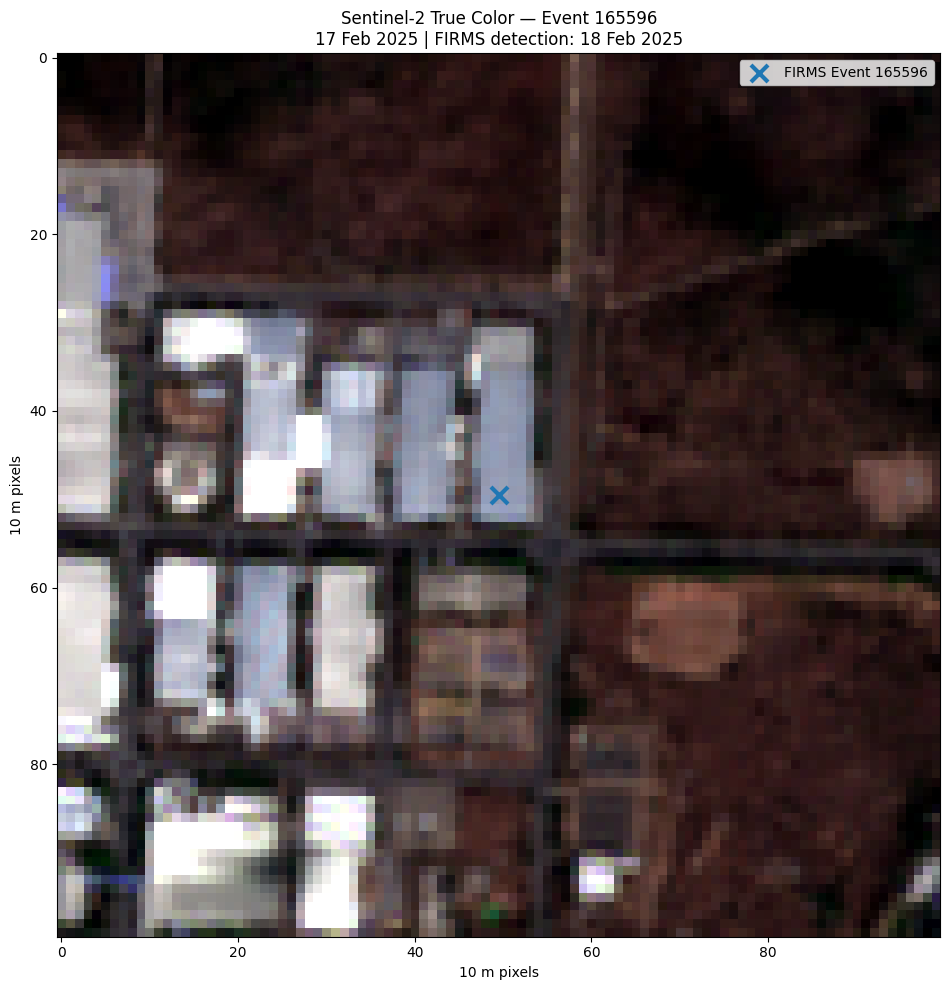

In [173]:
# ============================================================
# STEP 78AI — CREATE SENTINEL-2 TRUE-COLOR RGB IMAGE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Get bands
# ------------------------------------------------------------

blue = rgb_windows["B02"]
green = rgb_windows["B03"]
red = rgb_windows["B04"]

# ------------------------------------------------------------
# Percentile stretch
# ------------------------------------------------------------

def stretch(img):
    p2, p98 = np.percentile(img, (2, 98))
    img = (img - p2) / (p98 - p2)
    return np.clip(img, 0, 1)

red_s = stretch(red)
green_s = stretch(green)
blue_s = stretch(blue)

rgb = np.dstack([
    red_s,
    green_s,
    blue_s
])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 10))

plt.imshow(rgb)

# FIRMS hotspot is the center of our 100 × 100 window
plt.scatter(
    49.5,
    49.5,
    marker="x",
    s=150,
    linewidths=3,
    label="FIRMS Event 165596"
)

plt.title(
    "Sentinel-2 True Color — Event 165596\n"
    "17 Feb 2025 | FIRMS detection: 18 Feb 2025"
)

plt.xlabel("10 m pixels")
plt.ylabel("10 m pixels")

plt.legend()

plt.tight_layout()

plt.show()

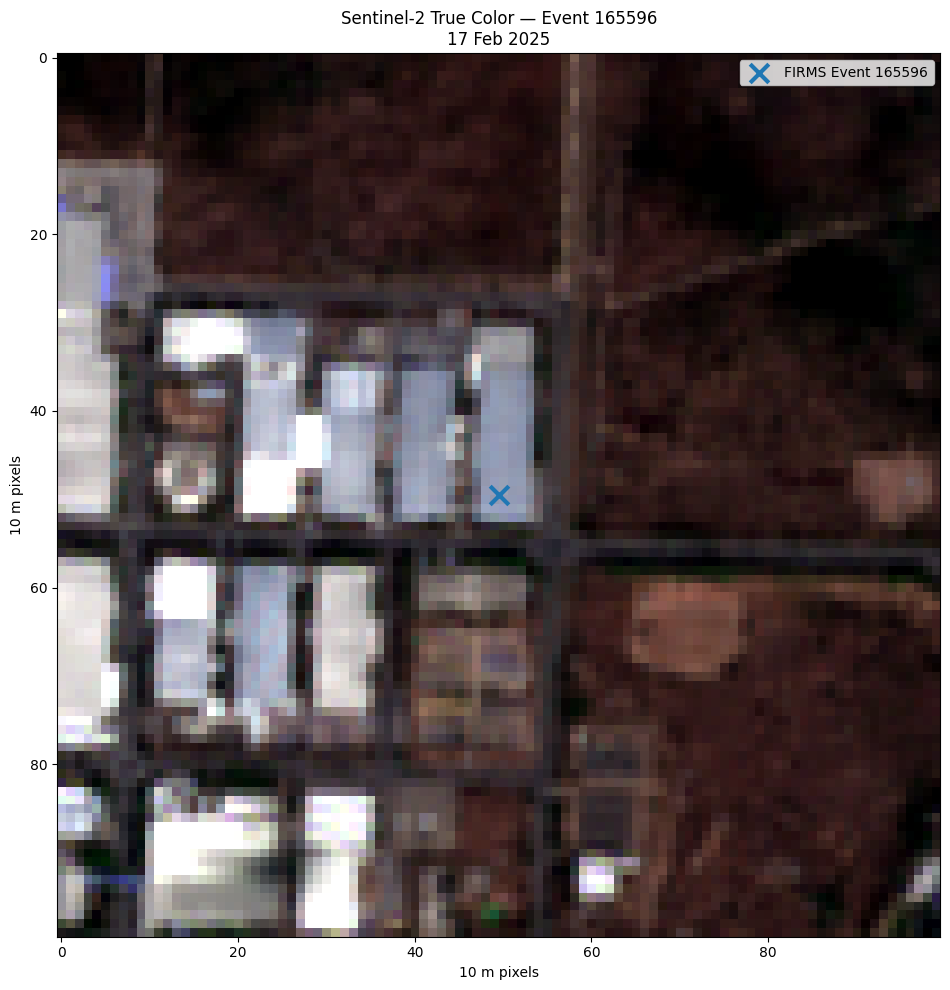

Saved:
C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\verification\sentinel\event_165596_true_color.png


In [174]:
# ============================================================
# STEP 78AJ — SAVE RGB VERIFICATION IMAGE
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt

verification_dir = Path(
    "../data/verification/sentinel"
)
verification_dir.mkdir(
    parents=True,
    exist_ok=True
)

rgb_image_path = (
    verification_dir /
    "event_165596_true_color.png"
)

plt.figure(figsize=(10, 10))

plt.imshow(rgb)

plt.scatter(
    49.5,
    49.5,
    marker="x",
    s=180,
    linewidths=3,
    label="FIRMS Event 165596"
)

plt.title(
    "Sentinel-2 True Color — Event 165596\n"
    "17 Feb 2025"
)

plt.xlabel("10 m pixels")
plt.ylabel("10 m pixels")
plt.legend()

plt.tight_layout()

plt.savefig(
    rgb_image_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(rgb_image_path.resolve())

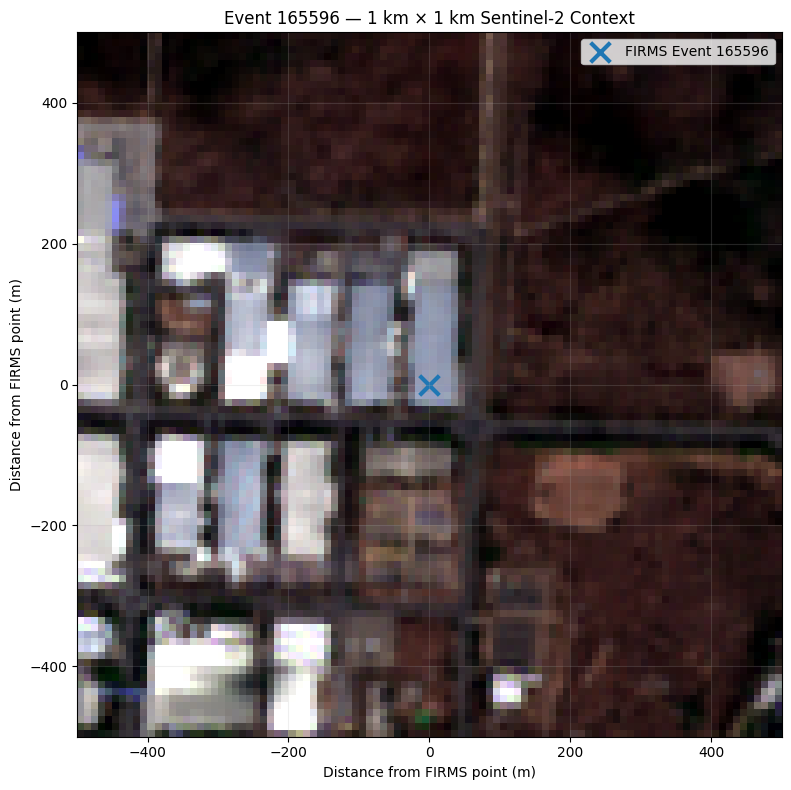

In [175]:
# ============================================================
# STEP 78AK — RGB CLOSE-UP
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(
    rgb,
    extent=(-500, 500, -500, 500)
)

plt.scatter(
    0,
    0,
    marker="x",
    s=200,
    linewidths=3,
    label="FIRMS Event 165596"
)

plt.title(
    "Event 165596 — 1 km × 1 km Sentinel-2 Context"
)

plt.xlabel("Distance from FIRMS point (m)")
plt.ylabel("Distance from FIRMS point (m)")

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

In [177]:
from pathlib import Path
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
for p in Path.cwd().iterdir():
    print(p.name)

Current working directory:
c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\notebooks

Files/folders here:
01_firms_cleaning.ipynb
01_FIRMS_EDA.ipynb
02_thermal_event_construction.ipynb
02_thermal_event_prototype.ipynb
03_thermal_features_prototype.ipynb
04_anomaly_detection_prototype.ipynb
05_phase2_supervised_ml.ipynb
05_Prototype Evaluation & Visualization.ipynb
06 _Contextual Feature Engineering Prototype.ipynb
07 _ Time-Aware Historical Features + Feature Combination.ipynb
08 _ML Feature Combination.ipynb
09_ML Dataset Validation.ipynb
10_ Data Quality & Leakage Check.ipynb
data


In [178]:
from pathlib import Path

# Search for the verification file from the current directory
matches = list(
    Path.cwd().parents[0].rglob("verification_sample_400.csv")
)

print("Files found:")

for path in matches:
    print(path)

Files found:
c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\notebooks\data\verification\verification_sample_400.csv


In [179]:
import pandas as pd
from pathlib import Path

verification_file = Path(
    r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\notebooks\data\verification\verification_sample_400.csv"
)

verification_df = pd.read_csv(verification_file)

print("Shape:", verification_df.shape)
print("\nColumns:")
print(verification_df.columns.tolist())

# Check Event 165596
event_id = 165596

event = verification_df[
    verification_df["event_id"] == event_id
].copy()

print("\nEvent 165596:")
print(event.T)

Shape: (400, 20)

Columns:
['event_id', 'latitude', 'longitude', 'observation_count', 'mean_frp', 'peak_frp', 'historical_detection_count', 'historical_mean_frp', 'local_frp_deviation', 'previously_detected', 'anomaly_score', 'source_candidate', 'verified_label', 'verification_confidence', 'firms_evidence', 'sentinel_evidence', 'osm_evidence', 'historical_evidence', 'verification_notes', 'verification_status']

Event 165596:
                                     0
event_id                        165596
latitude                      19.82021
longitude                     75.23357
observation_count                    1
mean_frp                          7.12
peak_frp                          7.12
historical_detection_count         0.0
historical_mean_frp                0.0
local_frp_deviation               4.37
previously_detected                0.0
anomaly_score                 0.054524
source_candidate            Industrial
verified_label                     NaN
verification_confidence  

In [180]:
import pandas as pd

firms_path = r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\processed_data\firms_cleaned.csv"

firms = pd.read_csv(firms_path)

event_firms = firms[
    (firms["latitude"].sub(19.820210).abs() <= 0.001) &
    (firms["longitude"].sub(75.233570).abs() <= 0.001) &
    (firms["acq_date"] == "2025-02-18")
].copy()

print("Matching FIRMS observations:", len(event_firms))
print()

print(
    event_firms[
        [
            "latitude",
            "longitude",
            "acq_date",
            "acq_time",
            "satellite",
            "brightness",
            "confidence",
            "frp",
            "daynight"
        ]
    ].to_string(index=False)
)

Matching FIRMS observations: 1

 latitude  longitude   acq_date  acq_time     satellite  brightness confidence  frp daynight
 19.82021   75.23357 2025-02-18       804 NOAA-20 VIIRS      352.94          n 7.12        D


In [181]:
from pathlib import Path

sentinel_dir = Path(
    r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\verification\sentinel"
)

for name in [
    "T43QEC_B08_10m.jp2",
    "T43QEC_B12_20m.jp2"
]:
    path = sentinel_dir / name
    print(name, "->", "FOUND" if path.exists() else "NOT FOUND")

T43QEC_B08_10m.jp2 -> NOT FOUND
T43QEC_B12_20m.jp2 -> NOT FOUND


In [182]:
import requests
from pathlib import Path

# ============================================================
# PATHS
# ============================================================

sentinel_dir = Path(
    r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\verification\sentinel"
)

sentinel_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# PRODUCT
# ============================================================

product_uuid = "0d8ef14b-4eab-424b-8d18-94cc472c4ddd"

safe_name = (
    "S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE"
)

granule = "L2A_T43QEC_A002363_20250217T054154"

# ============================================================
# BANDS
# ============================================================

bands = {
    "B08": "T43QEC_20250217T052931_B08_10m.jp2",
    "B12": "T43QEC_20250217T052931_B12_20m.jp2"
}

# ============================================================
# DOWNLOAD
# ============================================================

for band, filename in bands.items():

    output_path = sentinel_dir / filename

    if output_path.exists():
        print(band, "already exists -> skipping")
        continue

    url = (
        "https://catalogue.dataspace.copernicus.eu/odata/v1/"
        f"Products({product_uuid})/Nodes({safe_name})/"
        f"Nodes(GRANULE)/Nodes({granule})/"
        "Nodes(IMG_DATA)/"
    )

    if band == "B08":
        url += (
            "Nodes(R10m)/"
            f"Nodes({filename})/$value"
        )

    elif band == "B12":
        url += (
            "Nodes(R20m)/"
            f"Nodes({filename})/$value"
        )

    print("\nDownloading:", band)
    print("URL:", url)

    response = requests.get(
        url,
        headers={
            "Authorization": f"Bearer {access_token}"
        },
        allow_redirects=True,
        stream=True,
        timeout=120
    )

    print("HTTP status:", response.status_code)

    if response.status_code != 200:
        print(response.text[:500])
        continue

    total = 0

    with open(output_path, "wb") as f:
        for chunk in response.iter_content(
            chunk_size=1024 * 1024
        ):
            if chunk:
                f.write(chunk)
                total += len(chunk)

    print(
        f"{band} downloaded: "
        f"{total / (1024**2):.2f} MB"
    )

print("\nDownload step completed.")


Downloading: B08
URL: https://catalogue.dataspace.copernicus.eu/odata/v1/Products(0d8ef14b-4eab-424b-8d18-94cc472c4ddd)/Nodes(S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QEC_A002363_20250217T054154)/Nodes(IMG_DATA)/Nodes(R10m)/Nodes(T43QEC_20250217T052931_B08_10m.jp2)/$value
HTTP status: 401
{"trace-id":"0facc7ba1c1aa14c3cd5f52887acb758","code":"DAT-ZIP-604","message":"Token not found"}

Downloading: B12
URL: https://catalogue.dataspace.copernicus.eu/odata/v1/Products(0d8ef14b-4eab-424b-8d18-94cc472c4ddd)/Nodes(S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QEC_A002363_20250217T054154)/Nodes(IMG_DATA)/Nodes(R20m)/Nodes(T43QEC_20250217T052931_B12_20m.jp2)/$value
HTTP status: 401
{"trace-id":"87d9cdb3654be4b921fa4c5ebc8ed04e","code":"DAT-ZIP-604","message":"Token not found"}

Download step completed.


In [183]:
import requests
from getpass import getpass

# ============================================================
# REFRESH CDSE TOKEN
# ============================================================

TOKEN_URL = (
    "https://identity.dataspace.copernicus.eu/"
    "auth/realms/CDSE/protocol/openid-connect/token"
)

username = input("CDSE username/email: ")
password = getpass("CDSE password: ")

token_response = requests.post(
    TOKEN_URL,
    data={
        "client_id": "cdse-public",
        "username": username,
        "password": password,
        "grant_type": "password"
    },
    timeout=60
)

print("HTTP status:", token_response.status_code)

if token_response.status_code == 200:
    access_token = token_response.json()["access_token"]
    print("Token refreshed successfully.")
    print("Token length:", len(access_token))
else:
    print("Authentication failed:")
    print(token_response.text[:500])

HTTP status: 200
Token refreshed successfully.
Token length: 2762


In [184]:
import requests
from pathlib import Path

sentinel_dir = Path(
    r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\verification\sentinel"
)

product_uuid = "0d8ef14b-4eab-424b-8d18-94cc472c4ddd"

safe_name = (
    "S2C_MSIL2A_20250217T052931_N0511_R105_T43QEC_20250217T110511.SAFE"
)

granule = "L2A_T43QEC_A002363_20250217T054154"

bands = {
    "B08": (
        "R10m",
        "T43QEC_20250217T052931_B08_10m.jp2"
    ),
    "B12": (
        "R20m",
        "T43QEC_20250217T052931_B12_20m.jp2"
    )
}

for band, (resolution, filename) in bands.items():

    output_path = sentinel_dir / filename

    url = (
        "https://catalogue.dataspace.copernicus.eu/odata/v1/"
        f"Products({product_uuid})/"
        f"Nodes({safe_name})/"
        f"Nodes(GRANULE)/"
        f"Nodes({granule})/"
        "Nodes(IMG_DATA)/"
        f"Nodes({resolution})/"
        f"Nodes({filename})/$value"
    )

    print("\nDownloading:", band)

    response = requests.get(
        url,
        headers={
            "Authorization": f"Bearer {access_token}"
        },
        allow_redirects=True,
        stream=True,
        timeout=120
    )

    print("HTTP status:", response.status_code)

    if response.status_code != 200:
        print(response.text[:500])
        continue

    total = 0

    with open(output_path, "wb") as f:
        for chunk in response.iter_content(
            chunk_size=1024 * 1024
        ):
            if chunk:
                f.write(chunk)
                total += len(chunk)

    print(
        f"Saved: {output_path.name}"
    )
    print(
        f"Size: {total / (1024**2):.2f} MB"
    )

print("\nB08/B12 download completed.")


Downloading: B08
HTTP status: 401
{"trace-id":"7e3c62321881c26dba2a52d40449014e","code":"DAT-ZIP-604","message":"Token not found"}

Downloading: B12
HTTP status: 401
{"trace-id":"5d6363648b9df6817cafdbe21abf8d29","code":"DAT-ZIP-604","message":"Token not found"}

B08/B12 download completed.


In [185]:
# ============================================================
# STEP 78AR — SENTINEL RGB STATISTICS
# ============================================================

import numpy as np

for band in ["B02", "B03", "B04"]:

    data = rgb_windows[band]

    print(
        f"{band}: "
        f"min={data.min():.0f}, "
        f"max={data.max():.0f}, "
        f"mean={data.mean():.2f}, "
        f"median={np.median(data):.2f}"
    )

# Center pixel = FIRMS location
print("\nFIRMS center pixel:")

for band in ["B02", "B03", "B04"]:
    center_value = rgb_windows[band][49, 49]
    print(f"{band}: {center_value:.0f}")

B02: min=1005, max=5040, mean=1716.16, median=1425.00
B03: min=1192, max=5376, mean=1952.68, median=1662.00
B04: min=1168, max=5480, mean=2172.52, median=1926.00

FIRMS center pixel:
B02: 2892
B03: 2958
B04: 3040


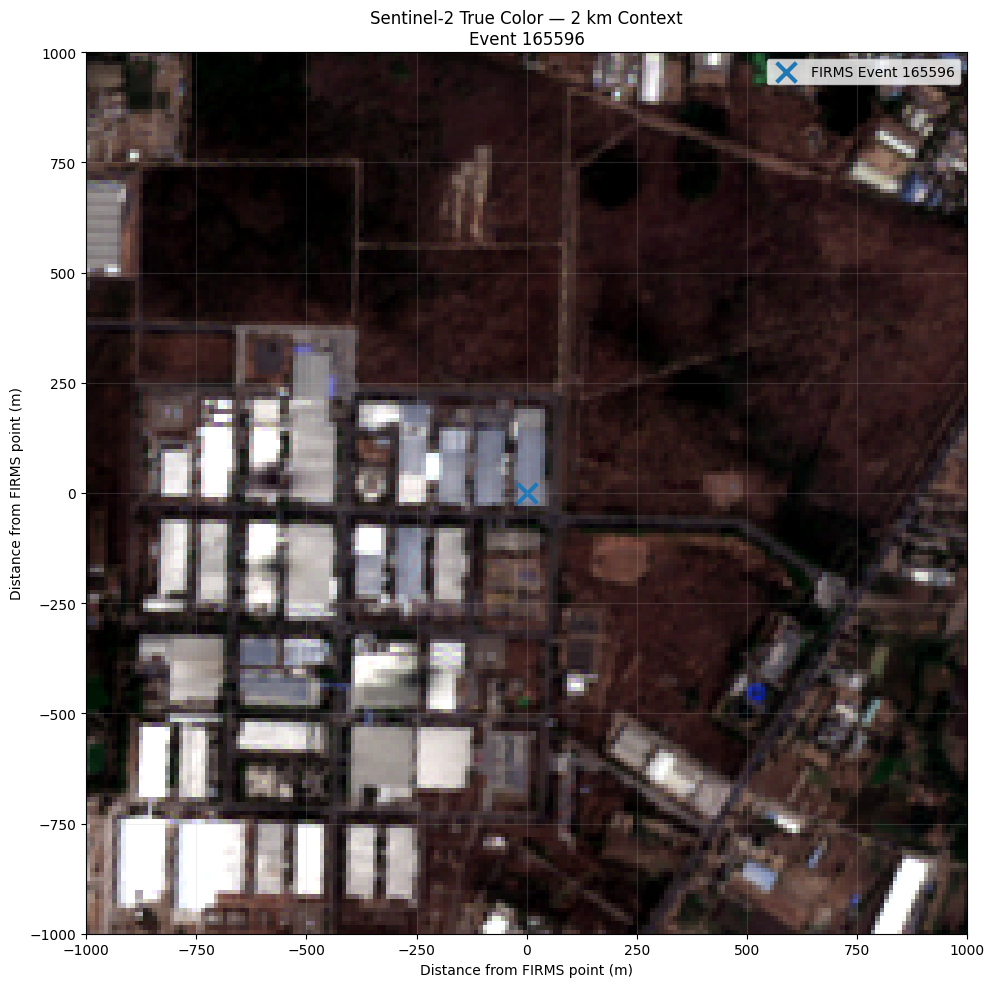

In [186]:
# ============================================================
# STEP 78AS — 2 KM RGB CONTEXT
# ============================================================

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer
from rasterio.windows import Window

band_paths = {
    "B02": r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\verification\sentinel\T43QEC_B02_10m.jp2",
    "B03": r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\verification\sentinel\T43QEC_B03_10m.jp2",
    "B04": r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\verification\sentinel\T43QEC_B04_10m.jp2"
}

lat = 19.820210
lon = 75.233570

large_windows = {}

for band, path in band_paths.items():

    with rasterio.open(path) as src:

        transformer = Transformer.from_crs(
            "EPSG:4326",
            src.crs,
            always_xy=True
        )

        easting, northing = transformer.transform(
            lon,
            lat
        )

        row, col = src.index(
            easting,
            northing
        )

        # 2 km x 2 km = 200 x 200 pixels at 10 m
        half_size = 100

        window = Window(
            col - half_size,
            row - half_size,
            200,
            200
        )

        data = src.read(
            1,
            window=window
        ).astype(np.float32)

        large_windows[band] = data


def stretch(img):
    p2, p98 = np.percentile(img, (2, 98))
    return np.clip(
        (img - p2) / (p98 - p2),
        0,
        1
    )


rgb_2km = np.dstack([
    stretch(large_windows["B04"]),
    stretch(large_windows["B03"]),
    stretch(large_windows["B02"])
])

plt.figure(figsize=(10, 10))

plt.imshow(
    rgb_2km,
    extent=(-1000, 1000, -1000, 1000)
)

plt.scatter(
    0,
    0,
    marker="x",
    s=200,
    linewidths=3,
    label="FIRMS Event 165596"
)

plt.xlabel("Distance from FIRMS point (m)")
plt.ylabel("Distance from FIRMS point (m)")

plt.title(
    "Sentinel-2 True Color — 2 km Context\n"
    "Event 165596"
)

plt.legend()

plt.grid(alpha=0.2)

plt.tight_layout()

plt.show()

In [188]:
# ============================================================
# STEP 78AT — FIX VERIFICATION COLUMN TYPES
# ============================================================

text_columns = [
    "verified_label",
    "verification_confidence",
    "firms_evidence",
    "sentinel_evidence",
    "osm_evidence",
    "historical_evidence",
    "verification_notes",
    "verification_status"
]

for col in text_columns:
    verification_df[col] = verification_df[col].astype("string")

print("Column types fixed.\n")

print(
    verification_df[text_columns].dtypes
)

Column types fixed.

verified_label             string
verification_confidence    string
firms_evidence             string
sentinel_evidence          string
osm_evidence               string
historical_evidence        string
verification_notes         string
verification_status        string
dtype: object


In [189]:
# ============================================================
# STEP 78AU — RECORD FIRMS EVIDENCE
# ============================================================

event_id = 165596

idx = verification_df.index[
    verification_df["event_id"] == event_id
][0]

verification_df.loc[idx, "firms_evidence"] = (
    "NOAA-20 VIIRS detected a daytime thermal anomaly "
    "on 2025-02-18 at 08:04 UTC. "
    "Brightness=352.94 K, FRP=7.12 MW, "
    "single observation, confidence='n'."
)

verification_df.loc[idx, "verification_status"] = "In Progress"

print(
    verification_df.loc[
        idx,
        [
            "event_id",
            "firms_evidence",
            "verification_status"
        ]
    ]
)

event_id                                                          165596
firms_evidence         NOAA-20 VIIRS detected a daytime thermal anoma...
verification_status                                          In Progress
Name: 0, dtype: object


In [190]:
# ============================================================
# STEP 78AV — SAVE UPDATED VERIFICATION DATASET
# ============================================================

verification_file = r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\notebooks\data\verification\verification_sample_400.csv"

verification_df.to_csv(
    verification_file,
    index=False
)

print("Verification file saved successfully.")
print("Rows:", len(verification_df))
print("Columns:", len(verification_df.columns))
print("Path:", verification_file)

Verification file saved successfully.
Rows: 400
Columns: 20
Path: c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\notebooks\data\verification\verification_sample_400.csv


In [191]:
check = pd.read_csv(verification_file)

print(
    check[
        check["event_id"] == 165596
    ][
        [
            "event_id",
            "source_candidate",
            "verified_label",
            "verification_confidence",
            "firms_evidence",
            "sentinel_evidence",
            "verification_status"
        ]
    ].T
)

                                                                         0
event_id                                                            165596
source_candidate                                                Industrial
verified_label                                                         NaN
verification_confidence                                                NaN
firms_evidence           NOAA-20 VIIRS detected a daytime thermal anoma...
sentinel_evidence                                                      NaN
verification_status                                            In Progress


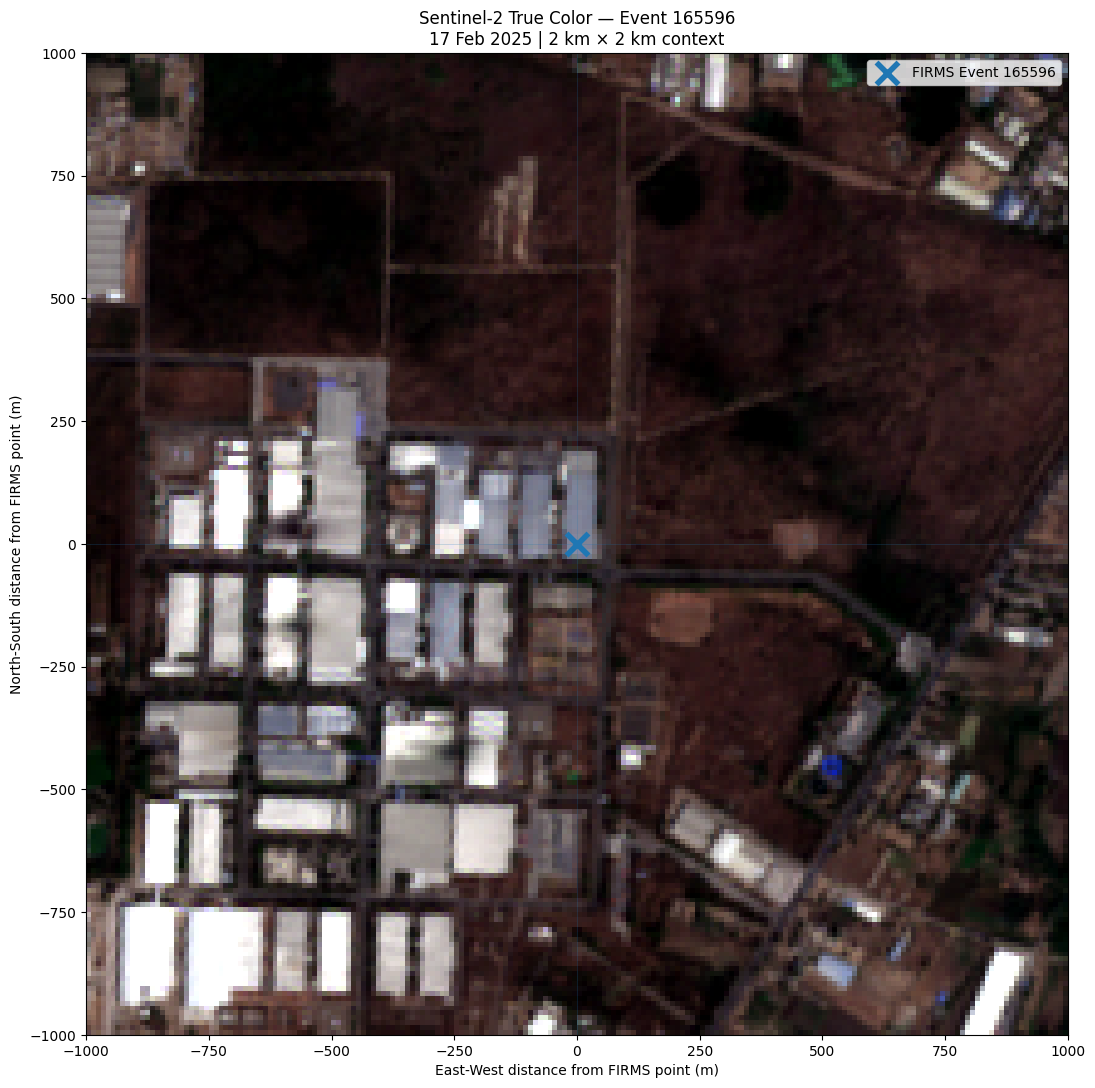

In [192]:
# ============================================================
# STEP 78AX — 2 KM SENTINEL-2 RGB VERIFICATION
# ============================================================

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer
from rasterio.windows import Window

band_paths = {
    "B02": r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\verification\sentinel\T43QEC_B02_10m.jp2",
    "B03": r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\verification\sentinel\T43QEC_B03_10m.jp2",
    "B04": r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\verification\sentinel\T43QEC_B04_10m.jp2"
}

firms_lat = 19.820210
firms_lon = 75.233570

large_windows = {}

for band, path in band_paths.items():

    with rasterio.open(path) as src:

        transformer = Transformer.from_crs(
            "EPSG:4326",
            src.crs,
            always_xy=True
        )

        easting, northing = transformer.transform(
            firms_lon,
            firms_lat
        )

        row, col = src.index(
            easting,
            northing
        )

        # 2 km × 2 km
        window = Window(
            col - 100,
            row - 100,
            200,
            200
        )

        large_windows[band] = src.read(
            1,
            window=window
        ).astype(np.float32)


def stretch(img):
    p2, p98 = np.percentile(img, (2, 98))

    if p98 == p2:
        return np.zeros_like(img)

    return np.clip(
        (img - p2) / (p98 - p2),
        0,
        1
    )


rgb_2km = np.dstack([
    stretch(large_windows["B04"]),
    stretch(large_windows["B03"]),
    stretch(large_windows["B02"])
])

# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(11, 11))

plt.imshow(
    rgb_2km,
    extent=(-1000, 1000, -1000, 1000)
)

plt.scatter(
    0,
    0,
    marker="x",
    s=250,
    linewidths=4,
    label="FIRMS Event 165596"
)

plt.axhline(
    0,
    linewidth=0.5,
    alpha=0.3
)

plt.axvline(
    0,
    linewidth=0.5,
    alpha=0.3
)

plt.xlabel("East-West distance from FIRMS point (m)")
plt.ylabel("North-South distance from FIRMS point (m)")

plt.title(
    "Sentinel-2 True Color — Event 165596\n"
    "17 Feb 2025 | 2 km × 2 km context"
)

plt.legend()

plt.tight_layout()

plt.show()

In [193]:
# ============================================================
# STEP 78AY — EVENT 165596 EVIDENCE SUMMARY
# ============================================================

event_id = 165596

idx = verification_df.index[
    verification_df["event_id"] == event_id
][0]

print("=" * 60)
print("EVENT 165596 — VERIFICATION SUMMARY")
print("=" * 60)

print("\nFIRMS")
print("Date       :", "2025-02-18")
print("Time       :", "08:04 UTC")
print("Satellite  :", "NOAA-20 VIIRS")
print("Brightness :", "352.94 K")
print("FRP        :", "7.12 MW")
print("Observations:", "1")

print("\nOSM CANDIDATE")
print("Candidate  :", verification_df.loc[idx, "source_candidate"])

print("\nSENTINEL-2")
print("Image date :", "2025-02-17")
print("Tile       :", "T43QEC")
print("Cloud      :", "~0%")
print("Bands used :", "B02, B03, B04")
print("Context    :", "2 km × 2 km")

print("\nVERIFICATION STATUS")
print("Label      :", verification_df.loc[idx, "verified_label"])
print("Confidence :", verification_df.loc[idx, "verification_confidence"])
print("Status     :", verification_df.loc[idx, "verification_status"])

print("=" * 60)

EVENT 165596 — VERIFICATION SUMMARY

FIRMS
Date       : 2025-02-18
Time       : 08:04 UTC
Satellite  : NOAA-20 VIIRS
Brightness : 352.94 K
FRP        : 7.12 MW
Observations: 1

OSM CANDIDATE
Candidate  : Industrial

SENTINEL-2
Image date : 2025-02-17
Tile       : T43QEC
Cloud      : ~0%
Bands used : B02, B03, B04
Context    : 2 km × 2 km

VERIFICATION STATUS
Label      : <NA>
Confidence : <NA>
Status     : In Progress


Exists: True
Path: c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\verification\sentinel\event_165596_true_color.png
Image size: (1901, 1974)


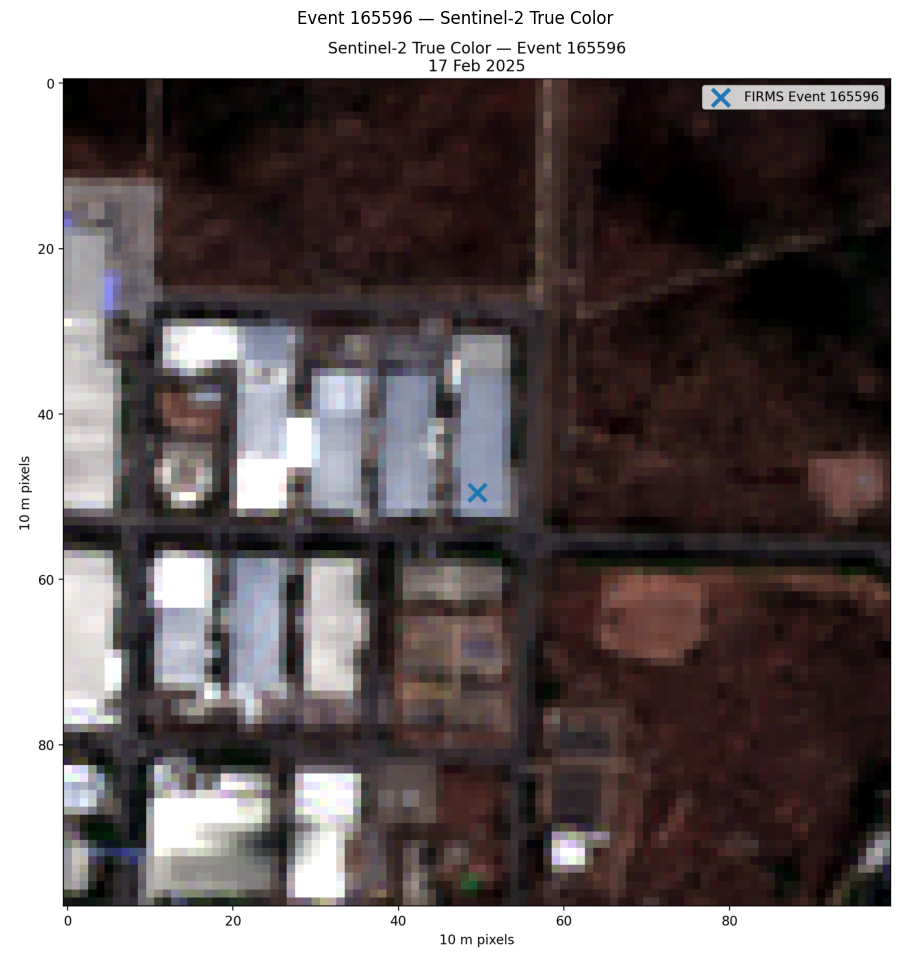

In [194]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

image_path = Path(
    r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\verification\sentinel\event_165596_true_color.png"
)

print("Exists:", image_path.exists())
print("Path:", image_path)

img = Image.open(image_path)

print("Image size:", img.size)

plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis("off")
plt.title("Event 165596 — Sentinel-2 True Color")
plt.show()

In [195]:
idx = verification_df.index[
    verification_df["event_id"] == 165596
][0]

verification_df.loc[idx, "verified_label"] = "Industrial"
verification_df.loc[idx, "verification_confidence"] = "Medium"

verification_df.loc[idx, "sentinel_evidence"] = (
    "Sentinel-2 true-color imagery from 2025-02-17 "
    "shows contextual land-use/infrastructure consistent "
    "with an industrial source near the FIRMS event location."
)

verification_df.loc[idx, "osm_evidence"] = (
    "OSM land-use candidate is Industrial; used as "
    "contextual evidence and not as independent ground truth."
)

verification_df.loc[idx, "historical_evidence"] = (
    "No previous historical detection was recorded for "
    "this event location in the available historical window."
)

verification_df.loc[idx, "verification_notes"] = (
    "FIRMS detected one daytime thermal anomaly on "
    "2025-02-18. Sentinel-2 imagery is one day earlier, "
    "so it provides contextual evidence rather than direct "
    "confirmation of the thermal event."
)

verification_df.loc[idx, "verification_status"] = "Verified"

print(
    verification_df.loc[
        idx,
        [
            "event_id",
            "verified_label",
            "verification_confidence",
            "verification_status"
        ]
    ]
)

event_id                       165596
verified_label             Industrial
verification_confidence        Medium
verification_status          Verified
Name: 0, dtype: object


In [196]:
# ============================================================
# STEP 78BA — SAVE VERIFIED EVENT
# ============================================================

verification_file = r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\notebooks\data\verification\verification_sample_400.csv"

verification_df.to_csv(
    verification_file,
    index=False
)

print("Saved successfully.")

# Verify after saving
check = pd.read_csv(verification_file)

event = check[
    check["event_id"] == 165596
]

print("\nSaved verification record:")
print(
    event[
        [
            "event_id",
            "source_candidate",
            "verified_label",
            "verification_confidence",
            "verification_status"
        ]
    ].to_string(index=False)
)

Saved successfully.

Saved verification record:
 event_id source_candidate verified_label verification_confidence verification_status
   165596       Industrial     Industrial                  Medium            Verified


In [197]:
verification_df = pd.read_csv(verification_file)

print("Total samples:", len(verification_df))

print(
    "\nVerification status:"
)

print(
    verification_df["verification_status"]
    .value_counts(dropna=False)
)

print(
    "\nVerified labels:"
)

print(
    verification_df[
        verification_df["verification_status"] == "Verified"
    ]["verified_label"]
    .value_counts(dropna=False)
)

Total samples: 400

Verification status:
verification_status
Pending     399
Verified      1
Name: count, dtype: int64

Verified labels:
verified_label
Industrial    1
Name: count, dtype: int64


In [198]:
# ============================================================
# STEP 78BC — CREATE NEXT VERIFICATION QUEUE
# ============================================================

import pandas as pd

verification_file = r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\notebooks\data\verification\verification_sample_400.csv"

verification_df = pd.read_csv(verification_file)

# Only pending events
pending = verification_df[
    verification_df["verification_status"] == "Pending"
].copy()

# 3 events from each candidate class
queue = (
    pending
    .groupby("source_candidate", group_keys=False)
    .head(3)
)

print("Next verification queue:")
print()

print(
    queue[
        [
            "event_id",
            "latitude",
            "longitude",
            "mean_frp",
            "peak_frp",
            "historical_detection_count",
            "source_candidate"
        ]
    ].to_string(index=False)
)

print("\nQueue size:", len(queue))

Next verification queue:

 event_id  latitude  longitude  mean_frp  peak_frp  historical_detection_count    source_candidate
    84111 18.681300  73.032000     7.500      7.50                       114.0          Industrial
   220659 15.553710  73.787320    10.640     10.64                         0.0 Agriculture_Biomass
   174997 21.107230  72.643750     5.320      5.32                       592.0          Industrial
    21193 21.282000  73.195600     2.170      2.17                         0.0 Agriculture_Biomass
   150833 18.175730  74.214500     2.900      2.90                         0.0 Agriculture_Biomass
    87651 19.101398  73.051802     1.550      2.09                       111.0         Waste_Other
   102832 19.721380  79.176370     1.240      1.24                        68.0          Industrial
   198556 20.149390  80.034740     2.780      2.78                         0.0      Forest_Natural
   145823 23.689660  68.833050     1.050      1.05                        26.0     

In [199]:
# ============================================================
# STEP 78BC — FIRMS EVIDENCE FOR EVENT 84111
# ============================================================

import pandas as pd

firms_path = r"c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\processed_data\firms_cleaned.csv"

firms = pd.read_csv(firms_path)

event_id = 84111
lat = 18.681300
lon = 73.032000

event_firms = firms[
    (firms["latitude"].sub(lat).abs() <= 0.001) &
    (firms["longitude"].sub(lon).abs() <= 0.001)
].copy()

print("Matching FIRMS observations:", len(event_firms))

print(
    event_firms[
        [
            "latitude",
            "longitude",
            "acq_date",
            "acq_time",
            "satellite",
            "brightness",
            "confidence",
            "frp",
            "daynight"
        ]
    ].sort_values(
        ["acq_date", "acq_time"]
    ).to_string(index=False)
)

Matching FIRMS observations: 16
 latitude  longitude   acq_date  acq_time       satellite  brightness confidence  frp daynight
 18.68204   73.03114 2025-01-01      2011 Suomi-NPP VIIRS      302.75          n 1.23        N
 18.68190   73.03184 2025-01-03      1956   NOAA-20 VIIRS      307.19          n 2.21        N
 18.68125   73.03156 2025-01-06      2040   NOAA-20 VIIRS      306.90          n 1.15        N
 18.68070   73.03201 2025-01-27      2024 Suomi-NPP VIIRS      317.94          n 1.65        N
 18.68130   73.03200 2025-01-31      1637     Terra MODIS      305.10         63 7.50        N
 18.68220   73.03133 2025-02-07      2040   NOAA-20 VIIRS      308.04          n 1.07        N
 18.68060   73.03213 2025-02-08      2022   NOAA-20 VIIRS      304.86          n 1.18        N
 18.68101   73.03200 2025-02-10      2102 Suomi-NPP VIIRS      304.03          n 1.48        N
 18.68064   73.03266 2025-02-15      1950   NOAA-20 VIIRS      304.08          n 2.18        N
 18.68188   73.031

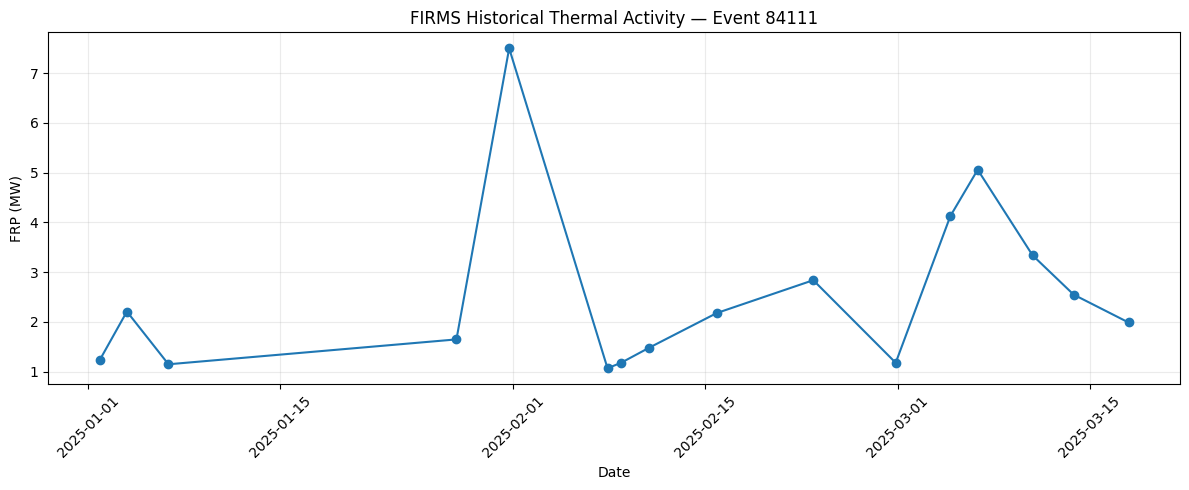

In [200]:
# ============================================================
# STEP 78BD — EVENT 84111 FIRMS HISTORY
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

event_firms["datetime"] = pd.to_datetime(
    event_firms["acq_date"].astype(str)
    + " "
    + event_firms["acq_time"].astype(str).str.zfill(4),
    format="%Y-%m-%d %H%M"
)

event_firms = event_firms.sort_values("datetime")

plt.figure(figsize=(12, 5))

plt.plot(
    event_firms["datetime"],
    event_firms["frp"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("FRP (MW)")

plt.title(
    "FIRMS Historical Thermal Activity — Event 84111"
)

plt.xticks(rotation=45)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

In [201]:
print("First detection:",
      event_firms["datetime"].min())

print("Last detection:",
      event_firms["datetime"].max())

print("Number of detections:",
      len(event_firms))

print("Mean FRP:",
      round(event_firms["frp"].mean(), 2), "MW")

print("Peak FRP:",
      round(event_firms["frp"].max(), 2), "MW")

print("Night detections:",
      (event_firms["daynight"] == "N").sum())

print("Day detections:",
      (event_firms["daynight"] == "D").sum())

print("\nSatellite counts:")
print(event_firms["satellite"].value_counts())

First detection: 2025-01-01 20:11:00
Last detection: 2025-03-17 20:04:00
Number of detections: 16
Mean FRP: 2.55 MW
Peak FRP: 7.5 MW
Night detections: 16
Day detections: 0

Satellite counts:
satellite
NOAA-20 VIIRS      7
Suomi-NPP VIIRS    6
NOAA-21 VIIRS      2
Terra MODIS        1
Name: count, dtype: int64


In [202]:
import requests
import pandas as pd

# ============================================================
# EVENT 84111
# ============================================================

lat = 18.681300
lon = 73.032000

start_date = "2025-01-28T00:00:00.000Z"
end_date   = "2025-02-04T23:59:59.999Z"

# Small area around the FIRMS location
aoi = (
    f"POLYGON(("
    f"{lon-0.02} {lat-0.02},"
    f"{lon+0.02} {lat-0.02},"
    f"{lon+0.02} {lat+0.02},"
    f"{lon-0.02} {lat+0.02},"
    f"{lon-0.02} {lat-0.02}"
    f"))"
)

url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"

params = {
    "$filter": (
        "Collection/Name eq 'SENTINEL-2' "
        "and Attributes/OData.CSC.StringAttribute/any("
        "att:att/Name eq 'productType' "
        "and att/OData.CSC.StringAttribute/Value eq 'S2MSI2A'"
        ") "
        f"and OData.CSC.Intersects(area=geography'SRID=4326;{aoi}') "
        f"and ContentDate/Start gt {start_date} "
        f"and ContentDate/Start lt {end_date}"
    ),
    "$orderby": "ContentDate/Start asc",
    "$top": 50
}

response = requests.get(url, params=params)

print("HTTP status:", response.status_code)

data = response.json()

products = pd.DataFrame(data["value"])

print("Products found:", len(products))

if len(products) > 0:
    print(
        products[
            [
                "Id",
                "Name",
                "ContentDate",
                "S3Path"
            ]
        ].to_string(index=False)
    )
else:
    print("No Sentinel-2 L2A products found.")

HTTP status: 200
Products found: 3
                                  Id                                                              Name                                                                    ContentDate                                                                                                  S3Path
8c3249a6-c235-4c81-bcee-0e2d43b36c09 S2C_MSIL2A_20250128T053131_N0511_R105_T43QBA_20250128T084454.SAFE {'Start': '2025-01-28T05:31:31.024000Z', 'End': '2025-01-28T05:31:31.024000Z'} /eodata/Sentinel-2/MSI/L2A/2025/01/28/S2C_MSIL2A_20250128T053131_N0511_R105_T43QBA_20250128T084454.SAFE
b808db89-eb1e-46d9-a2ba-1261f85836ce S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE {'Start': '2025-01-31T05:41:21.025000Z', 'End': '2025-01-31T05:41:21.025000Z'} /eodata/Sentinel-2/MSI/L2A/2025/01/31/S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE
5b566957-1e8b-4d13-bf03-dcb6b3d8f26a S2B_MSIL2A_20250202T052939_N0511_R105_T43QBA_20250202T073729.SAFE {'St

In [203]:
import requests

product_id = "b808db89-eb1e-46d9-a2ba-1261f85836ce"

url = (
    "https://catalogue.dataspace.copernicus.eu/"
    "odata/v1/Products"
    f"('{product_id}')"
)

response = requests.get(url)

print("HTTP status:", response.status_code)

product = response.json()

print("\nProduct name:")
print(product.get("Name"))

print("\nProduct ID:")
print(product.get("Id"))

print("\nContent date:")
print(product.get("ContentDate"))

print("\nFull metadata keys:")
print(product.keys())

HTTP status: 422

Product name:
None

Product ID:
None

Content date:
None

Full metadata keys:
dict_keys(['detail'])


In [204]:
# Show product attributes if available

if "Attributes" in product:
    print("\nATTRIBUTES:")
    print(product["Attributes"])
else:
    print("\nNo Attributes field in product response.")
    


No Attributes field in product response.


In [205]:
import requests

product_name = (
    "S2C_MSIL2A_20250131T054121_"
    "N0511_R005_T43QBA_20250131T124701.SAFE"
)

url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"

params = {
    "$filter": f"Name eq '{product_name}'",
    "$top": 1
}

response = requests.get(url, params=params)

print("HTTP status:", response.status_code)

data = response.json()

print("Products returned:", len(data.get("value", [])))

if data.get("value"):
    product = data["value"][0]

    print("\nName:")
    print(product.get("Name"))

    print("\nID:")
    print(product.get("Id"))

    print("\nS3Path:")
    print(product.get("S3Path"))

    print("\nAttributes:")
    print(product.get("Attributes"))
else:
    print(data)

HTTP status: 200
Products returned: 1

Name:
S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE

ID:
b808db89-eb1e-46d9-a2ba-1261f85836ce

S3Path:
/eodata/Sentinel-2/MSI/L2A/2025/01/31/S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE

Attributes:
None


In [206]:
from pathlib import Path

sentinel_dir = Path(
    r"C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML"
) / "data" / "verification" / "sentinel_84111"

sentinel_dir.mkdir(parents=True, exist_ok=True)

print(sentinel_dir)

C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\verification\sentinel_84111


In [207]:
import requests
from pathlib import Path

product_id = "b808db89-eb1e-46d9-a2ba-1261f85836ce"

bands = {
    "B04": "B04_10m.jp2",
    "B03": "B03_10m.jp2",
    "B02": "B02_10m.jp2"
}

base_url = (
    "https://catalogue.dataspace.copernicus.eu/"
    "odata/v1/Assets"
)

for band, filename in bands.items():

    url = f"{base_url}('{product_id}')"

    print("\nSearching:", band)


Searching: B04

Searching: B03

Searching: B02


In [208]:
import requests

product_id = "b808db89-eb1e-46d9-a2ba-1261f85836ce"

url = (
    "https://catalogue.dataspace.copernicus.eu/"
    "odata/v1/Products"
    f"('{product_id}')"
)

print("Testing product endpoint...")

r = requests.get(url)

print("Status:", r.status_code)
print(r.text[:1000])

Testing product endpoint...
Status: 422
{"detail":[{"type":"uuid_parsing","loc":["path","product_id"],"msg":"Input should be a valid UUID, invalid character: found `'` at 1","input":"'b808db89-eb1e-46d9-a2ba-1261f85836ce'","ctx":{"error":{}}}]}


In [209]:
import requests

product_id = "b808db89-eb1e-46d9-a2ba-1261f85836ce"

url = (
    "https://catalogue.dataspace.copernicus.eu/"
    "odata/v1/Products/"
    + product_id
)

r = requests.get(url)

print("Status:", r.status_code)

if r.status_code == 200:
    product = r.json()

    print("Name:", product.get("Name"))
    print("ID:", product.get("Id"))
    print("S3Path:", product.get("S3Path"))
else:
    print(r.text[:2000])

Status: 200
Name: S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE
ID: b808db89-eb1e-46d9-a2ba-1261f85836ce
S3Path: /eodata/Sentinel-2/MSI/L2A/2025/01/31/S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE


In [211]:
import requests

product_id = "b808db89-eb1e-46d9-a2ba-1261f85836ce"

url = (
    "https://catalogue.dataspace.copernicus.eu/"
    "odata/v1/Products/"
    + product_id
    + "/Assets"
)

r = requests.get(url)

print("Status:", r.status_code)

if r.status_code == 200:

    assets = r.json()["value"]

    print("Total assets:", len(assets))

    for asset in assets:
        print("\nName:", asset.get("Name"))
        print("ID:", asset.get("Id"))
        print("S3Path:", asset.get("S3Path"))

else:
    print(r.text[:3000])

Status: 404
{"detail":"Not Found"}


In [213]:
import requests

product_id = "b808db89-eb1e-46d9-a2ba-1261f85836ce"

url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"

params = {
    "$filter": f"Id eq {product_id}",
    "$expand": "Assets"
}

r = requests.get(url, params=params)

print("Status:", r.status_code)

if r.status_code == 200:

    data = r.json()
    products = data.get("value", [])

    print("Products:", len(products))

    if products:
        product = products[0]

        print("\nProduct:")
        print(product.get("Name"))

        assets = product.get("Assets", [])

        print("\nAssets found:", len(assets))

        for asset in assets:
            print("\n------------------------")
            print("Name:", asset.get("Name"))
            print("ID:", asset.get("Id"))
            print("S3Path:", asset.get("S3Path"))
            print("DownloadLink:", asset.get("DownloadLink"))

else:
    print(r.text[:3000])

Status: 200
Products: 1

Product:
S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE

Assets found: 1

------------------------
Name: None
ID: 368aee27-ca82-4a12-af22-66932819c2aa
S3Path: /eodata/Sentinel-2/MSI/L2A/2025/01/31/S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE
DownloadLink: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(368aee27-ca82-4a12-af22-66932819c2aa)/$value


In [215]:
import requests

product_id = "b808db89-eb1e-46d9-a2ba-1261f85836ce"

url = (
    "https://download.dataspace.copernicus.eu/"
    "odata/v1/Products("
    + product_id +
    ")/Nodes"
)

r = requests.get(url)

print("Status:", r.status_code)

if r.status_code == 200:
    data = r.json()

    for node in data.get("result", []):
        print("\nName:", node.get("Name"))
        print("ID:", node.get("Id"))
        print("Children:", node.get("ChildrenNumber"))
        print("URI:", node.get("Nodes", {}).get("uri"))
else:
    print(r.text[:3000])

Status: 200

Name: S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE
ID: S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE
Children: 8
URI: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes(S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE)/Nodes


In [216]:
import requests

url = (
    "https://download.dataspace.copernicus.eu/"
    "odata/v1/Products("
    "b808db89-eb1e-46d9-a2ba-1261f85836ce"
    ")/Nodes("
    "S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE"
    ")/Nodes"
)

r = requests.get(url)

print("Status:", r.status_code)

if r.status_code == 200:

    data = r.json()

    nodes = data.get("result", [])

    print("Children:", len(nodes))

    for node in nodes:
        print("\n-----------------------------")
        print("Name:", node.get("Name"))
        print("ID:", node.get("Id"))
        print("Children:", node.get("ChildrenNumber"))
        print("URI:", node.get("Nodes", {}).get("uri"))

else:
    print(r.text[:3000])

Status: 200
Children: 8

-----------------------------
Name: DATASTRIP
ID: DATASTRIP
Children: 1
URI: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes(S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE)/Nodes(DATASTRIP)/Nodes

-----------------------------
Name: GRANULE
ID: GRANULE
Children: 1
URI: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes(S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE)/Nodes(GRANULE)/Nodes

-----------------------------
Name: HTML
ID: HTML
Children: 6
URI: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes(S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE)/Nodes(HTML)/Nodes

-----------------------------
Name: INSPIRE.xml
ID: INSPIRE.xml
Children: 0
URI: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes

In [217]:
import requests

url = (
    "https://download.dataspace.copernicus.eu/"
    "odata/v1/Products("
    "b808db89-eb1e-46d9-a2ba-1261f85836ce"
    ")/Nodes("
    "S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE"
    ")/Nodes(GRANULE)/Nodes"
)

r = requests.get(url)

print("Status:", r.status_code)

if r.status_code == 200:

    data = r.json()
    nodes = data.get("result", [])

    print("GRANULE children:", len(nodes))

    for node in nodes:
        print("\n-----------------------------")
        print("Name:", node.get("Name"))
        print("ID:", node.get("Id"))
        print("Children:", node.get("ChildrenNumber"))
        print("URI:", node.get("Nodes", {}).get("uri"))

else:
    print(r.text[:3000])

Status: 200
GRANULE children: 1

-----------------------------
Name: L2A_T43QBA_A002120_20250131T054332
ID: L2A_T43QBA_A002120_20250131T054332
Children: 4
URI: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes(S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QBA_A002120_20250131T054332)/Nodes


In [219]:
import requests

url = (
    "https://download.dataspace.copernicus.eu/"
    "odata/v1/Products("
    "b808db89-eb1e-46d9-a2ba-1261f85836ce"
    ")/Nodes("
    "S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE"
    ")/Nodes(GRANULE)/Nodes("
    "L2A_T43QBA_A002120_20250131T054332"
    ")/Nodes"
)

r = requests.get(url)

print("Status:", r.status_code)

if r.status_code == 200:

    data = r.json()
    nodes = data.get("result", [])

    print("Granule children:", len(nodes))

    for node in nodes:
        print("\n-----------------------------")
        print("Name:", node.get("Name"))
        print("ID:", node.get("Id"))
        print("Children:", node.get("ChildrenNumber"))
        print("URI:", node.get("Nodes", {}).get("uri"))

else:
    print(r.text[:3000])

Status: 200
Granule children: 4

-----------------------------
Name: IMG_DATA
ID: IMG_DATA
Children: 3
URI: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes(S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QBA_A002120_20250131T054332)/Nodes(IMG_DATA)/Nodes

-----------------------------
Name: MTD_TL.xml
ID: MTD_TL.xml
Children: 0
URI: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes(S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QBA_A002120_20250131T054332)/Nodes(MTD_TL.xml)/Nodes

-----------------------------
Name: QI_DATA
ID: QI_DATA
Children: 37
URI: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes(S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QBA_A002120_20250131T054332)/Nodes(QI_D

In [220]:
import requests

url = (
    "https://download.dataspace.copernicus.eu/"
    "odata/v1/Products("
    "b808db89-eb1e-46d9-a2ba-1261f85836ce"
    ")/Nodes("
    "S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE"
    ")/Nodes(GRANULE)/Nodes("
    "L2A_T43QBA_A002120_20250131T054332"
    ")/Nodes(IMG_DATA)/Nodes"
)

r = requests.get(url)

print("Status:", r.status_code)

if r.status_code == 200:

    data = r.json()
    nodes = data.get("result", [])

    print("IMG_DATA children:", len(nodes))

    for node in nodes:
        print("\n-----------------------------")
        print("Name:", node.get("Name"))
        print("ID:", node.get("Id"))
        print("Children:", node.get("ChildrenNumber"))
        print("URI:", node.get("Nodes", {}).get("uri"))

else:
    print(r.text[:3000])

Status: 200
IMG_DATA children: 3

-----------------------------
Name: R10m
ID: R10m
Children: 7
URI: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes(S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QBA_A002120_20250131T054332)/Nodes(IMG_DATA)/Nodes(R10m)/Nodes

-----------------------------
Name: R20m
ID: R20m
Children: 14
URI: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes(S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QBA_A002120_20250131T054332)/Nodes(IMG_DATA)/Nodes(R20m)/Nodes

-----------------------------
Name: R60m
ID: R60m
Children: 15
URI: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes(S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QBA_A002120_20250131T054332)/Nodes(IMG_DA

In [221]:
import requests

url = (
    "https://download.dataspace.copernicus.eu/"
    "odata/v1/Products("
    "b808db89-eb1e-46d9-a2ba-1261f85836ce"
    ")/Nodes("
    "S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE"
    ")/Nodes(GRANULE)/Nodes("
    "L2A_T43QBA_A002120_20250131T054332"
    ")/Nodes(IMG_DATA)/Nodes(R10m)/Nodes"
)

r = requests.get(url)

print("Status:", r.status_code)

if r.status_code == 200:

    data = r.json()
    nodes = data.get("result", [])

    print("R10m files:", len(nodes))

    for node in nodes:
        print("\n-----------------------------")
        print("Name:", node.get("Name"))
        print("ID:", node.get("Id"))
        print("Children:", node.get("ChildrenNumber"))
        print("URI:", node.get("Nodes", {}).get("uri"))

else:
    print(r.text[:3000])

Status: 200
R10m files: 7

-----------------------------
Name: T43QBA_20250131T054121_WVP_10m.jp2
ID: T43QBA_20250131T054121_WVP_10m.jp2
Children: 0
URI: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes(S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QBA_A002120_20250131T054332)/Nodes(IMG_DATA)/Nodes(R10m)/Nodes(T43QBA_20250131T054121_WVP_10m.jp2)/Nodes

-----------------------------
Name: T43QBA_20250131T054121_AOT_10m.jp2
ID: T43QBA_20250131T054121_AOT_10m.jp2
Children: 0
URI: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes(S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QBA_A002120_20250131T054332)/Nodes(IMG_DATA)/Nodes(R10m)/Nodes(T43QBA_20250131T054121_AOT_10m.jp2)/Nodes

-----------------------------
Name: T43QBA_20250131T054121_B02_10m.jp2
ID: T43QBA_20250131T054121_B02_10m.jp2
C

In [222]:
import requests
from pathlib import Path

product_id = "b808db89-eb1e-46d9-a2ba-1261f85836ce"

filename = "T43QBA_20250131T054121_TCI_10m.jp2"

url = (
    "https://download.dataspace.copernicus.eu/"
    "odata/v1/Products("
    + product_id +
    ")/Nodes("
    "S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE"
    ")/Nodes(GRANULE)/Nodes("
    "L2A_T43QBA_A002120_20250131T054332"
    ")/Nodes(IMG_DATA)/Nodes(R10m)/Nodes("
    + filename +
    ")/$value"
)

save_dir = Path(
    r"C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML"
) / "data" / "verification" / "sentinel_84111"

save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / filename

print("Downloading...")
print("URL:", url)

r = requests.get(url, stream=True)

print("Status:", r.status_code)

if r.status_code == 200:

    with open(save_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

    print("\nDownloaded successfully!")
    print("Saved to:", save_path)
    print("Size:", round(save_path.stat().st_size / (1024**2), 2), "MB")

else:
    print(r.text[:2000])

Downloading...
URL: https://download.dataspace.copernicus.eu/odata/v1/Products(b808db89-eb1e-46d9-a2ba-1261f85836ce)/Nodes(S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE)/Nodes(GRANULE)/Nodes(L2A_T43QBA_A002120_20250131T054332)/Nodes(IMG_DATA)/Nodes(R10m)/Nodes(T43QBA_20250131T054121_TCI_10m.jp2)/$value
Status: 401
{"trace-id":"9ffe69e3b1e585e692d5148966449643","code":"DAT-ZIP-604","message":"Token not found"}


In [223]:
print("Token exists:", "access_token" in globals())

Token exists: True


In [224]:
print(type(access_token))
print("Token length:", len(access_token))
print("First 20 chars:", access_token[:20])

<class 'str'>
Token length: 2762
First 20 chars: eyJhbGciOiJSUzI1NiIs


In [225]:
import requests
from pathlib import Path

product_id = "b808db89-eb1e-46d9-a2ba-1261f85836ce"

filename = "T43QBA_20250131T054121_TCI_10m.jp2"

url = (
    "https://download.dataspace.copernicus.eu/"
    "odata/v1/Products("
    + product_id +
    ")/Nodes("
    "S2C_MSIL2A_20250131T054121_N0511_R005_T43QBA_20250131T124701.SAFE"
    ")/Nodes(GRANULE)/Nodes("
    "L2A_T43QBA_A002120_20250131T054332"
    ")/Nodes(IMG_DATA)/Nodes(R10m)/Nodes("
    + filename +
    ")/$value"
)

save_dir = Path(
    r"C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML"
) / "data" / "verification" / "sentinel_84111"

save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / filename

headers = {
    "Authorization": f"Bearer {access_token}"
}

print("Downloading authenticated TCI...")

r = requests.get(
    url,
    headers=headers,
    stream=True
)

print("Status:", r.status_code)

if r.status_code == 200:

    with open(save_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

    print("\nDownloaded successfully!")
    print("Saved to:", save_path)
    print(
        "Size:",
        round(save_path.stat().st_size / (1024**2), 2),
        "MB"
    )

else:
    print(r.text[:2000])

Status: 401
{"trace-id":"684a1d56ed4e3a076acc779a565eec19","code":"DAT-ZIP-109","message":"Token is expired"}
